In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from constants import CALCEDatasetConstants, NASADatasetConstants, ModelOutputConstants
from models import TCN_GRU_DNN_Model, BiLSTM_Attention, abc_algorithm, BiGRUModel, CNN_DBLSTM_Model, CNN_ASTLSTM
import pandas as pd
from preprocessing_functions import generate_sliding_window_data
from sklearn.metrics import mean_squared_error, mean_absolute_error

2025-03-22 16:27:17.439325: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-22 16:27:17.449510: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742641037.461343  170639 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742641037.465034  170639 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742641037.474231  170639 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


'cpu'

In [4]:
plt.set_cmap('Set1')
COLORS = [
    '#f781bf',  # Pink
    '#377eb8',  # Blue
    '#984ea3',  # Purple
    '#666666',  # Black
    '#f0d77b',  # Yellow
    '#e41a1c'   # Red
]

<Figure size 640x480 with 0 Axes>

In [5]:
model = tf.keras.models.load_model(ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[0]}.keras',safe_mode=False)
model.summary()

2025-03-22 16:27:22.862328: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2025-03-22 16:27:22.862355: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2025-03-22 16:27:22.862359: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: shubham-mate-Aspire-A715-79G
2025-03-22 16:27:22.862362: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:190] hostname: shubham-mate-Aspire-A715-79G
2025-03-22 16:27:22.862391: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:197] libcuda reported version is: 550.120.0
2025-03-22 16:27:22.862402: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:201] k

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 10, 1)     │          2 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 10, 1)     │          2 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 10, 1)     │          2 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 10, 1)     │          2 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 10, 1)     │          2 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 10, 1)     │          2 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_9          │ (None, 10, 1)     │          0 │ dense_12[0][0],   │
│ (Multiply)          │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_12         │ (None, 10, 1)     │          0 │ dense_15[0][0],   │
│ (Multiply)          │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_15         │ (None, 10, 1)     │          0 │ dense_18[0][0],   │
│ (Multiply)          │                   │            │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 10, 1)     │          0 │ multiply_9[0][0]  │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 10, 1)     │          0 │ multiply_12[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 10, 1)     │          0 │ multiply_15[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 10, 1)     │          0 │ input_layer_1[0]… │
│ (Multiply)          │                   │            │ activation_12[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_13         │ (None, 10, 1)     │          0 │ input_layer_1[0]… │
│ (Multiply)          │                   │            │ activation_16[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_16         │ (None, 10, 1)     │          0 │ input_layer_1[0]… │
│ (Multiply)          │                   │            │ activation_20[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 10, 32)    │        128 │ multiply_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 10, 32)    │        128 │ multiply_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 10, 32)    │        128 │ multiply_10[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 10, 32)    │        128 │ multiply_13[0][0

 Total params: 105,554 (412.32 KB)

 Trainable params: 35,184 (137.44 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 70,370 (274.89 KB)

In [18]:
def plot_predictions(
    models, 
    dfs, 
    test_battery, 
    generate_sliding_window_data, 
    min_val, 
    diff_val, 
    device='cpu', 
    column_name="Discharge_Capacity(Ah)", 
    unsqueeze_dim=1, 
    cutoff_percentage=30,
    window_size=10,
    dataset='CALCE',
    line_width_1=2.5,
    line_width_2=2,
    save_path='plot.png',
    font_size_1=20,
    font_size_2=20,
    figsize=(20, 12),
    colors=None
):
    """
    Generates predictions for the test curve using multiple models and plots the results.

    Args:
        model_paths (list of str): Paths to trained model files.
        dfs (dict): Dictionary containing battery dataframes.
        test_battery (str): Key for the battery data in the dfs dictionary.
        generate_sliding_window_data (callable): Function to generate sliding window data.
        min_val (float): Minimum value used for normalization.
        diff_val (float): Range (difference) used for normalization.
        device (torch.device): Device for computation (e.g., 'cuda' or 'cpu').
        column_name (str, optional): Name of the column for discharge capacity. Defaults to "Discharge_Capacity(Ah)".
        unsqueeze_dim (int, optional): Dimension to unsqueeze before passing to the model. Defaults to 1.
        cutoff_percentage (int, optional): Percentage to determine the cutoff cycle. Defaults to 30.
        window_size (int, optional): Size of the sliding window. Defaults to 10.

    Returns:
        None
    """
    # Determine cutoff cycle based on percentage
    cutoff_cycle = int(cutoff_percentage * dfs[test_battery].shape[0] / 100)
    
    # Split initial and test curves
    initial = dfs[test_battery].loc[:cutoff_cycle, column_name].values
    test_curve = dfs[test_battery].loc[cutoff_cycle:, column_name].values

    # Generate sliding window data
    sliding_windows = generate_sliding_window_data(np.append(initial[-window_size:], test_curve), window_size)[0]
    sliding_windows_scaled = (sliding_windows - min_val) / diff_val

    # Cycle indices for plotting
    cycle_indices = np.arange(1, initial.shape[0] + test_curve.shape[0] + 1)
    cycle_indices_before = cycle_indices[:cutoff_cycle + 1]
    cycle_indices_after = cycle_indices[cutoff_cycle + 1:]

    plt.figure(figsize=figsize)
    plt.plot(cycle_indices_before, initial[:cutoff_cycle + 1], color="blue", linewidth=line_width_1)
    plt.plot(cycle_indices_after, test_curve, label="True Test Curve", color="green", linewidth=line_width_1)
    plt.axhline(y=0.7*(min_val+diff_val), color='black', linestyle=':', linewidth=line_width_1, label=f"EOL Threshold")

    if dataset == 'CALCE':
        battery_name = CALCEDatasetConstants.BATTERY_NAMES.value[CALCEDatasetConstants.BATTERY_NUMBERS.value.index(test_battery)]
    elif dataset == 'NASA':
        battery_name = test_battery

    model_paths = [paths[battery_name] for paths in models.values()]
    model_names = list(models.keys())
    plt.set_cmap("Set1")
    # Iterate over model paths, load models, and make predictions
    for i, model_path in enumerate(model_paths):
        model_type = "pytorch" if str(model_path).endswith(".pth") else "keras" if str(model_path).endswith(".keras") else None
        
        
        if model_type == "pytorch":
            model = models[model_names[i]]['model']
            unsqueeze_dim = models[model_names[i]]['unsqueeze']
            model.load_state_dict(torch.load(model_path, map_location=device), strict=False)
            model.to(device)
            model.eval()
            
            with torch.no_grad():
                predictions = model(torch.tensor(sliding_windows_scaled).unsqueeze(unsqueeze_dim).to(device))
                predictions = predictions * diff_val + min_val
                predictions = predictions.flatten().cpu().numpy()
        
        elif model_type == "keras":
            model = tf.keras.models.load_model(model_path,safe_mode=False)
            predictions = model.predict(sliding_windows_scaled[..., np.newaxis])
            predictions = predictions * diff_val + min_val
            predictions = predictions.flatten()
        
        else:
            raise ValueError(f"Unsupported model format: {model_path}")
        
        # Calculate RMSE and MAE
        rmse = np.sqrt(mean_squared_error(test_curve, predictions))
        mae = mean_absolute_error(test_curve, predictions)
        
        print(f"Model: {model_names[i]}")
        print(f"RMSE: {rmse}")
        print(f"MAE: {mae}")
        print("-" * 30)
        
        if colors == None:
            plt.plot(cycle_indices_after, predictions, linestyle="--", label=f"{model_names[i]}", linewidth=line_width_2)
        else:
            plt.plot(cycle_indices_after, predictions, linestyle="--", label=f"{model_names[i]}", linewidth=line_width_2, color=colors[i])

    legend_properties = {
        'weight':'bold',
        'size': font_size_2}
    plt.xlabel("Cycle", fontsize=font_size_1, fontweight='bold')
    plt.ylabel("Capacity (Ah)", fontsize=font_size_1, fontweight='bold')
    plt.title(f"Predicted vs Actual Capacity", fontsize=font_size_1, fontweight='bold')
    plt.legend(fontsize=font_size_2, prop=legend_properties)
    plt.xticks(fontsize=font_size_2, fontweight='bold')
    plt.yticks(fontsize=font_size_2, fontweight='bold')
    plt.grid()
    plt.savefig(save_path, bbox_inches="tight", dpi=300) # Save the Plot
    plt.show()

## CALCE Dataset

In [6]:
PROCESSED_BATTERY_PATHS = [CALCEDatasetConstants.BATTERY_PROCESSED_PATH.value / (battery_name+'.csv') for battery_name in CALCEDatasetConstants.BATTERY_NAMES.value]
dfs = {CALCEDatasetConstants.BATTERY_NUMBERS.value[i]: \
       pd.read_csv(PROCESSED_BATTERY_PATHS[i]).drop(['Unnamed: 0'], axis=1) for i in range(len(CALCEDatasetConstants.BATTERY_NUMBERS.value))}
dfs

{35:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.123221
 1              2                1.111035
 2              3                1.106058
 3              4                1.102627
 4              5                1.098143
 ..           ...                     ...
 757          758                0.332357
 758          759                0.328566
 759          760                0.325232
 760          761                0.322707
 761          762                0.319955
 
 [762 rows x 2 columns],
 36:      Cycle_Index  Discharge_Capacity(Ah)
 0              1                1.134613
 1              2                1.124949
 2              3                1.121679
 3              4                1.119217
 4              5                1.115648
 ..           ...                     ...
 768          769                0.173019
 769          770                0.169924
 770          771                0.168700
 771          772                0.168793

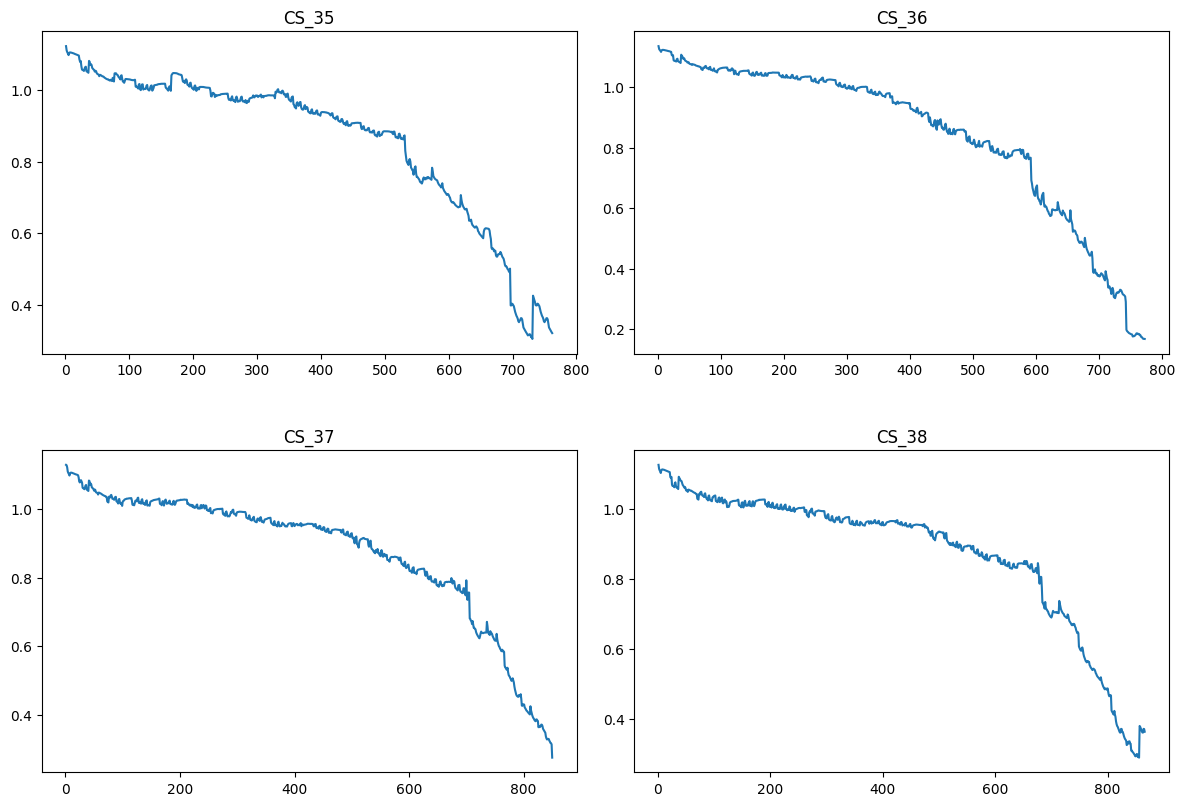

In [7]:
fig, ax = plt.subplots(nrows=int(len(dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(dfs.items()):
    ax[int(i/2), i%2].plot(df['Cycle_Index'], df['Discharge_Capacity(Ah)'])
    ax[int(i/2), i%2].set_title(f'CS_{battery_number}')

plt.show()

### 0% of test curve in training

In [8]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=10, hidden_size=int(round(5.08388659e+01)), dropout=5.00000000e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(
/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model: ABC-BiGRU
RMSE: 0.015964753234303797
MAE: 0.010670397525074026
------------------------------
Model: Attn-BiLSTM
RMSE: 0.013413348906141626
MAE: 0.007906781495242932
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.014648992121070303
MAE: 0.00861797785327973
------------------------------
Model: CNN-DBLSTM
RMSE: 0.014144374845164854
MAE: 0.010896228573101184
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.0171403657697095
MAE: 0.010425052856277194
------------------------------
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
Model: Proposed Model
RMSE: 0.010489202801861889
MAE: 0.00705153952493905
------------------------------


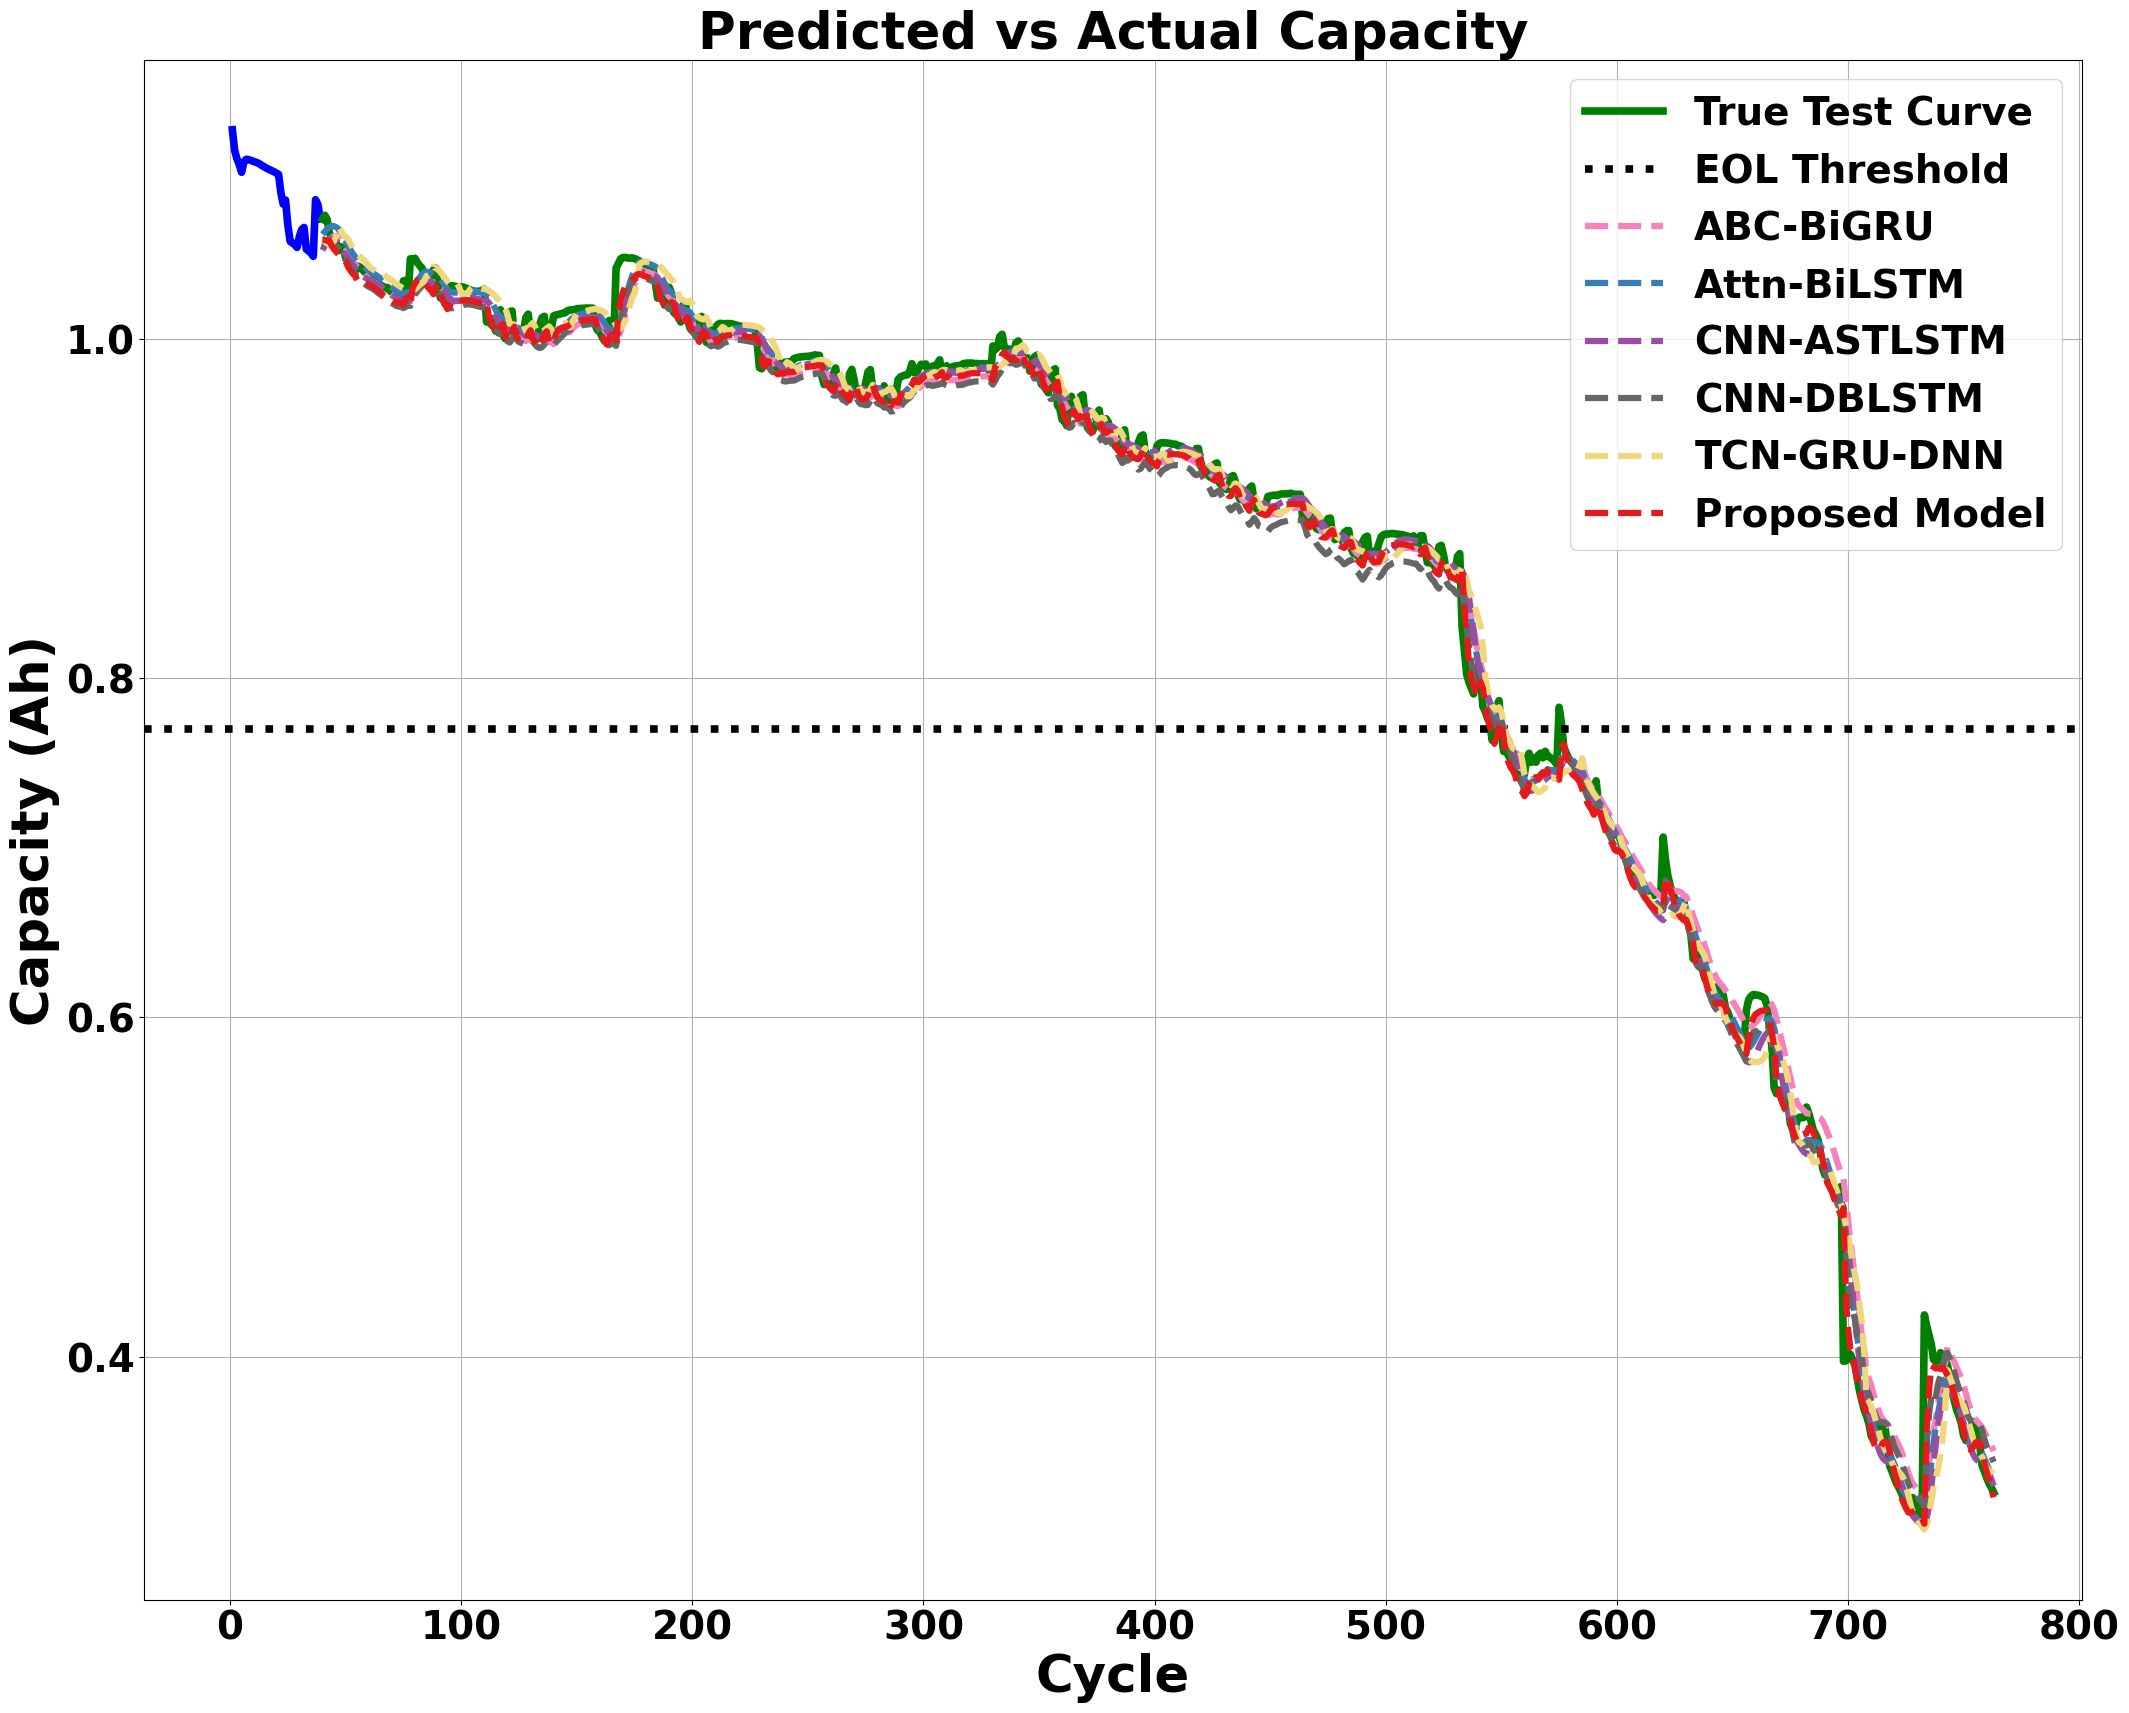

In [19]:
MIN = 0.0
MAX = 1.1
DIFF = MAX - MIN

plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[0],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[0]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.02638769966471886
MAE: 0.012885840591877067
------------------------------
Model: Attn-BiLSTM
RMSE: 0.013595259843733233
MAE: 0.008567330429652442
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.027909667886717466
MAE: 0.012808560545582109
------------------------------
Model: CNN-DBLSTM
RMSE: 0.023905605339780027
MAE: 0.011548371859952614
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.019937282179459358
MAE: 0.012199552580328881
------------------------------
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Model: Proposed Model
RMSE: 0.011481629997585138
MAE: 0.006941441138154144
------------------------------


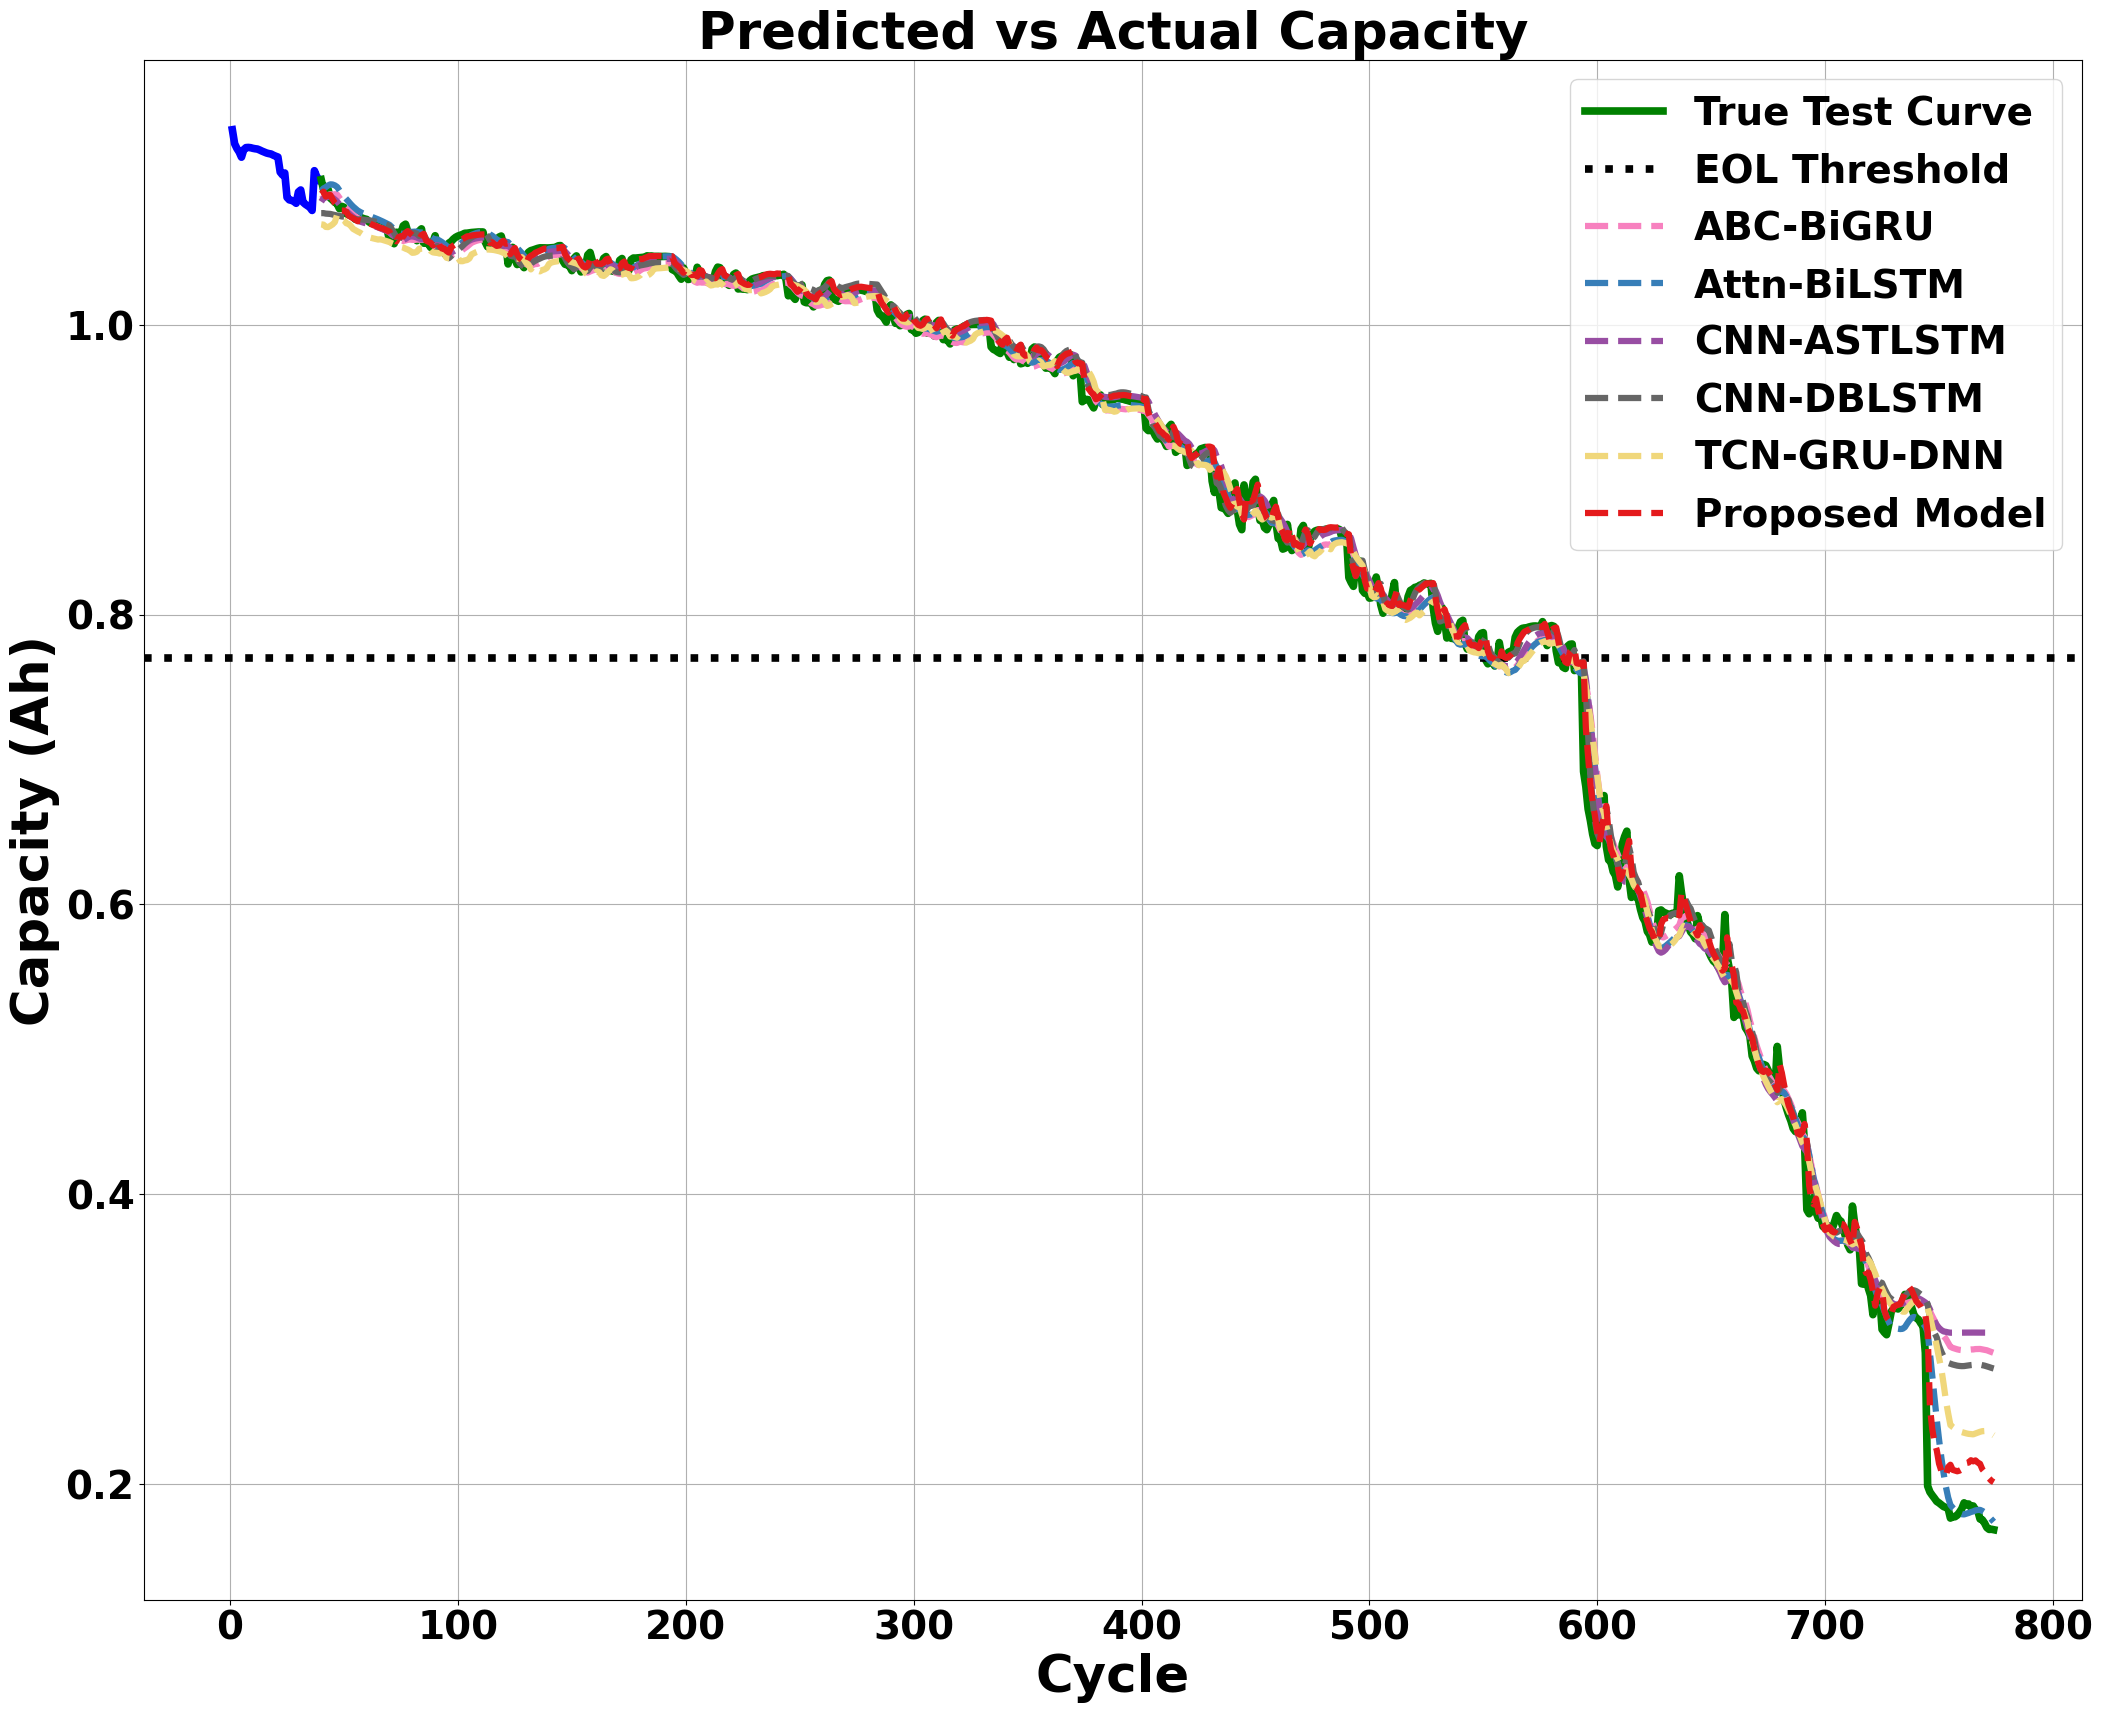

In [20]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[1],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[1]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.013153242845200062
MAE: 0.009121471331269485
------------------------------
Model: Attn-BiLSTM
RMSE: 0.009218608387979313
MAE: 0.006567994772878351
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.009278216697374156
MAE: 0.00666697771499192
------------------------------
Model: CNN-DBLSTM
RMSE: 0.011153541868001004
MAE: 0.00808426490797933
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.009020321939590896
MAE: 0.006762977009725157
------------------------------
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Model: Proposed Model
RMSE: 0.006691257855605066
MAE: 0.004435828391482814
------------------------------


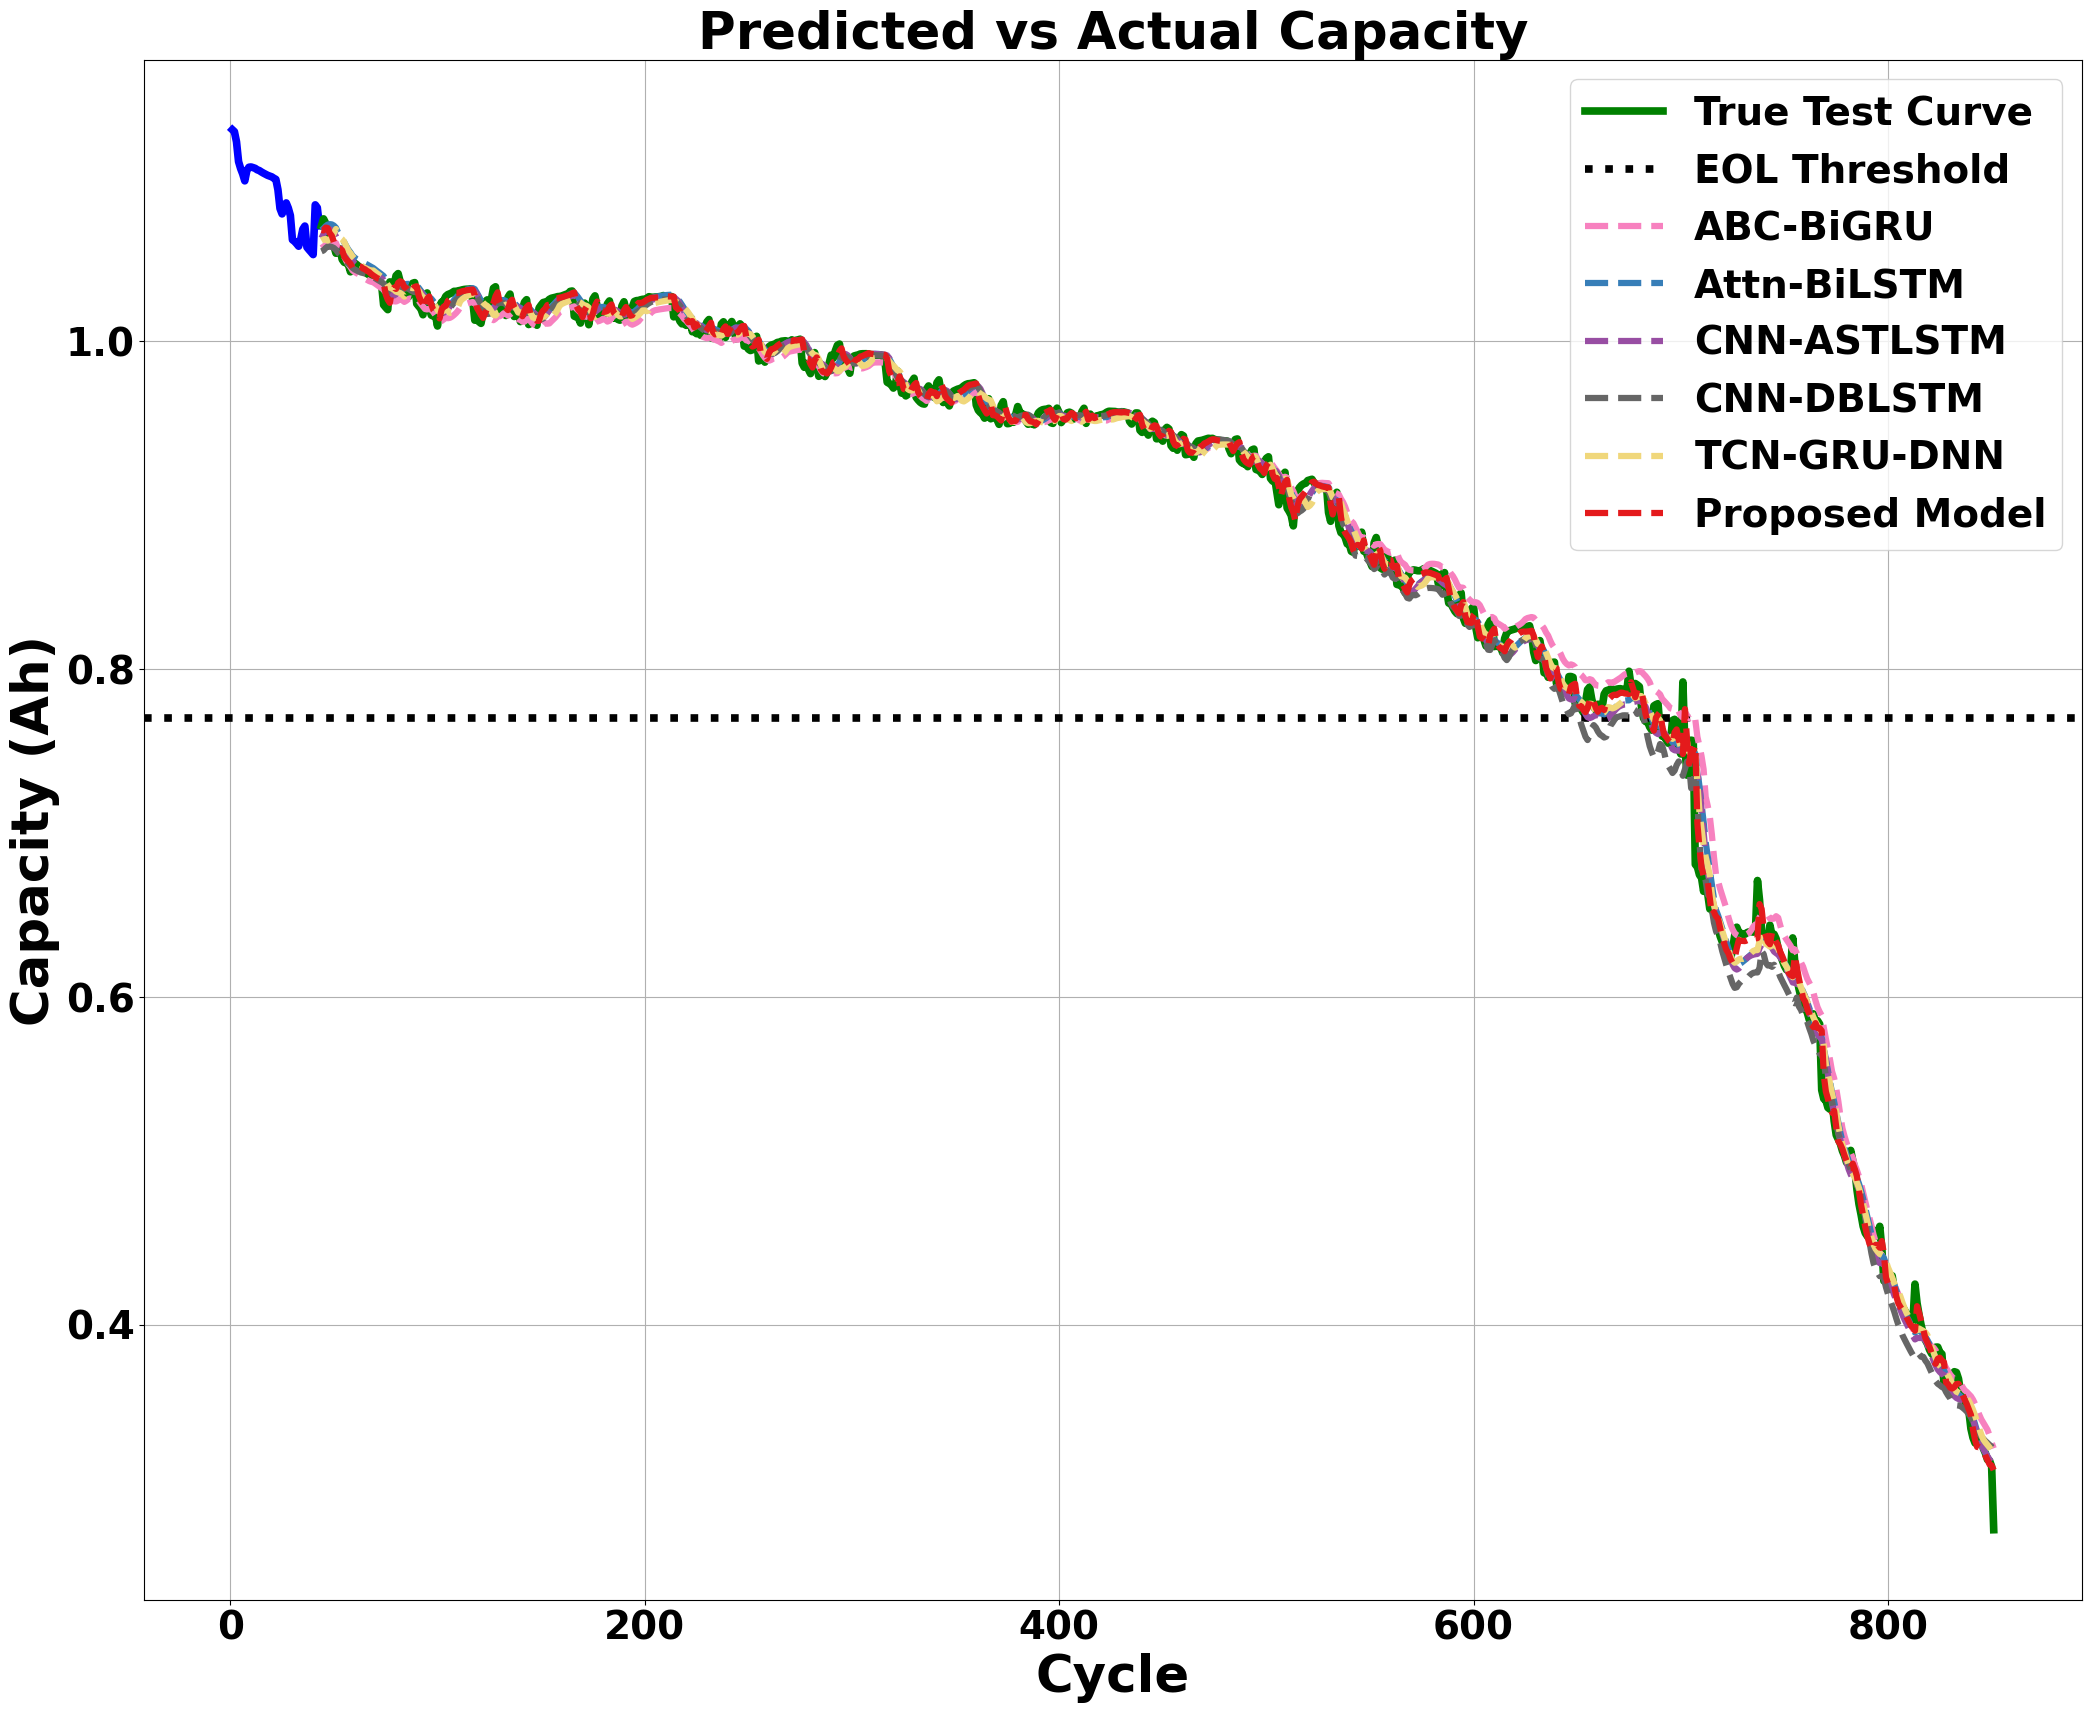

In [21]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[2],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[2]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.014289191338608098
MAE: 0.010848090541477652
------------------------------
Model: Attn-BiLSTM
RMSE: 0.010738798958224263
MAE: 0.007093260815754427
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.010736225551866792
MAE: 0.0069137055812262494
------------------------------
Model: CNN-DBLSTM
RMSE: 0.010433837843637475
MAE: 0.007345972586435711
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.01373661377003952
MAE: 0.00900142237437776
------------------------------
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Model: Proposed Model
RMSE: 0.007026483650660081
MAE: 0.004425763286494943
------------------------------


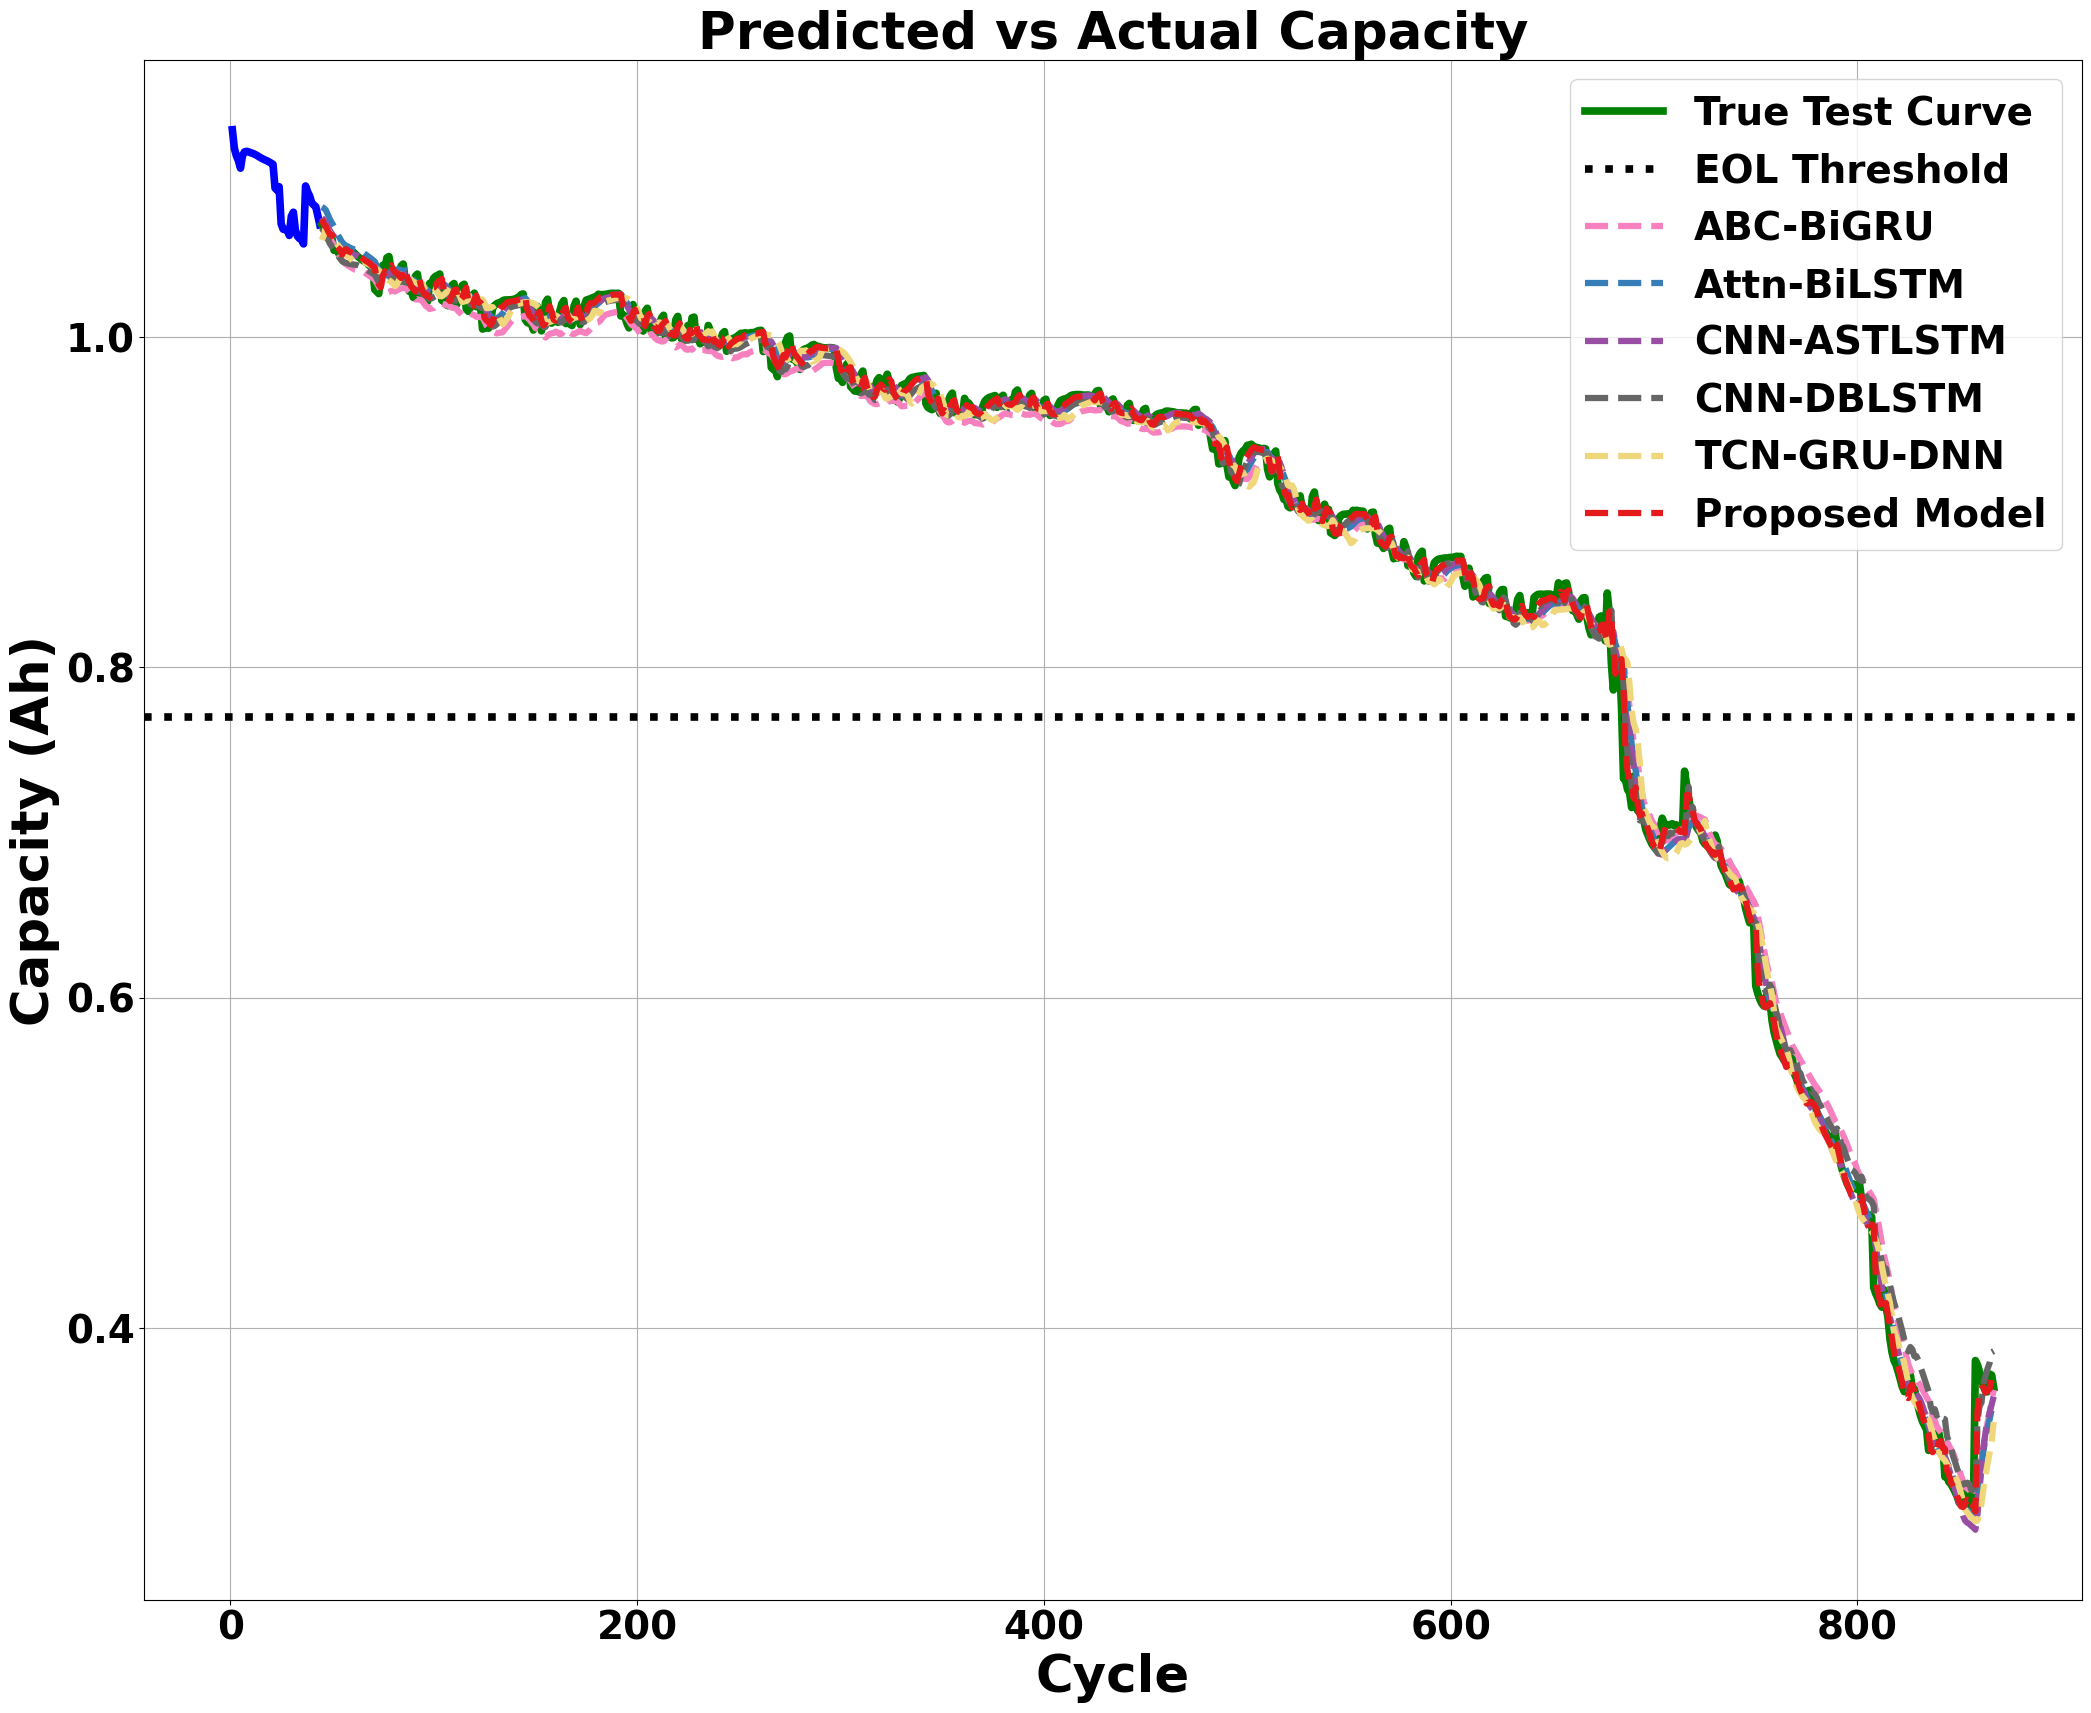

In [22]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[3],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[3]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

### 30% of test curve in training

In [23]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=10, hidden_size=int(round(7.30596193e+01)), dropout=1.00000000e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}_30.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(
/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model: ABC-BiGRU
RMSE: 0.01702601366191124
MAE: 0.009906445392562217
------------------------------
Model: Attn-BiLSTM
RMSE: 0.01428862712279889
MAE: 0.008159707656660744
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.018708345407974128
MAE: 0.01211092587347874
------------------------------
Model: CNN-DBLSTM
RMSE: 0.01401443626196136
MAE: 0.009561047229871823
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.013219430986601848
MAE: 0.008206639327002711
------------------------------
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
Model: Proposed Model
RMSE: 0.009947235986884696
MAE: 0.005439522186086893
------------------------------


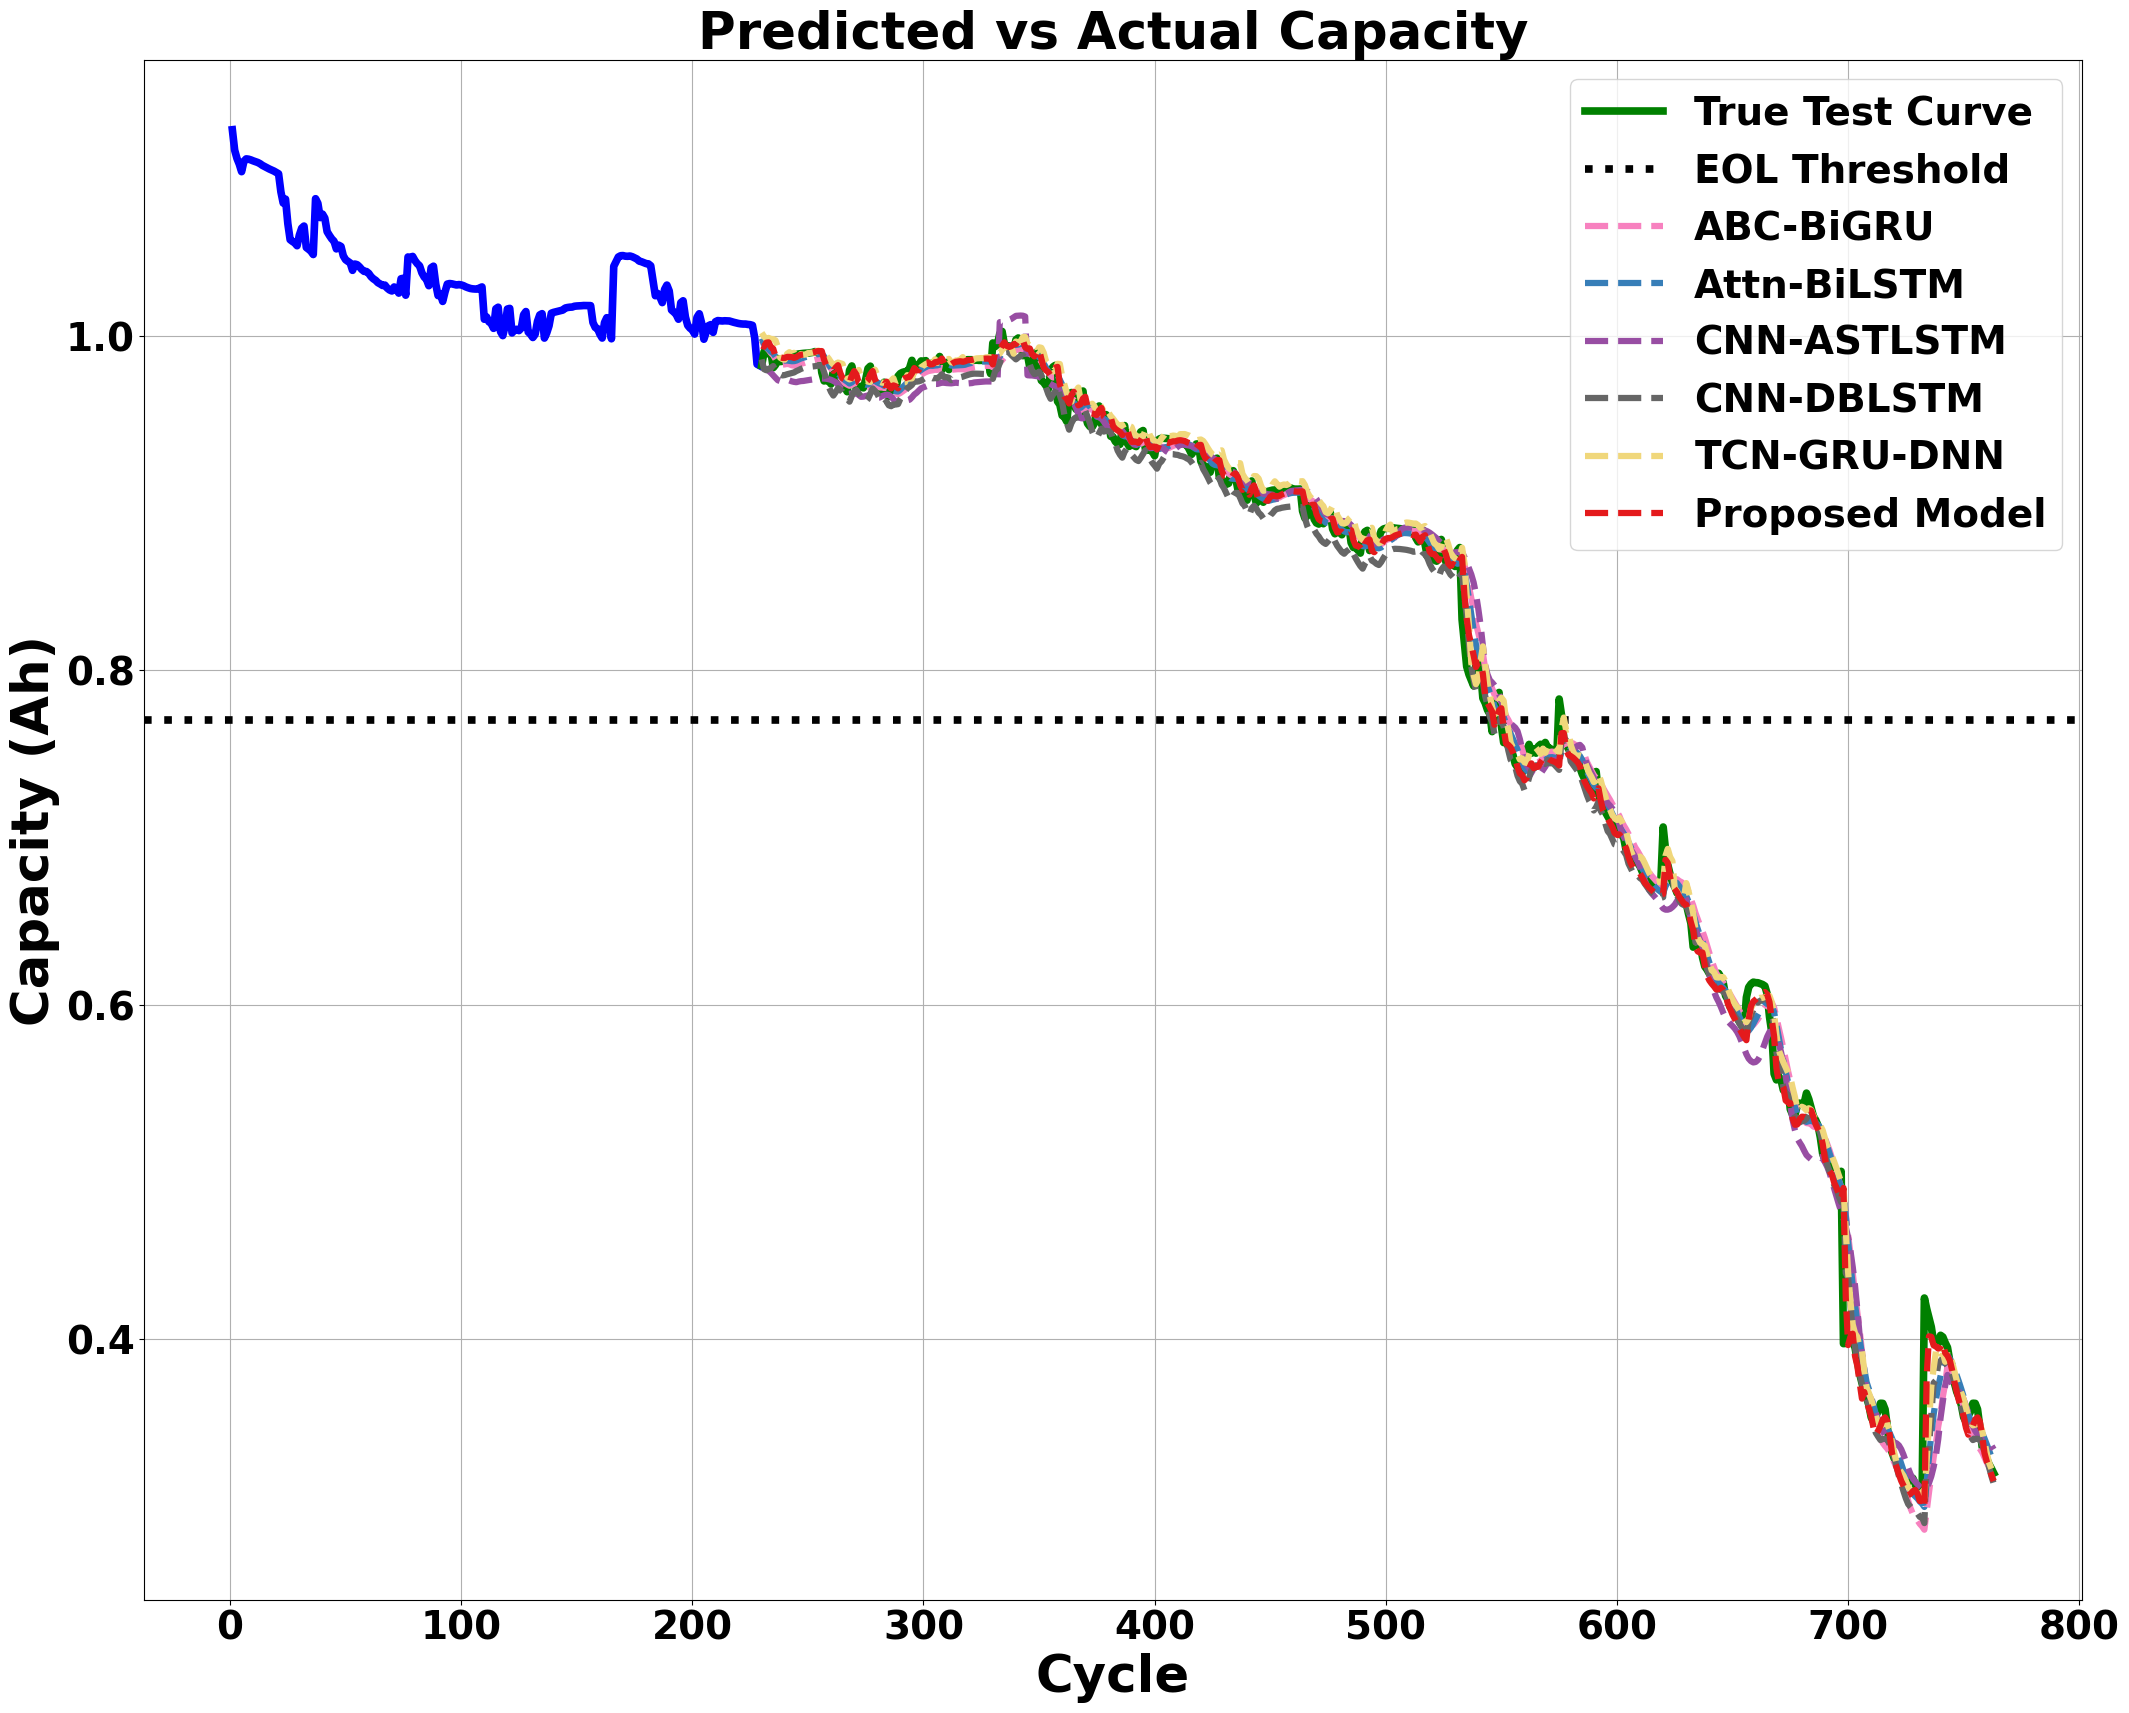

In [24]:
MIN = 0.0
MAX = 1.1
DIFF = MAX - MIN

plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[0],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[0]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.01854093064279039
MAE: 0.012177481794122131
------------------------------
Model: Attn-BiLSTM
RMSE: 0.017219697240072655
MAE: 0.011150023009146647
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.03272922836176573
MAE: 0.017372312900537576
------------------------------
Model: CNN-DBLSTM
RMSE: 0.02724185605917746
MAE: 0.012894525215444022
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.02438610541294641
MAE: 0.013563407287858134
------------------------------
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Model: Proposed Model
RMSE: 0.01229227425150732
MAE: 0.007973495773863654
------------------------------


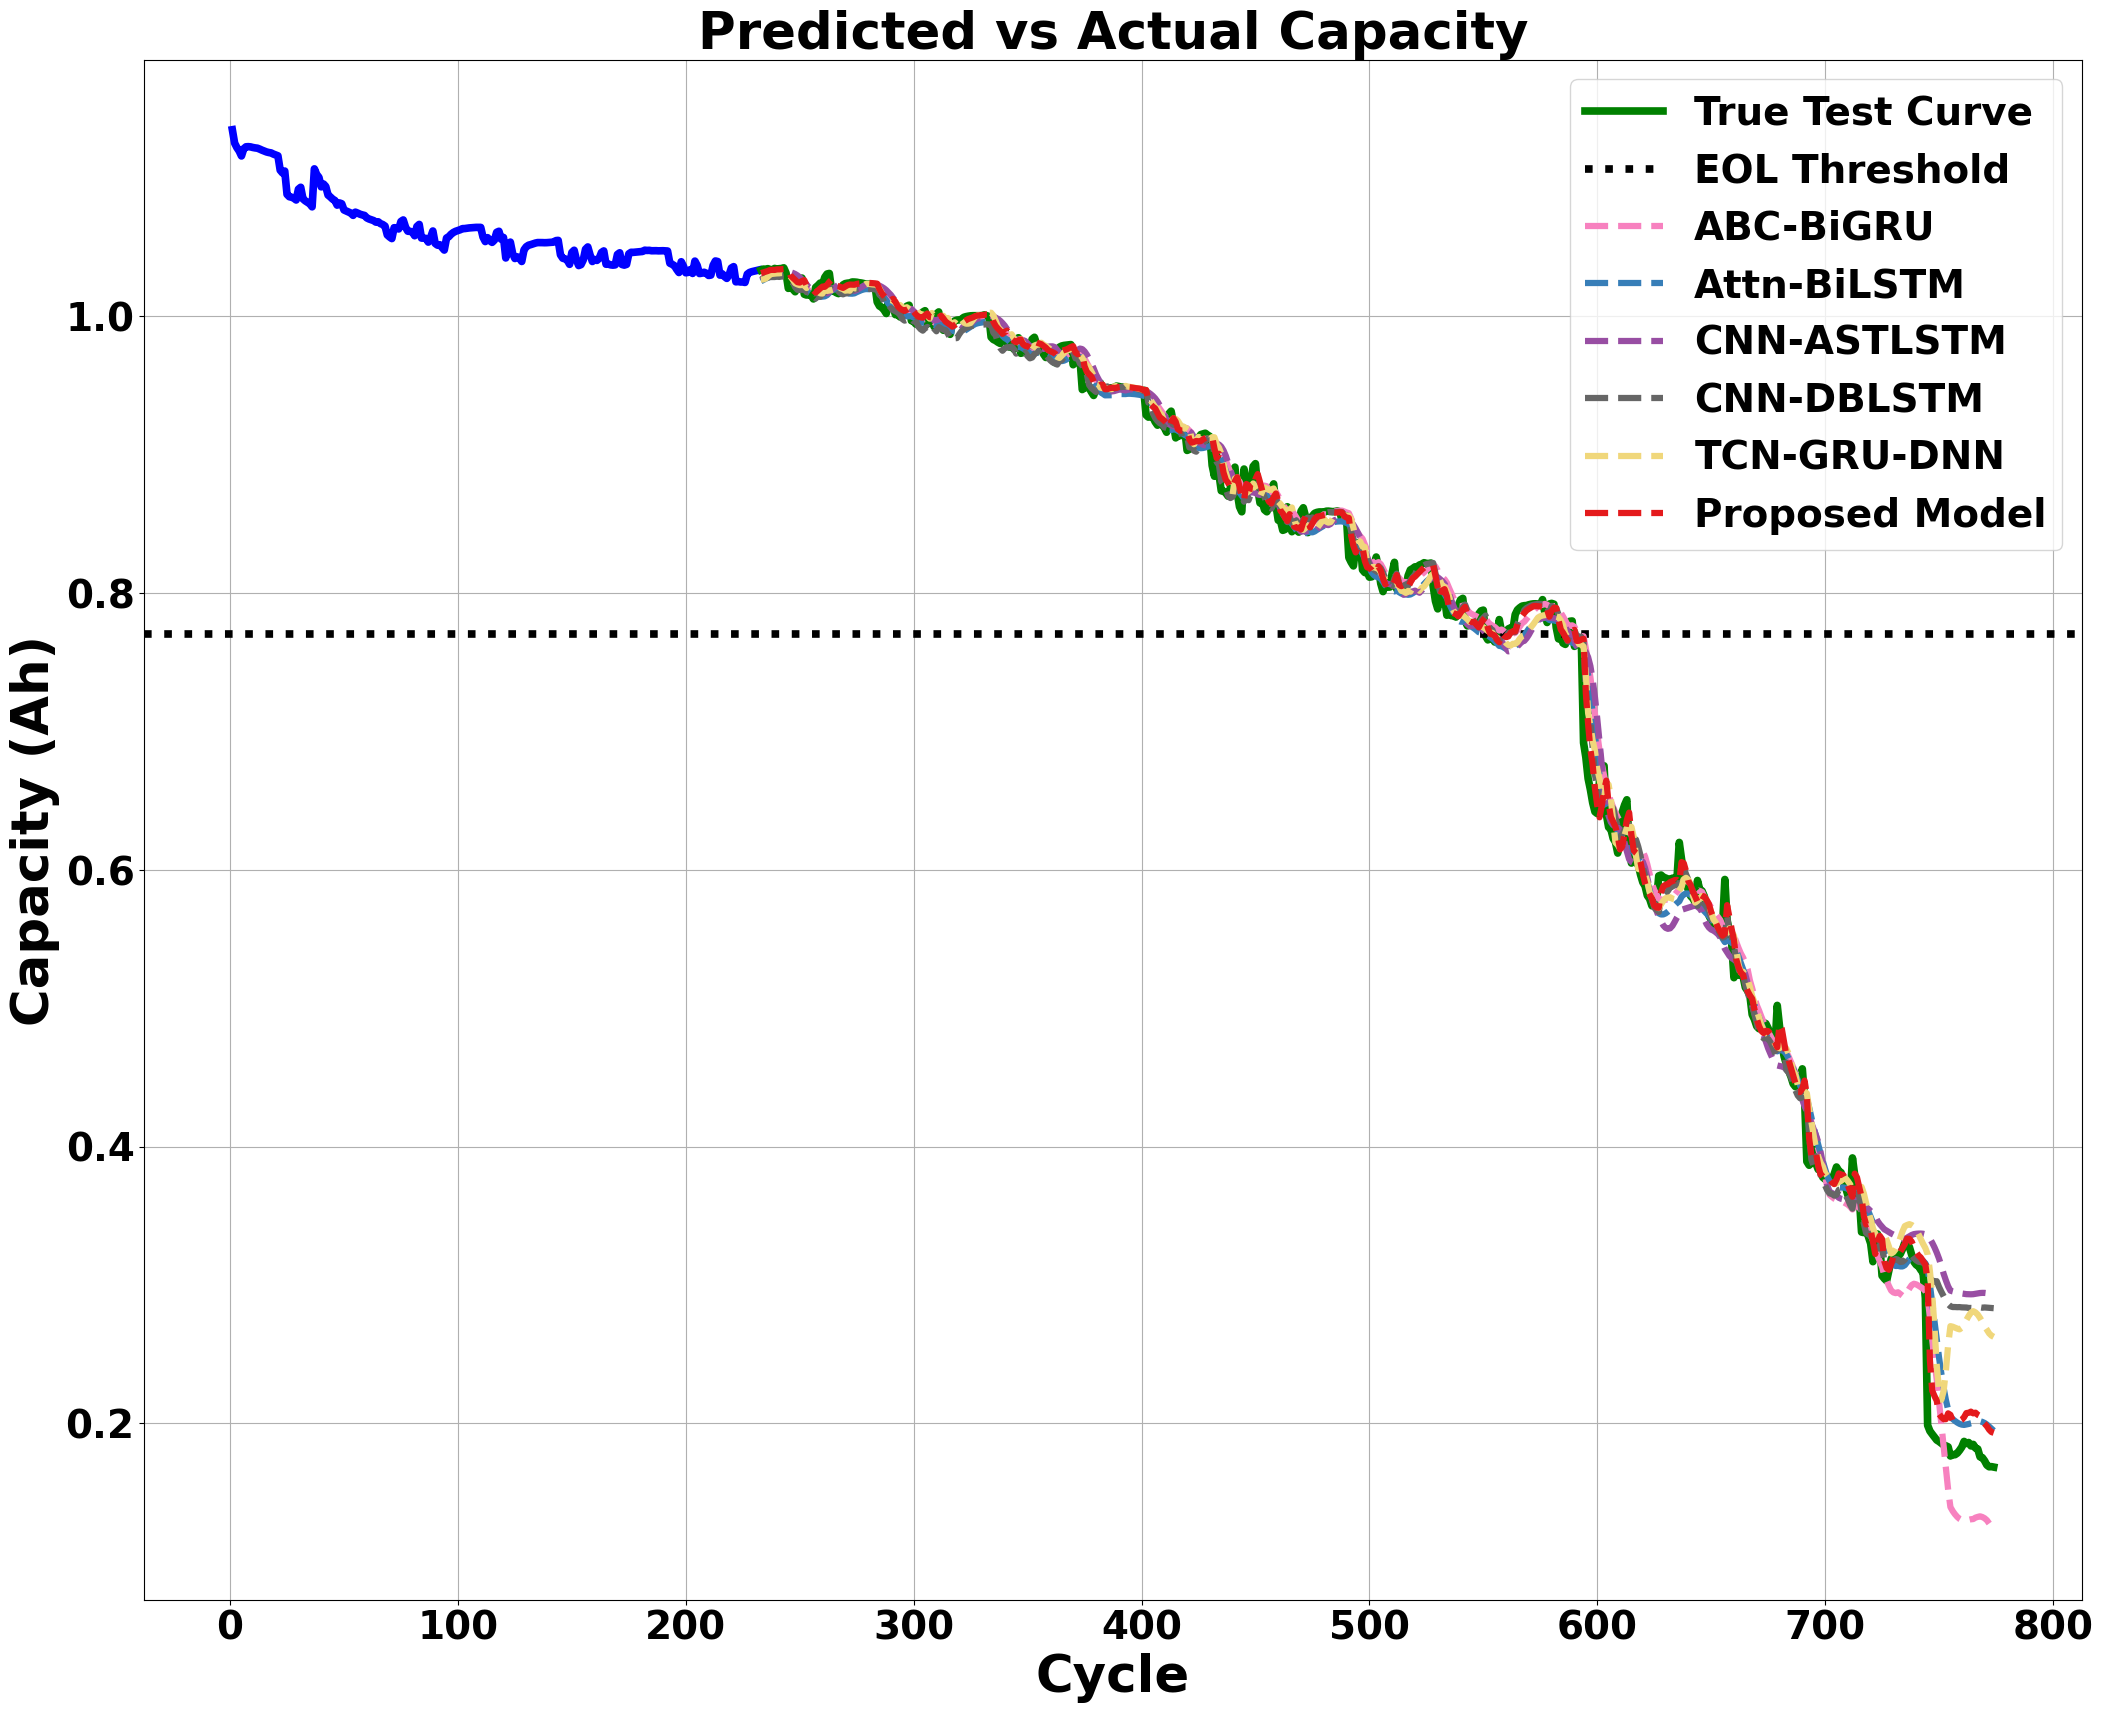

In [25]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[1],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[1]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.010656006631183799
MAE: 0.00766593153347842
------------------------------
Model: Attn-BiLSTM
RMSE: 0.01003393311012789
MAE: 0.007156043038207755
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.01312896260939831
MAE: 0.008972431457984103
------------------------------
Model: CNN-DBLSTM
RMSE: 0.00941943398330409
MAE: 0.007008758383488482
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.013051715230507459
MAE: 0.009838879725356665
------------------------------
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Model: Proposed Model
RMSE: 0.007520322837473592
MAE: 0.00515289535367194
------------------------------


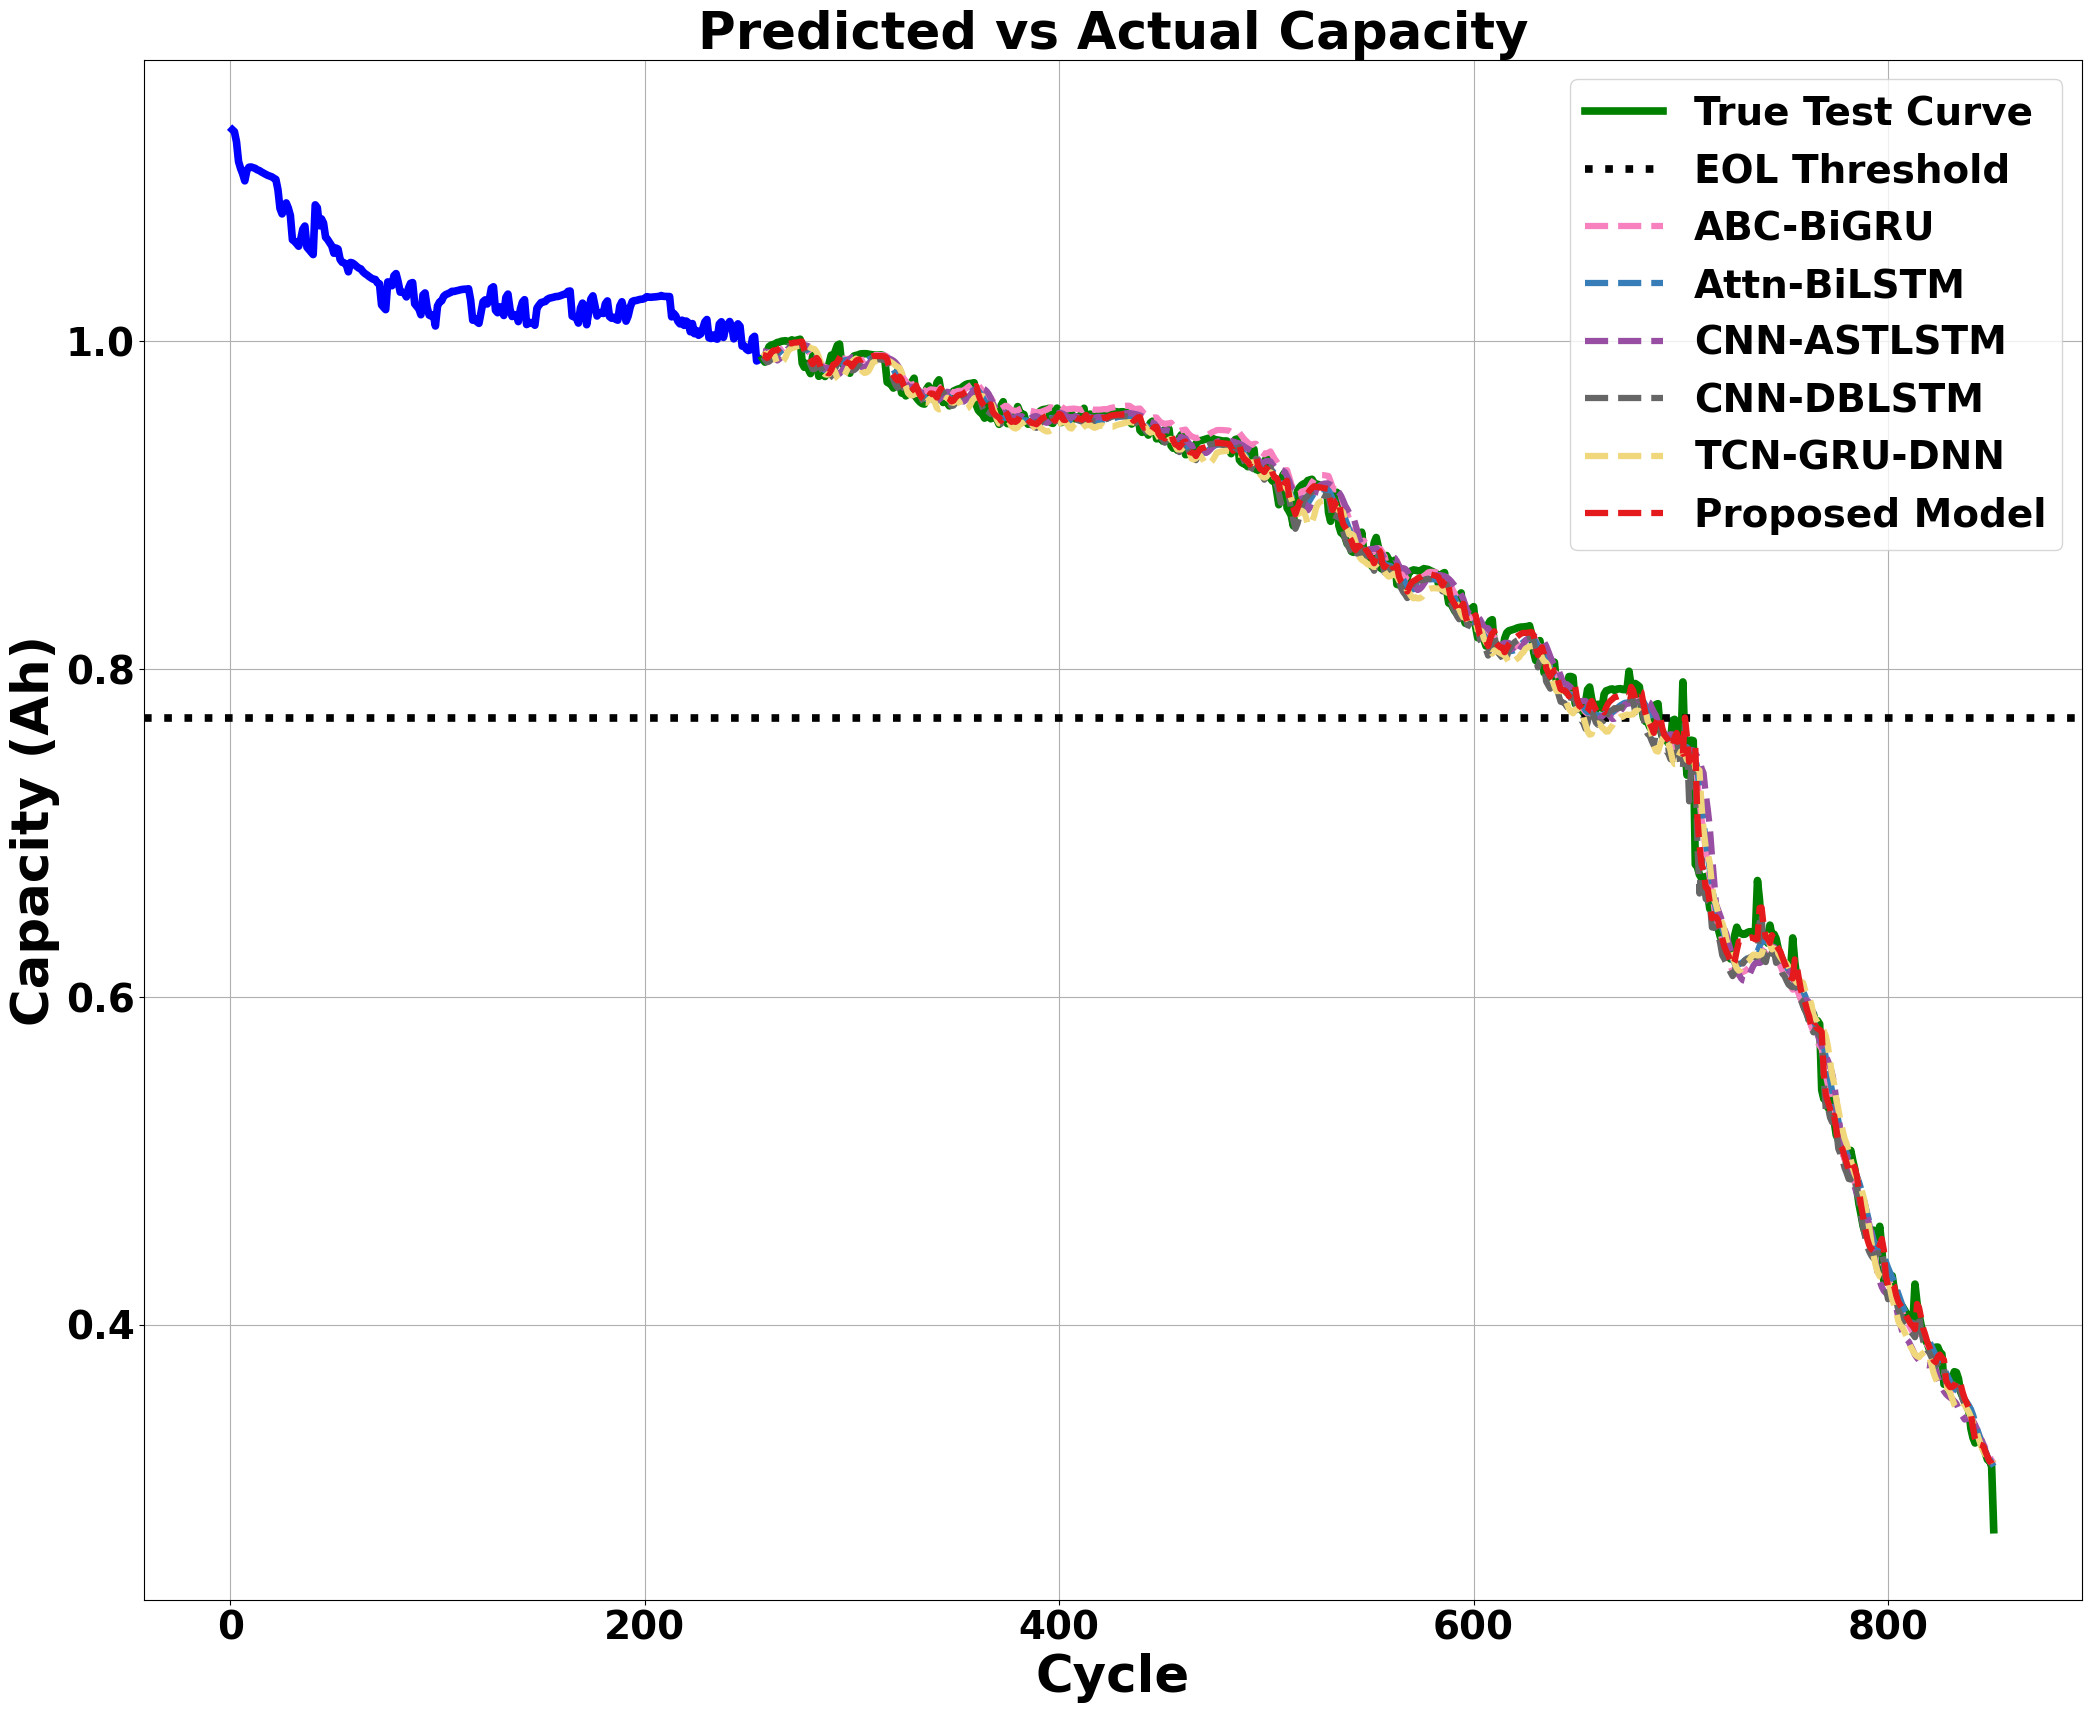

In [26]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[2],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[2]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.011915290516558872
MAE: 0.007550377924533117
------------------------------
Model: Attn-BiLSTM
RMSE: 0.011961272090280792
MAE: 0.007740451418710378
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.015212752613620768
MAE: 0.009588423389729258
------------------------------
Model: CNN-DBLSTM
RMSE: 0.009024639030057523
MAE: 0.00649917851683124
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.012395532390545442
MAE: 0.008270223697122697
------------------------------
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
Model: Proposed Model
RMSE: 0.007972259586963392
MAE: 0.00503874220185413
------------------------------


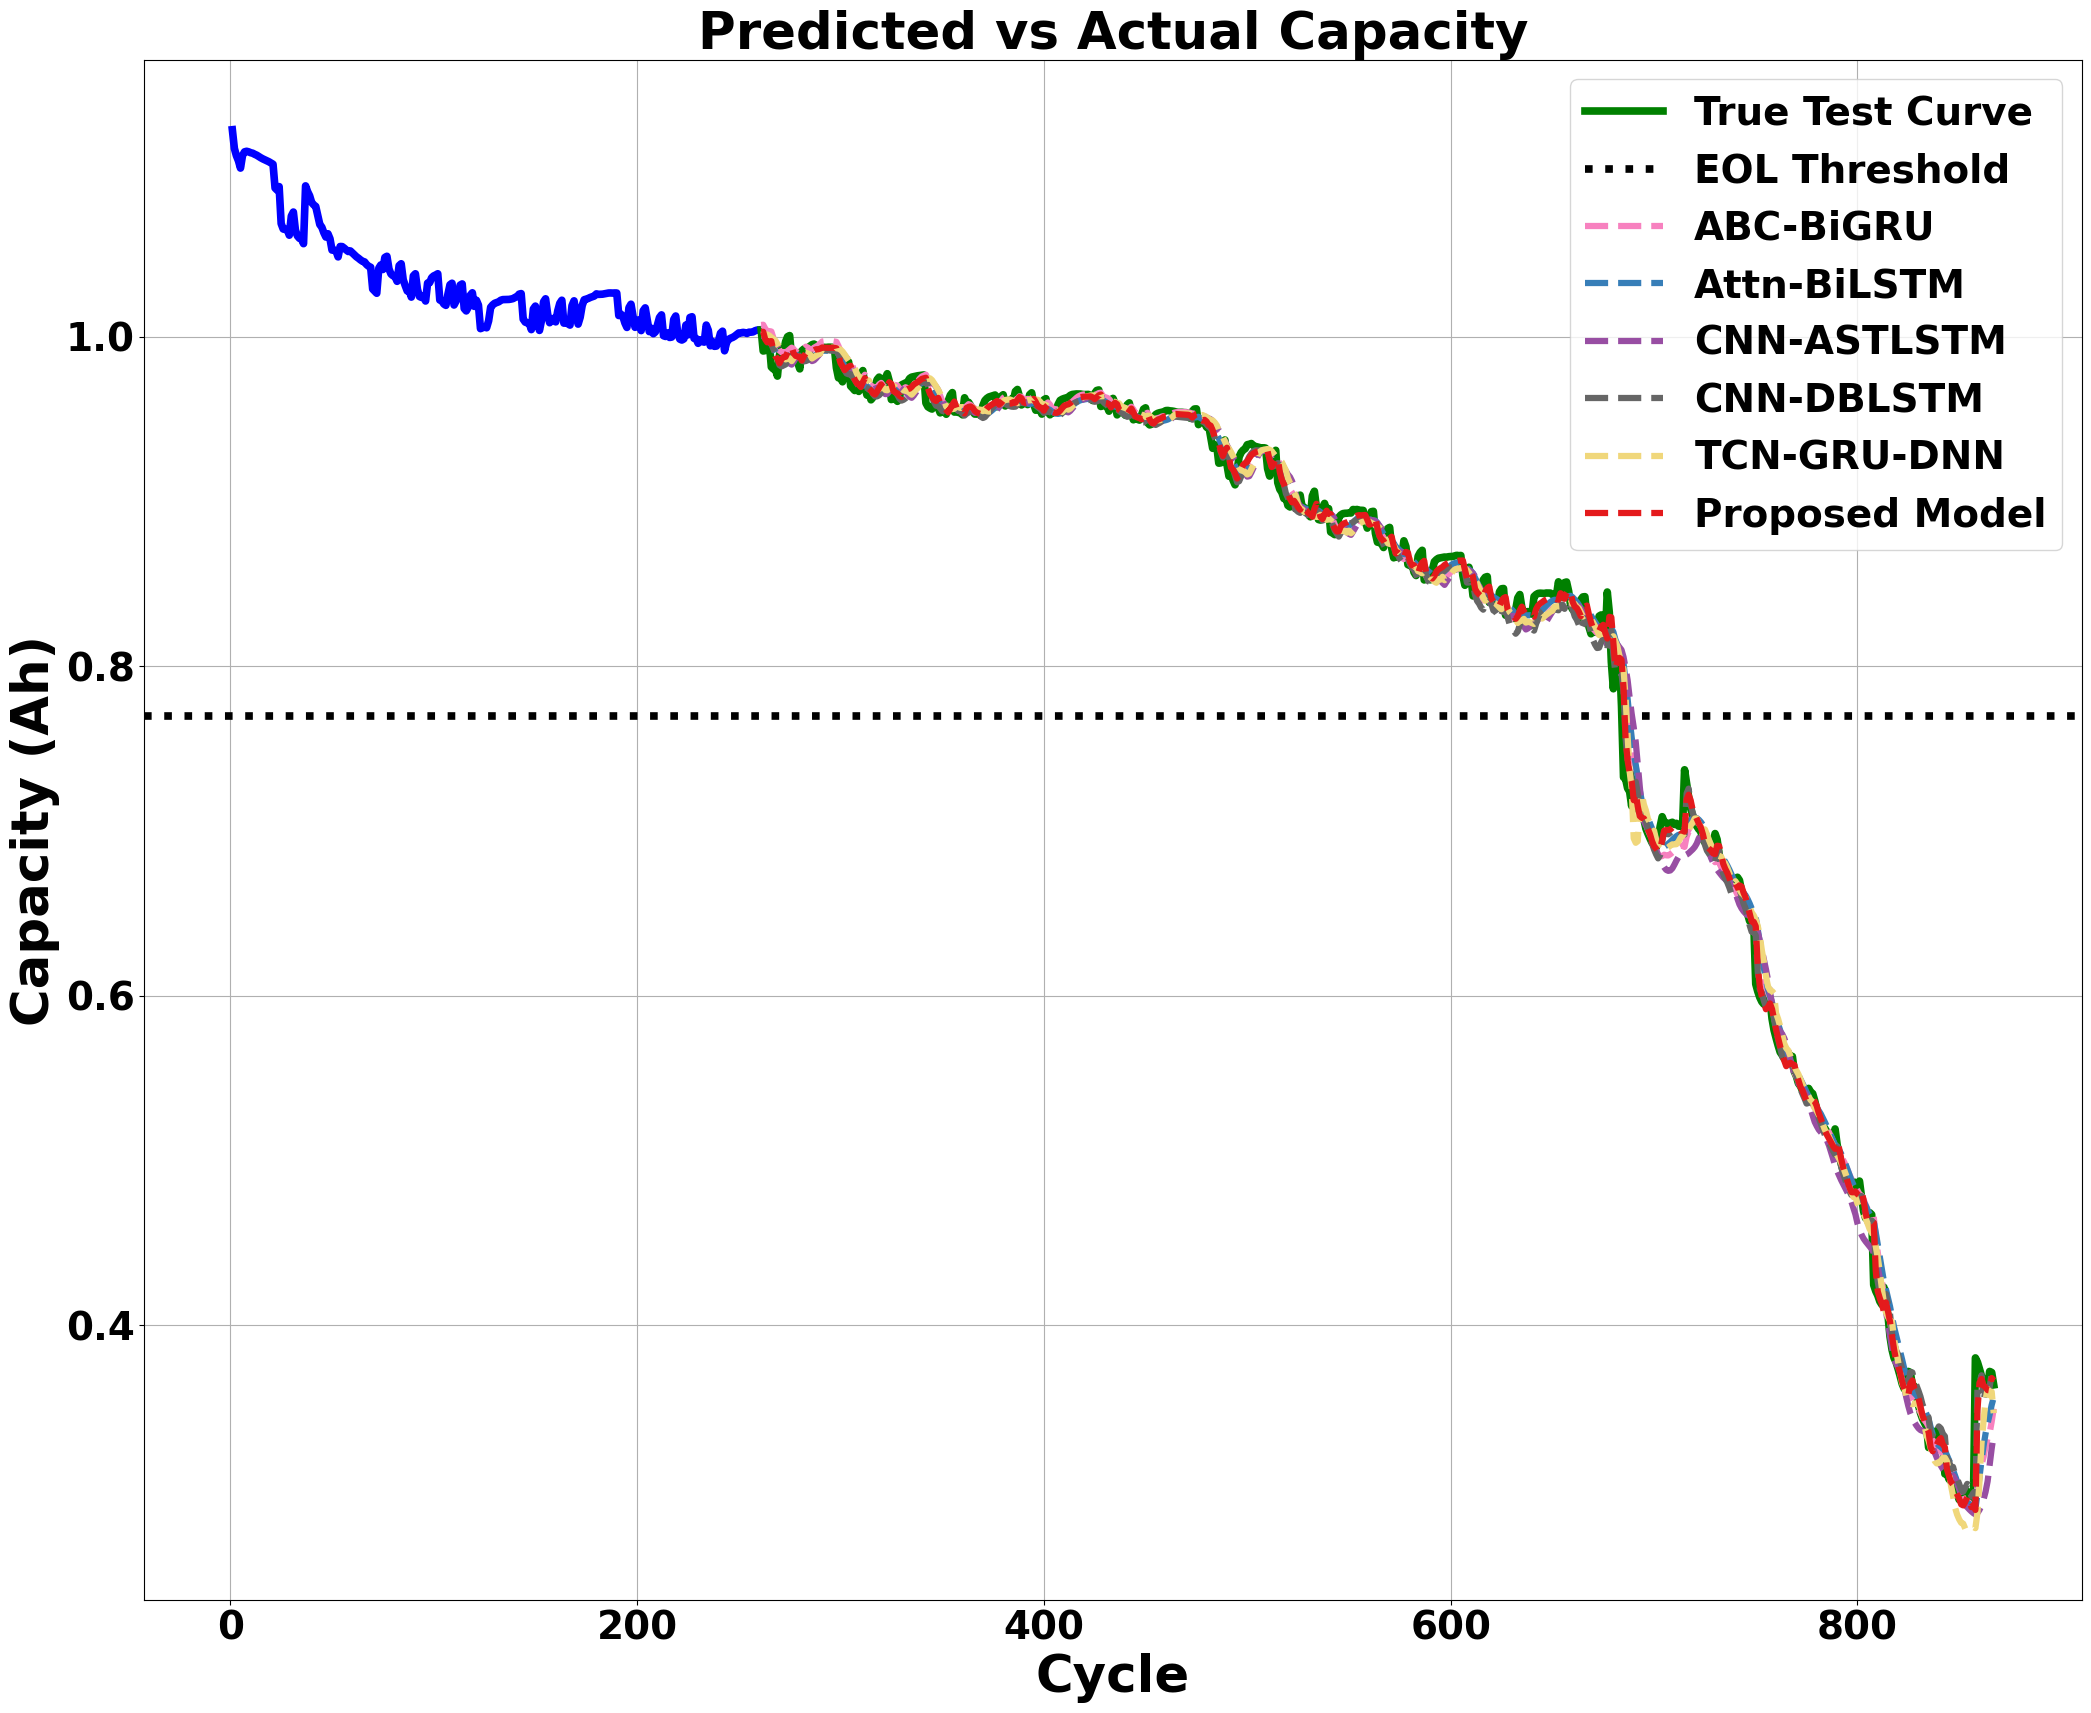

In [27]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[3],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[3]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
)

### 50% of test curve in training

In [49]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=10, hidden_size=int(round(1.17945268e+02)), dropout=1.16354266e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}_50.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(
/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model: ABC-BiGRU
RMSE: 0.019641124018358207
MAE: 0.011493354594557406
------------------------------
Model: Attn-BiLSTM
RMSE: 0.016393522951279722
MAE: 0.009408662716932147
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.02080494490038402
MAE: 0.012749042170837452
------------------------------
Model: CNN-DBLSTM
RMSE: 0.0154463492228536
MAE: 0.010081049687027027
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.014731866988583158
MAE: 0.009013558844423359
------------------------------
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
Model: Proposed Model
RMSE: 0.011151113771170274
MAE: 0.0058710923644632864
------------------------------


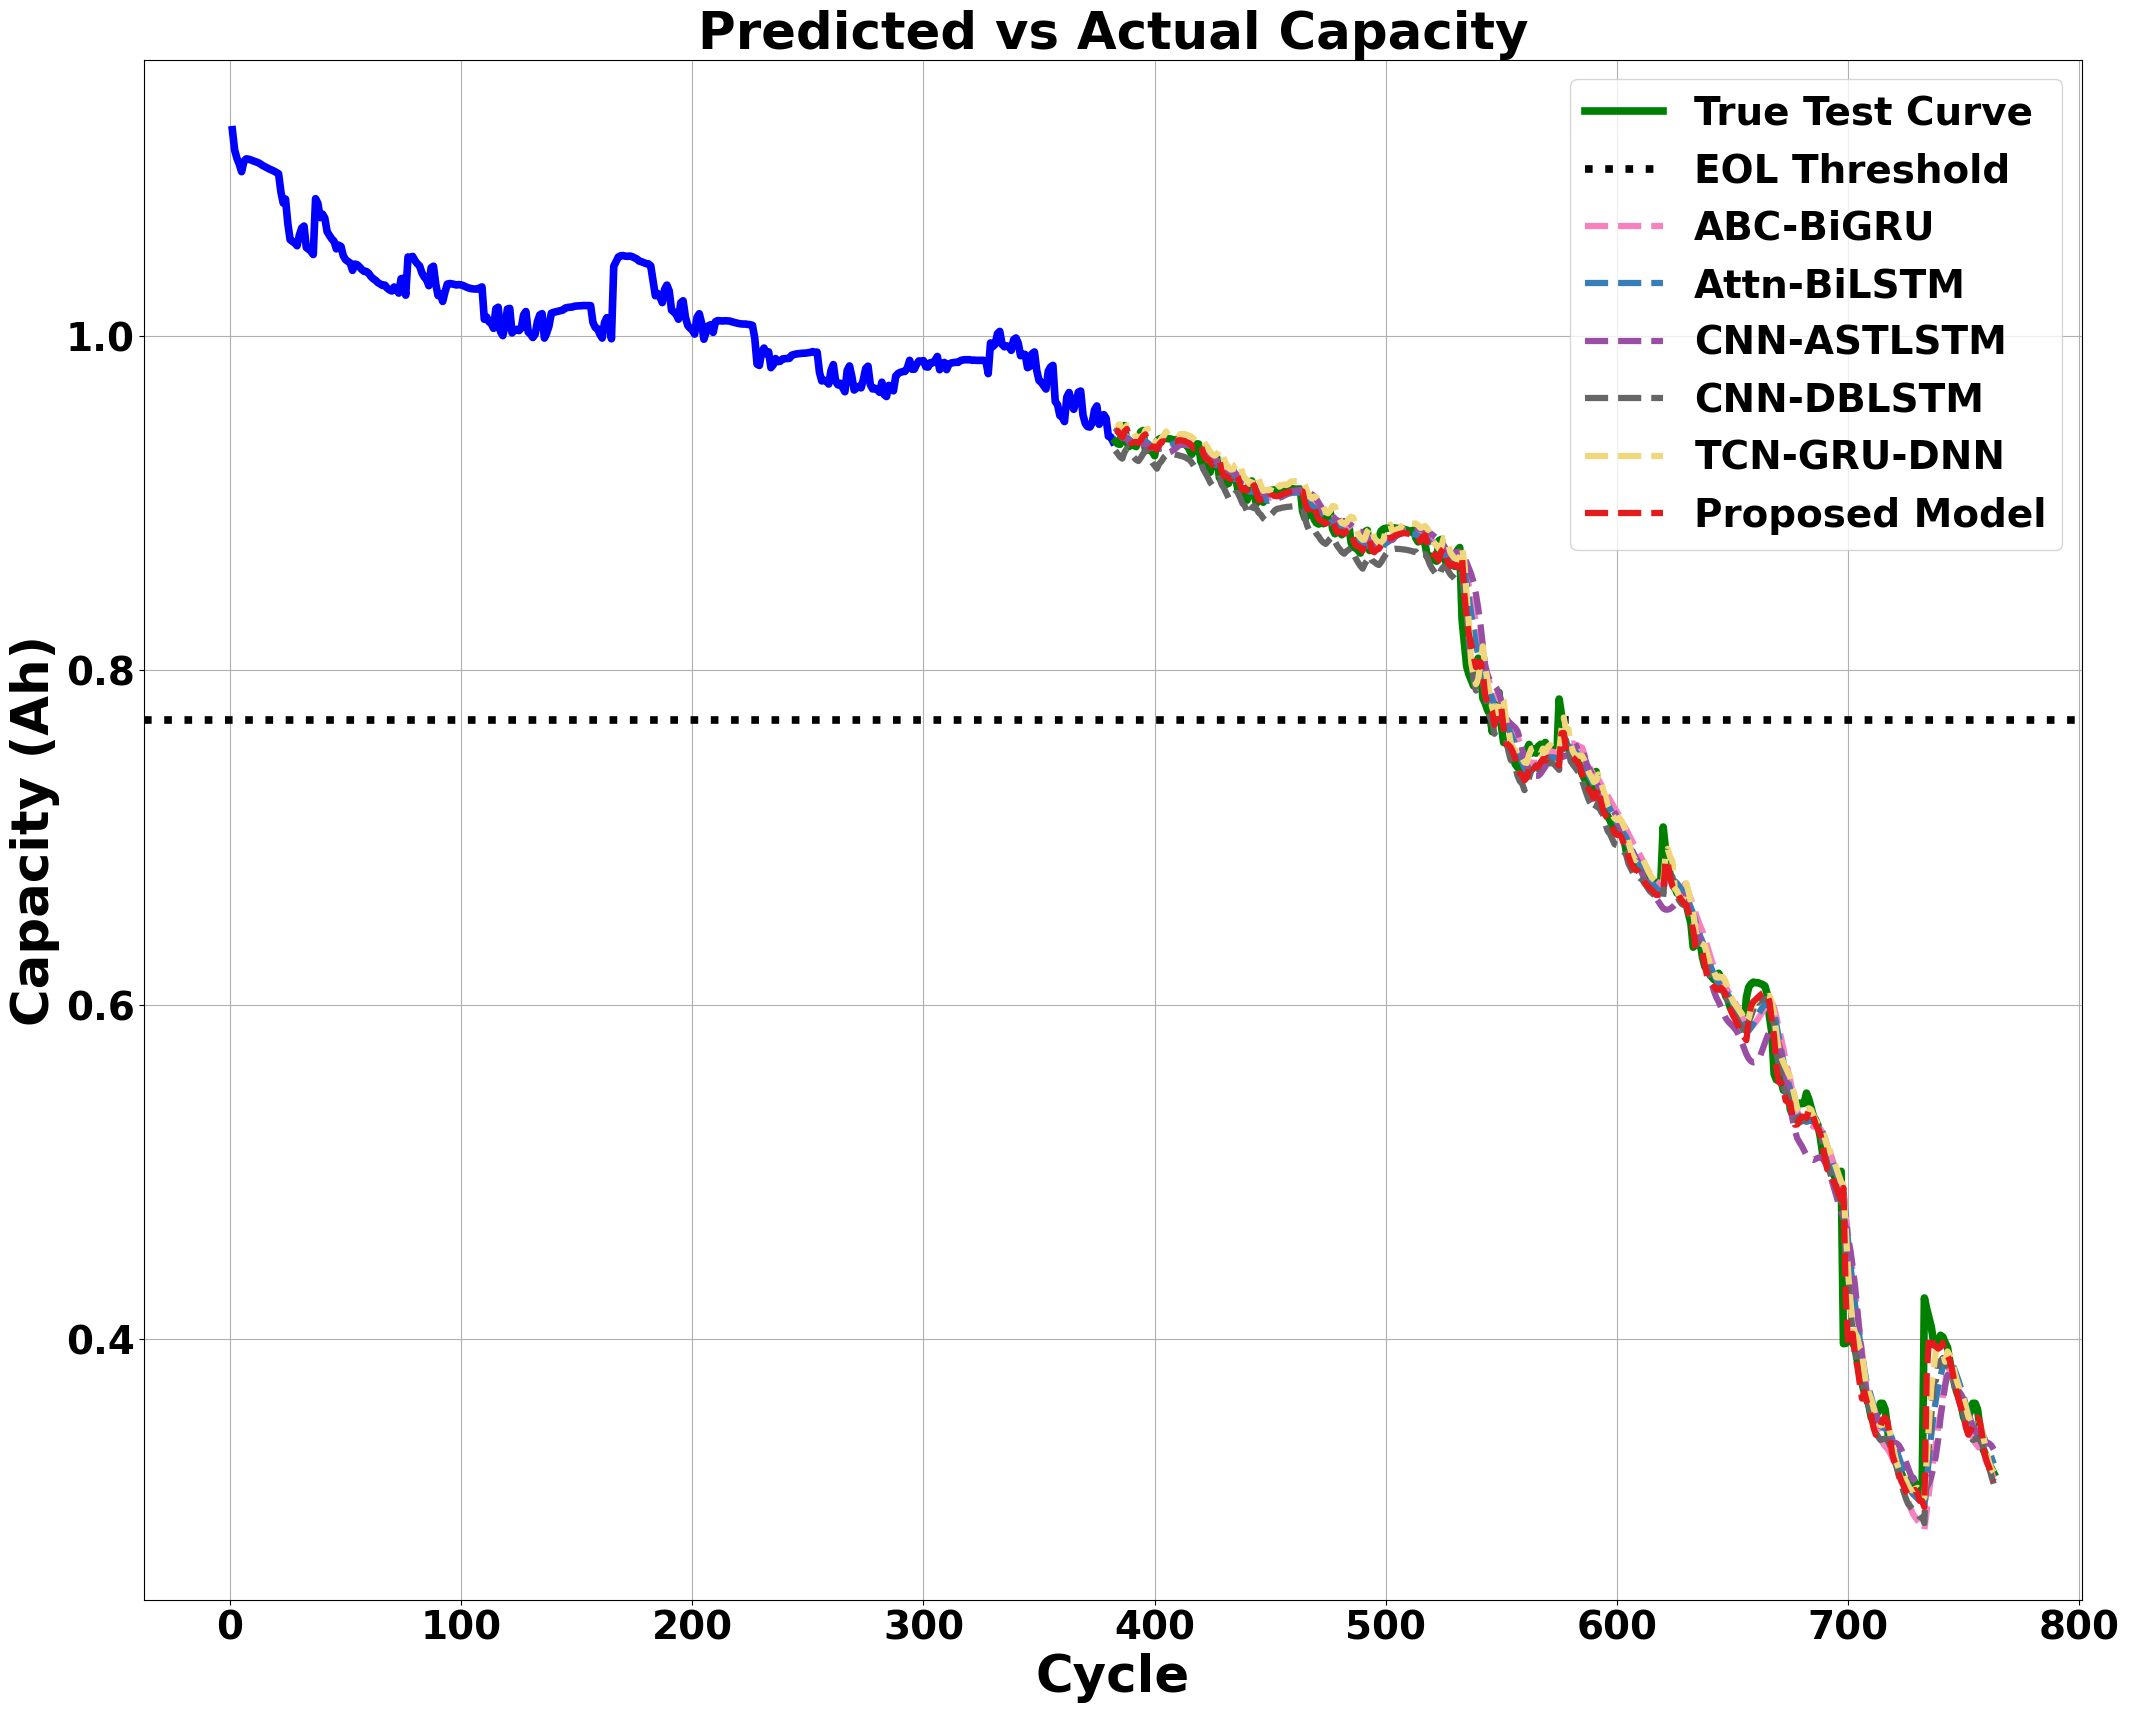

In [28]:
MIN = 0.0
MAX = 1.1
DIFF = MAX - MIN

plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[0],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[0]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.021507260711147436
MAE: 0.014790444194457266
------------------------------
Model: Attn-BiLSTM
RMSE: 0.019900630541504278
MAE: 0.013261168565474732
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.03837531919860536
MAE: 0.021800514978098463
------------------------------
Model: CNN-DBLSTM
RMSE: 0.03196754585027141
MAE: 0.01587111995011365
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.028525331085063242
MAE: 0.01681308140911667
------------------------------
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
Model: Proposed Model
RMSE: 0.01403057331555134
MAE: 0.009326423205999882
------------------------------


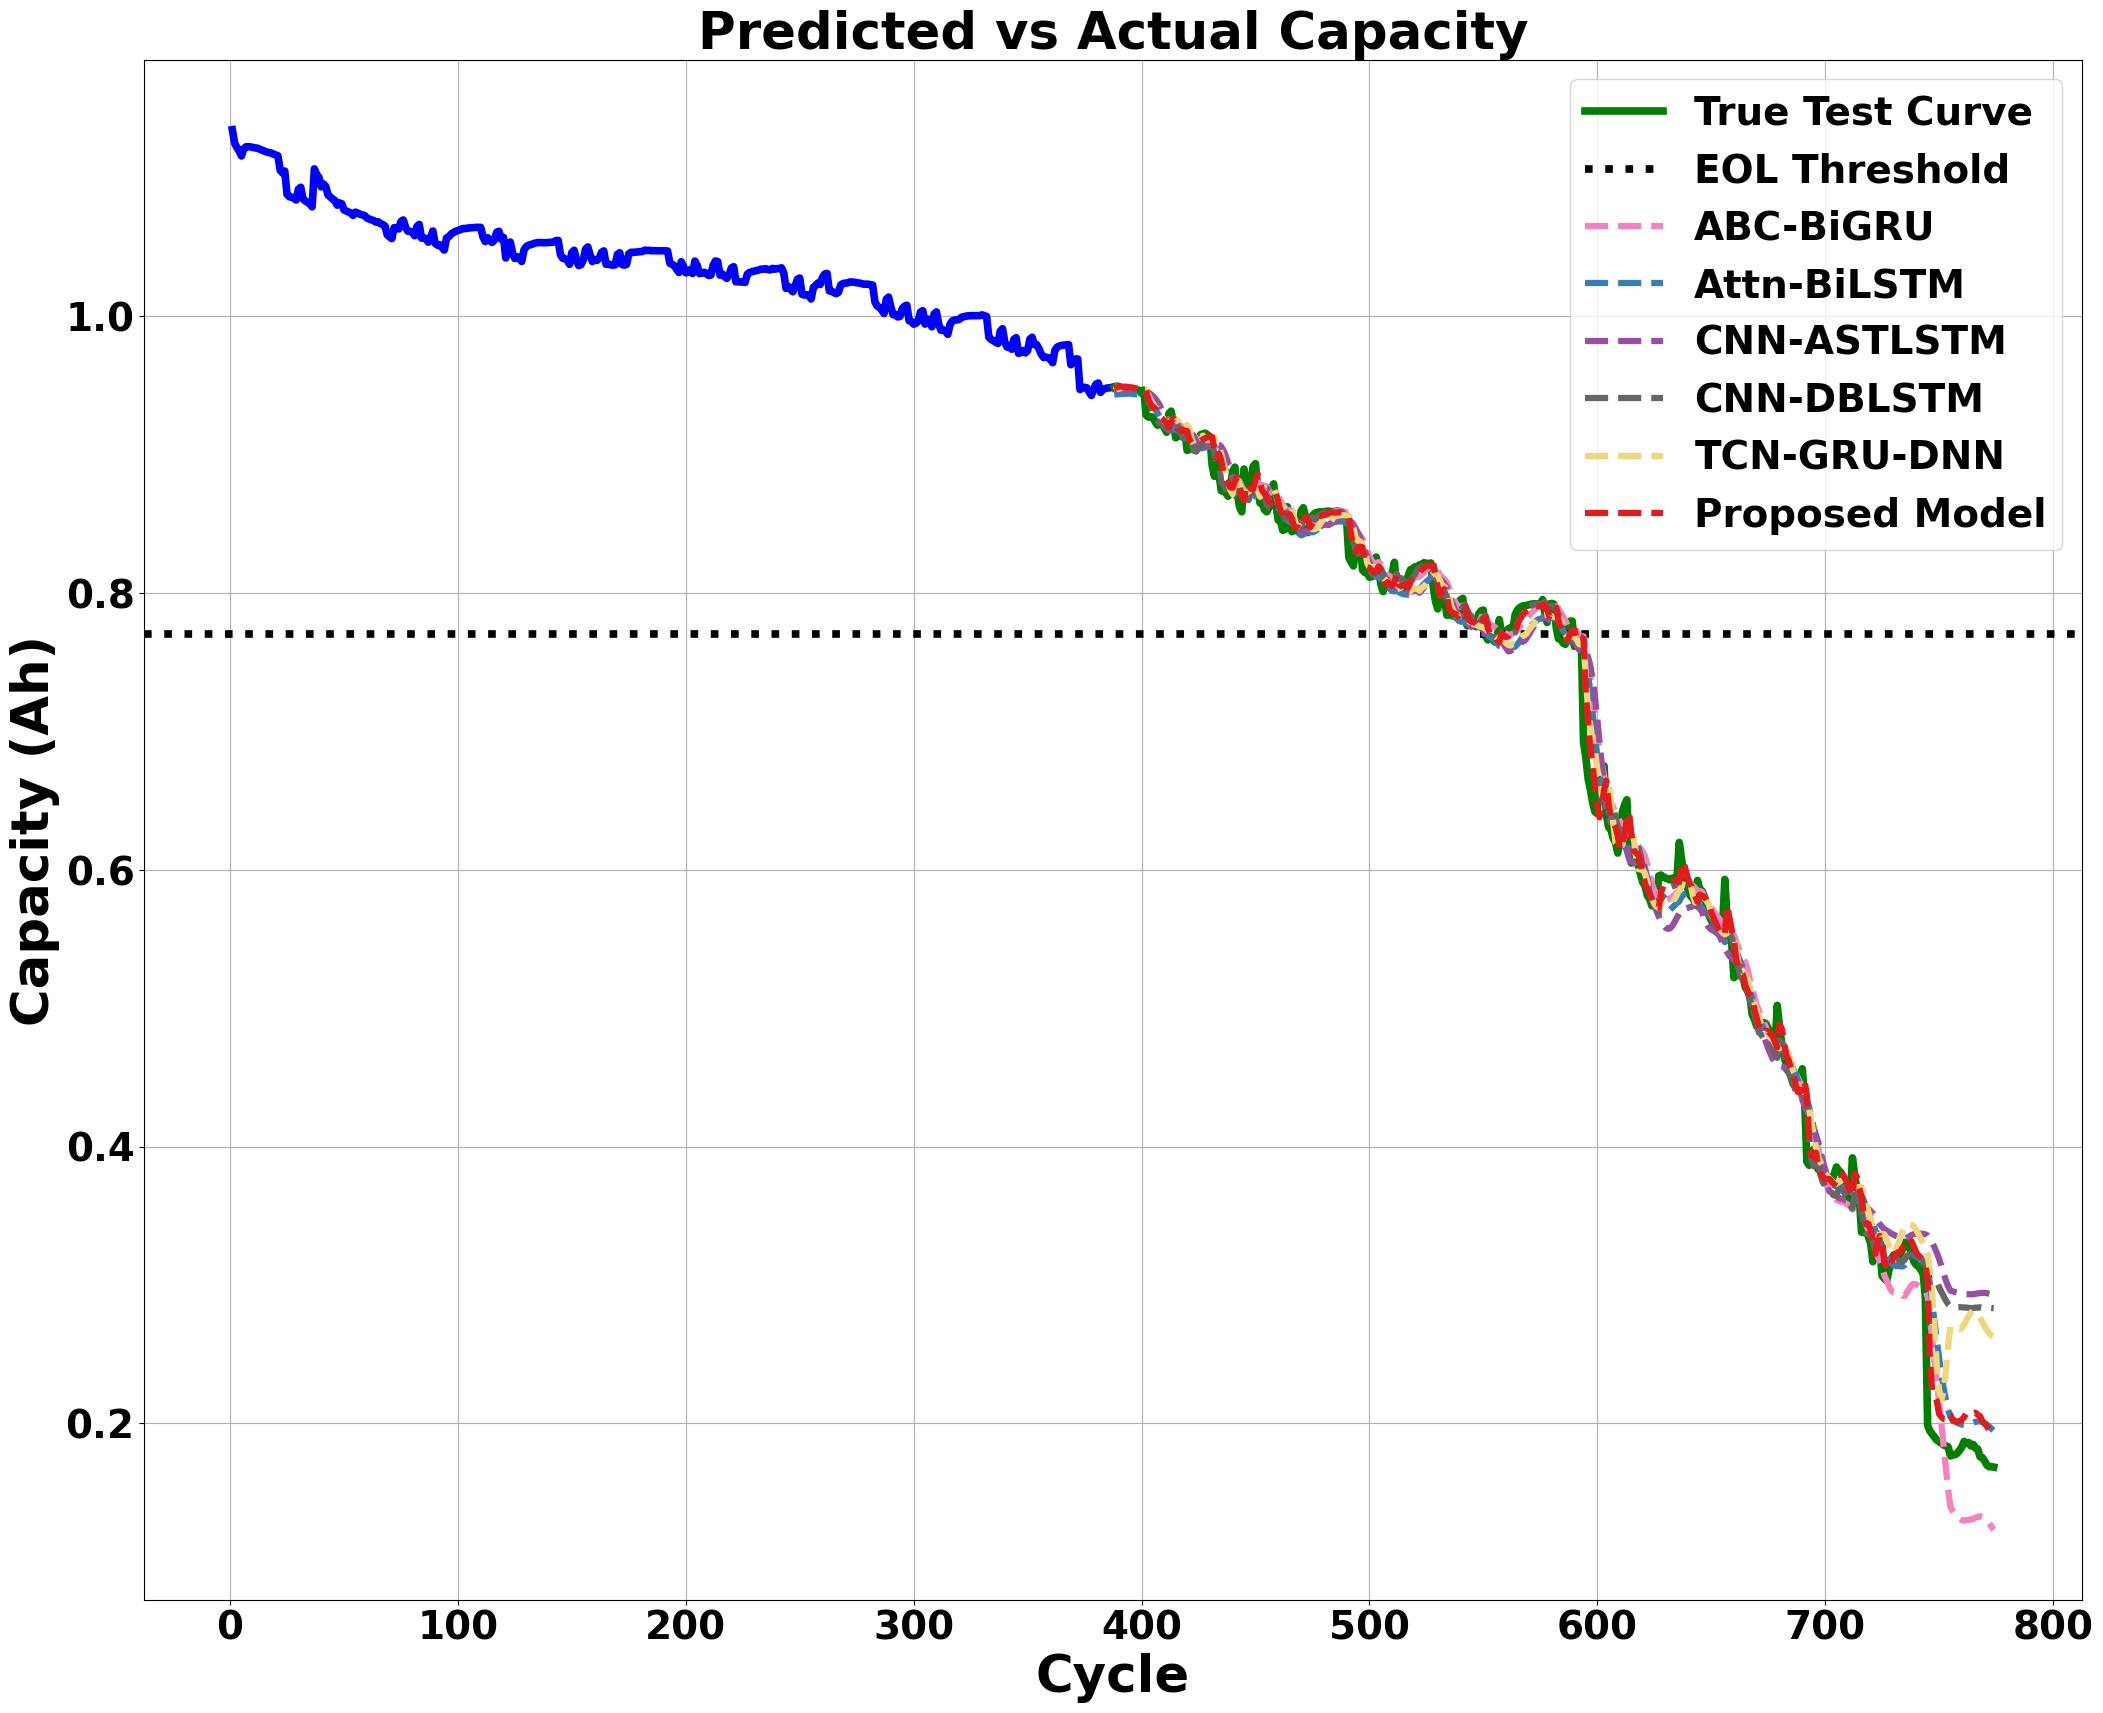

In [29]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[1],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[1]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.011937901842294672
MAE: 0.008700946456566338
------------------------------
Model: Attn-BiLSTM
RMSE: 0.011244105573048847
MAE: 0.007985985621644643
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.014903860341862541
MAE: 0.010357384722460092
------------------------------
Model: CNN-DBLSTM
RMSE: 0.010553175839824173
MAE: 0.007884537283140026
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.014495060201339848
MAE: 0.010922829306592953
------------------------------
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Model: Proposed Model
RMSE: 0.008349321744471195
MAE: 0.005591240700716903
------------------------------


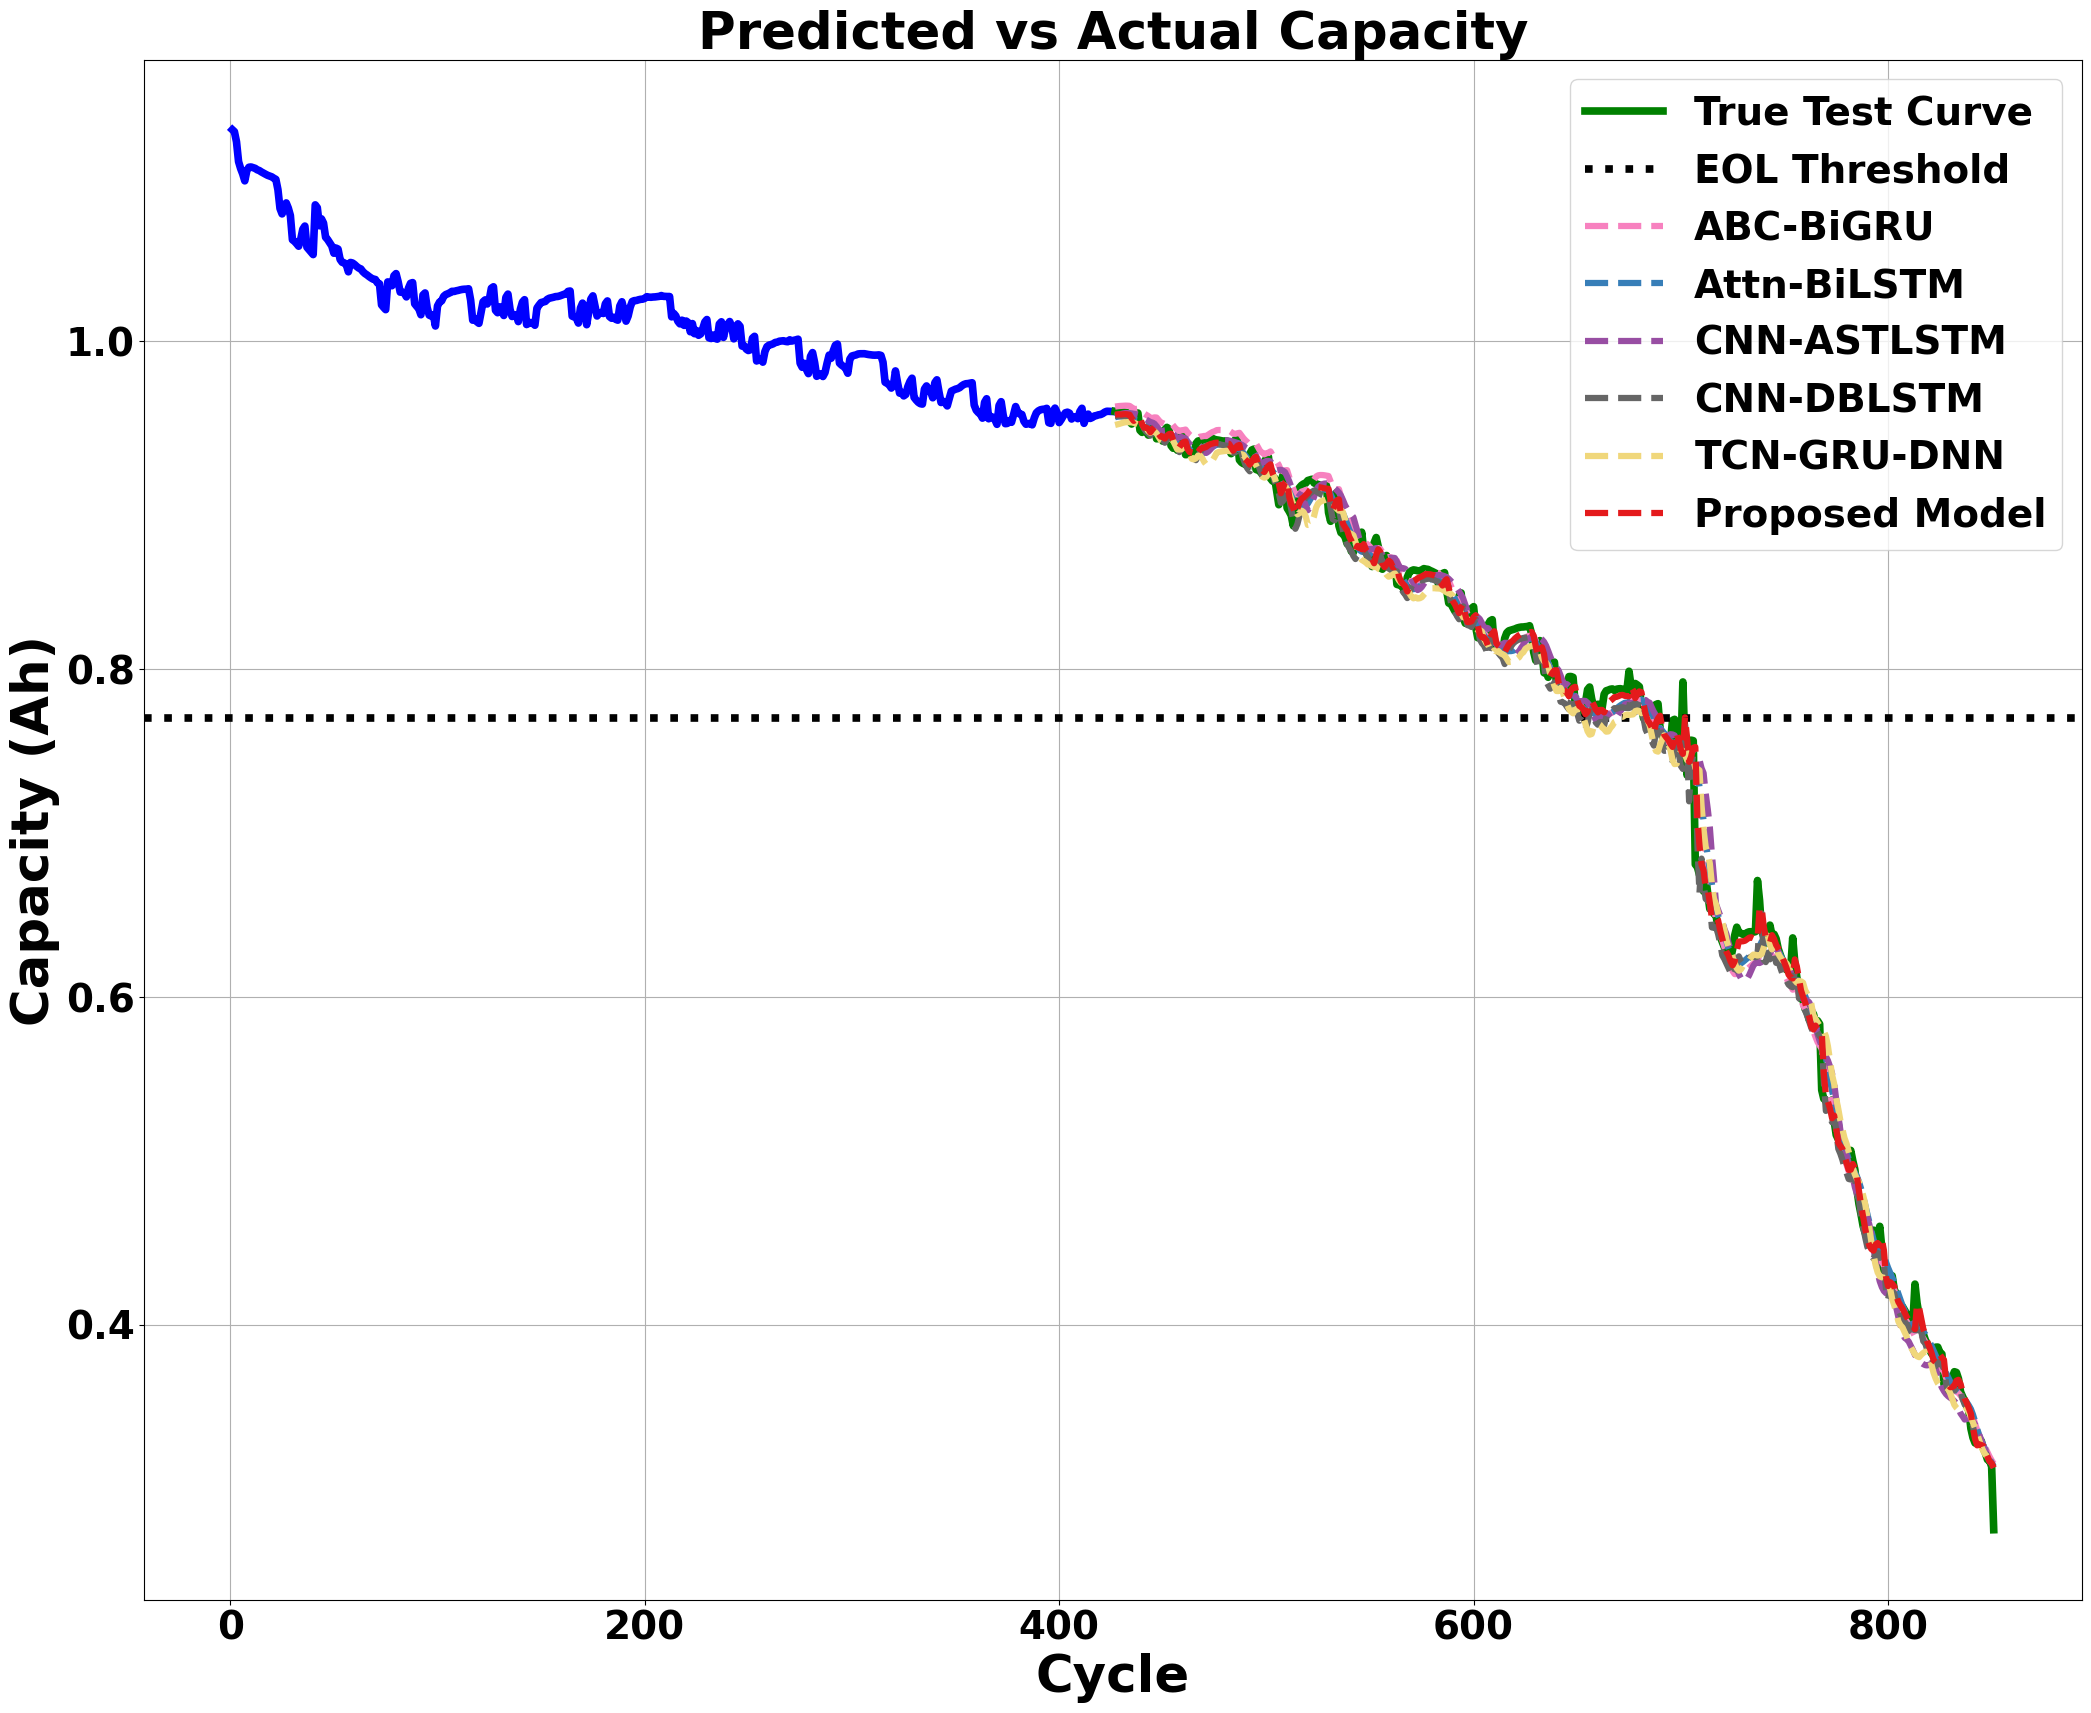

In [30]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[2],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[2]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.013405942637366261
MAE: 0.008446195413317167
------------------------------
Model: Attn-BiLSTM
RMSE: 0.013556624820158798
MAE: 0.008679828956311935
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.01740480782514518
MAE: 0.011091854725930033
------------------------------
Model: CNN-DBLSTM
RMSE: 0.009866645794676525
MAE: 0.006963293272676918
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.013900560889751643
MAE: 0.00921761876395574
------------------------------
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Model: Proposed Model
RMSE: 0.008815031611351679
MAE: 0.0053317952375494
------------------------------


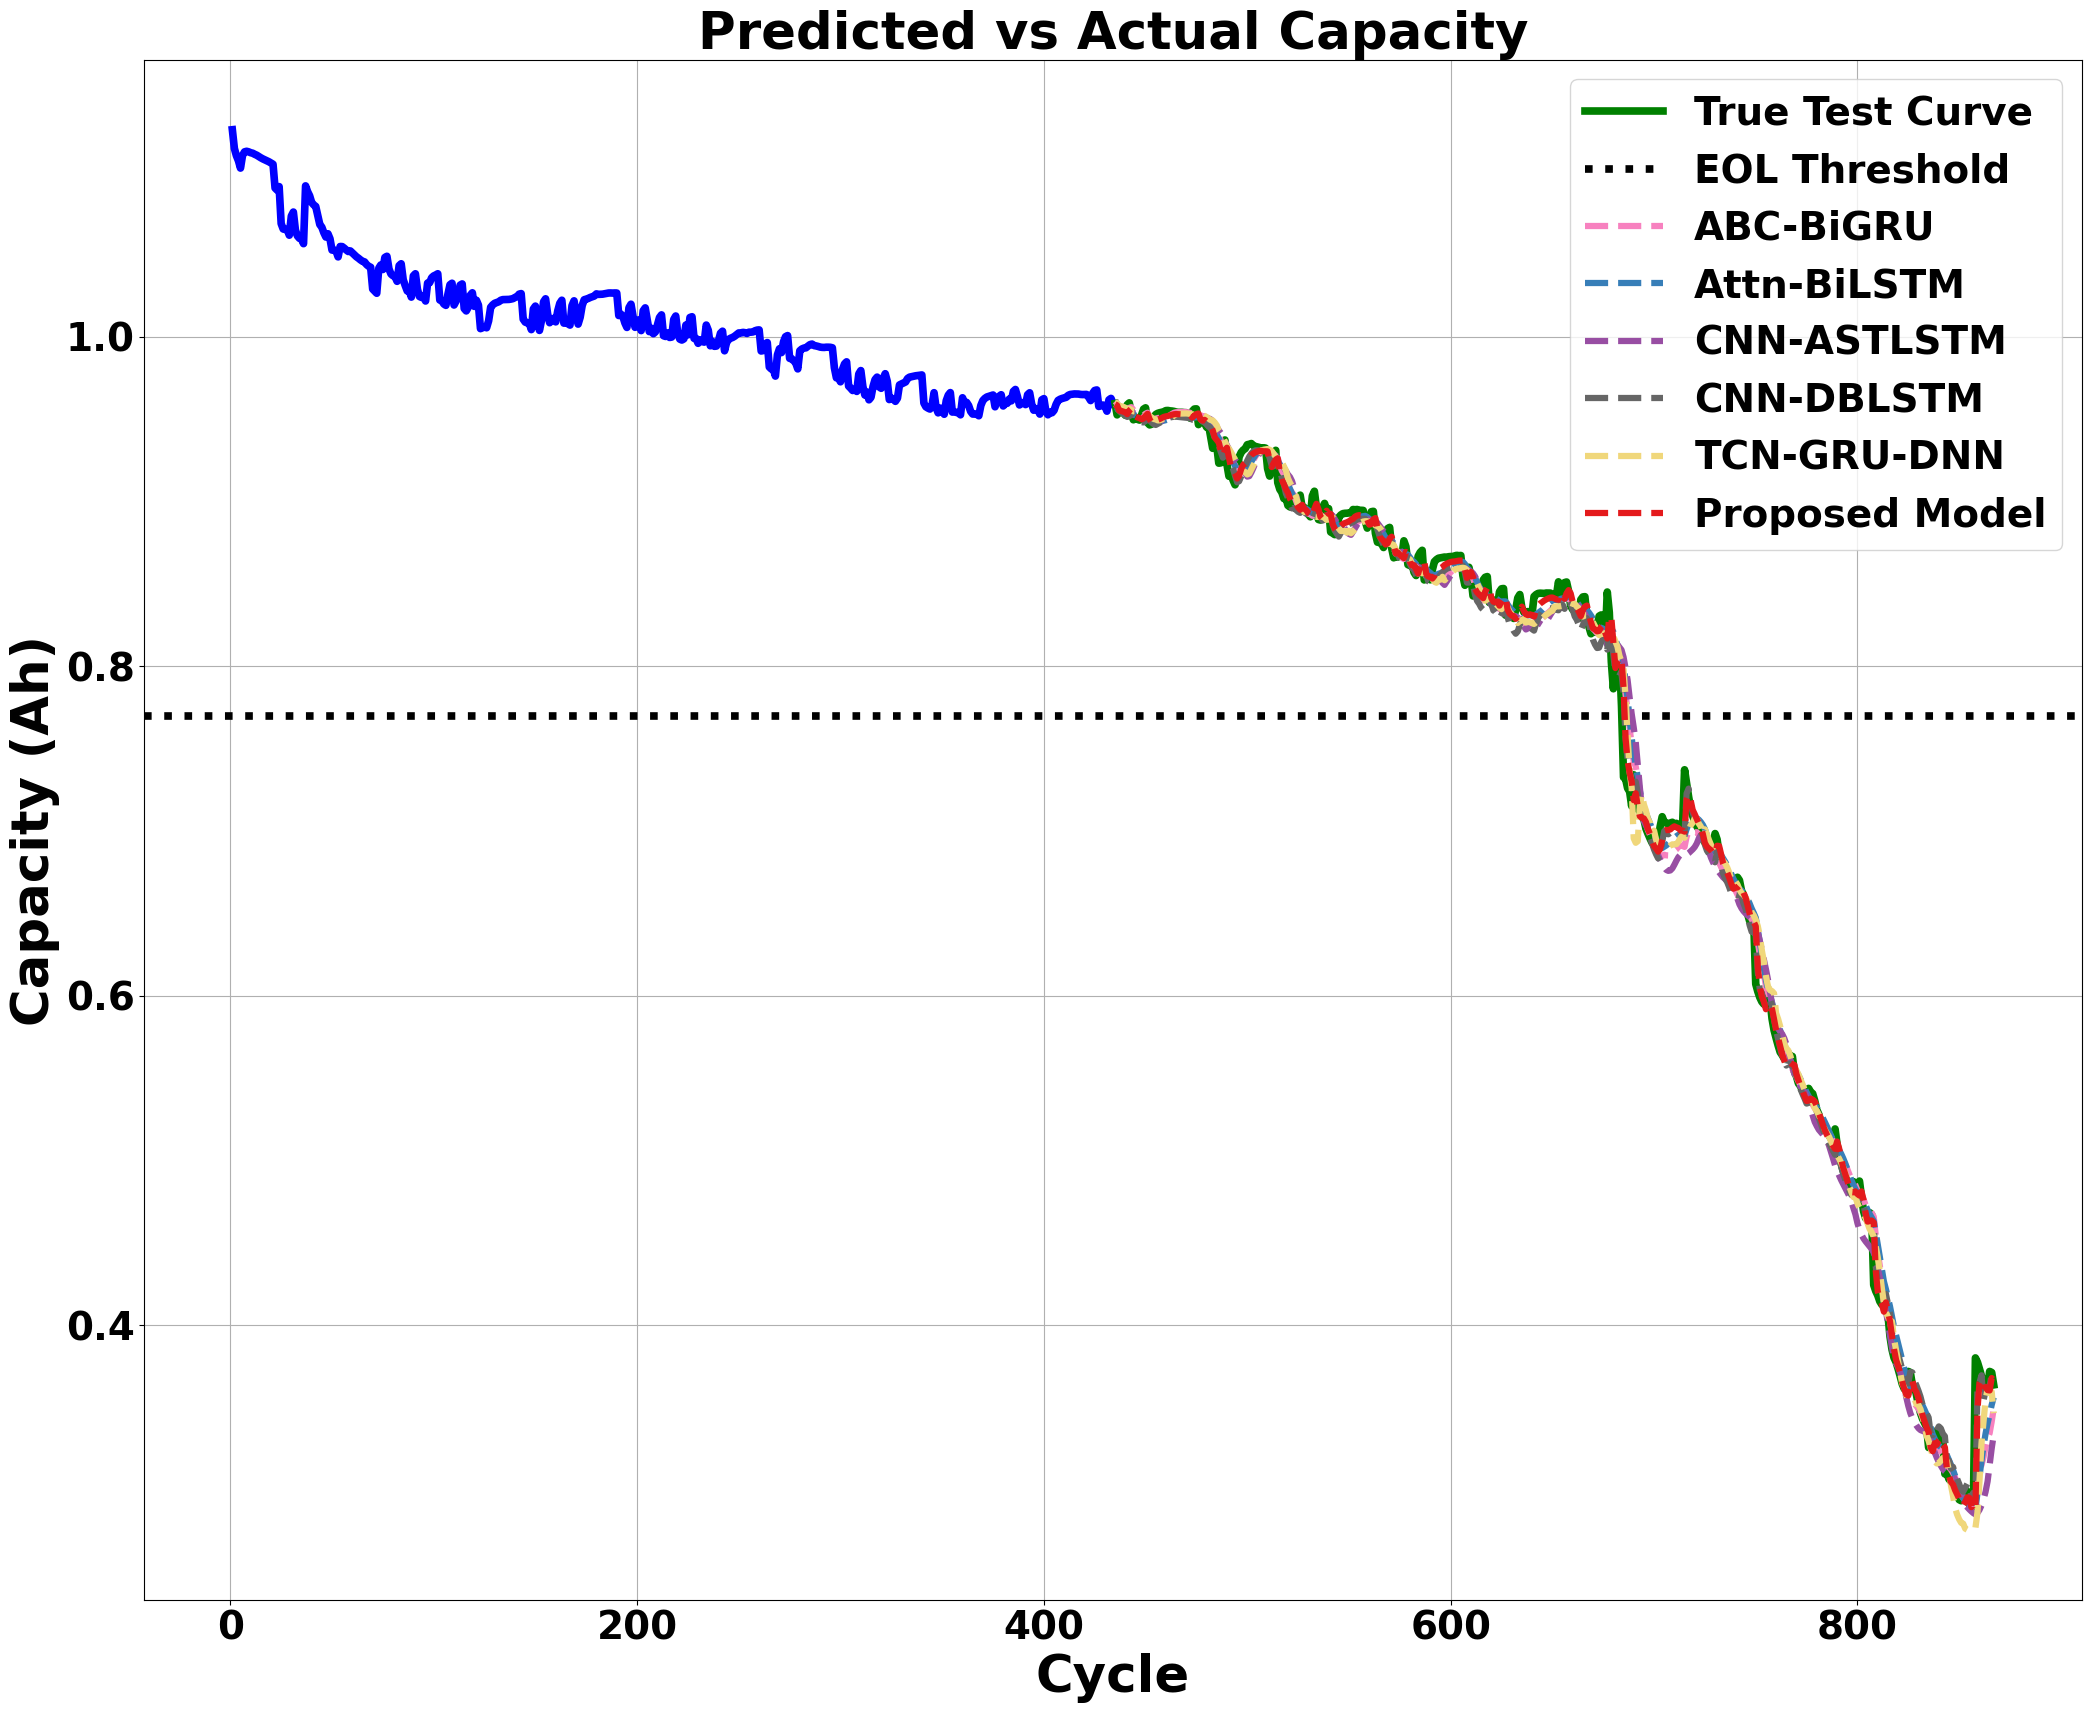

In [31]:
plot_predictions(
    models,
    dfs,
    CALCEDatasetConstants.BATTERY_NUMBERS.value[3],
    generate_sliding_window_data,
    MIN,
    DIFF,
    device=device,
    window_size=10,
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{CALCEDatasetConstants.BATTERY_NAMES.value[3]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)

## NASA Dataset

In [32]:
nasa_dfs = {NASADatasetConstants.BATTERY_NAMES.value[i]: \
       pd.read_csv(NASADatasetConstants.BATTERY_FILEPATHS.value[i]) for i in range(len(NASADatasetConstants.BATTERY_NAMES.value))}
nasa_dfs

{'B0005':      cycle  amb_temp              date_time  voltage_battery  current_battery  \
 0        1        24  02 Apr 2008, 15:25:41         3.277170        -0.006528   
 1        3        24  02 Apr 2008, 19:43:48         3.300245        -0.000448   
 2        5        24  03 Apr 2008, 00:01:06         3.327451         0.001026   
 3        7        24  03 Apr 2008, 04:16:37         3.314182        -0.002234   
 4        9        24  03 Apr 2008, 08:33:25         3.305497         0.000009   
 ..     ...       ...                    ...              ...              ...   
 163    599        24  26 May 2008, 10:44:38         3.615561        -0.002548   
 164    603        24  26 May 2008, 15:30:43         3.621191        -0.002460   
 165    607        24  26 May 2008, 20:21:04         3.619185         0.000478   
 166    611        24  27 May 2008, 15:52:41         3.595365        -0.002342   
 167    613        24  27 May 2008, 20:45:42         3.589937        -0.000583   
 
     

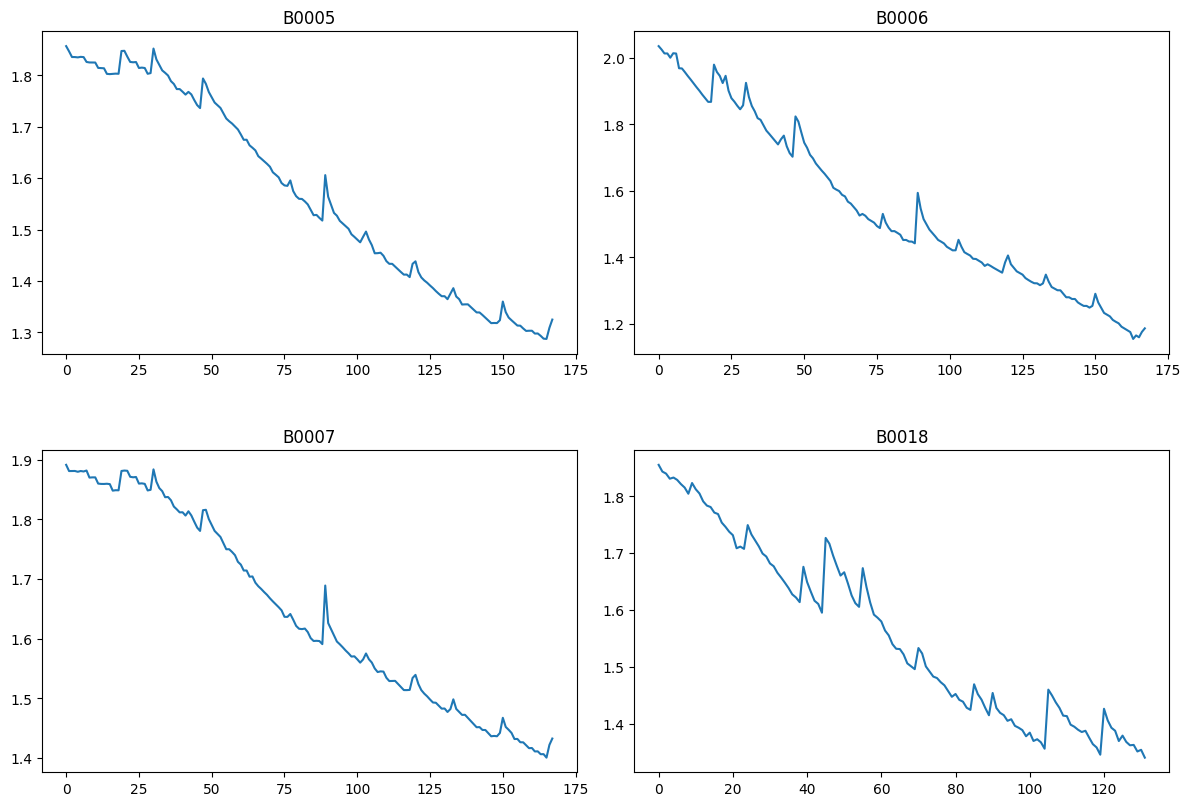

In [33]:
fig, ax = plt.subplots(nrows=int(len(nasa_dfs)/2), ncols=2, figsize=(12, 8))
fig.tight_layout()
plt.subplots_adjust(hspace=0.3)

for i, (battery_number, df) in enumerate(nasa_dfs.items()):
    ax[int(i/2), i%2].plot(df.index, df['capacity'])
    ax[int(i/2), i%2].set_title(f'{battery_number}')

plt.show()

In [34]:
NASADatasetConstants.BATTERY_NAMES.value

['B0005', 'B0006', 'B0007', 'B0018']

In [35]:
MAX = 2.0
MIN = 0.0
DIFF = MAX - MIN

### 0% of test curve for training

In [36]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=5, hidden_size=int(round(1.14038346e+02)), dropout=4.19688530e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(window_size=5),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(
/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model: ABC-BiGRU
RMSE: 0.020989156980418634
MAE: 0.01488482017007621
------------------------------
Model: Attn-BiLSTM
RMSE: 0.015888418235866335
MAE: 0.011260065976281722
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.019140036177985605
MAE: 0.013950613239227782
------------------------------
Model: CNN-DBLSTM
RMSE: 0.02653953624231048
MAE: 0.021738880355455258
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.02290308611223871
MAE: 0.019094299141448667
------------------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step  
Model: Proposed Model
RMSE: 0.013574463167554524
MAE: 0.007728546115363849
------------------------------


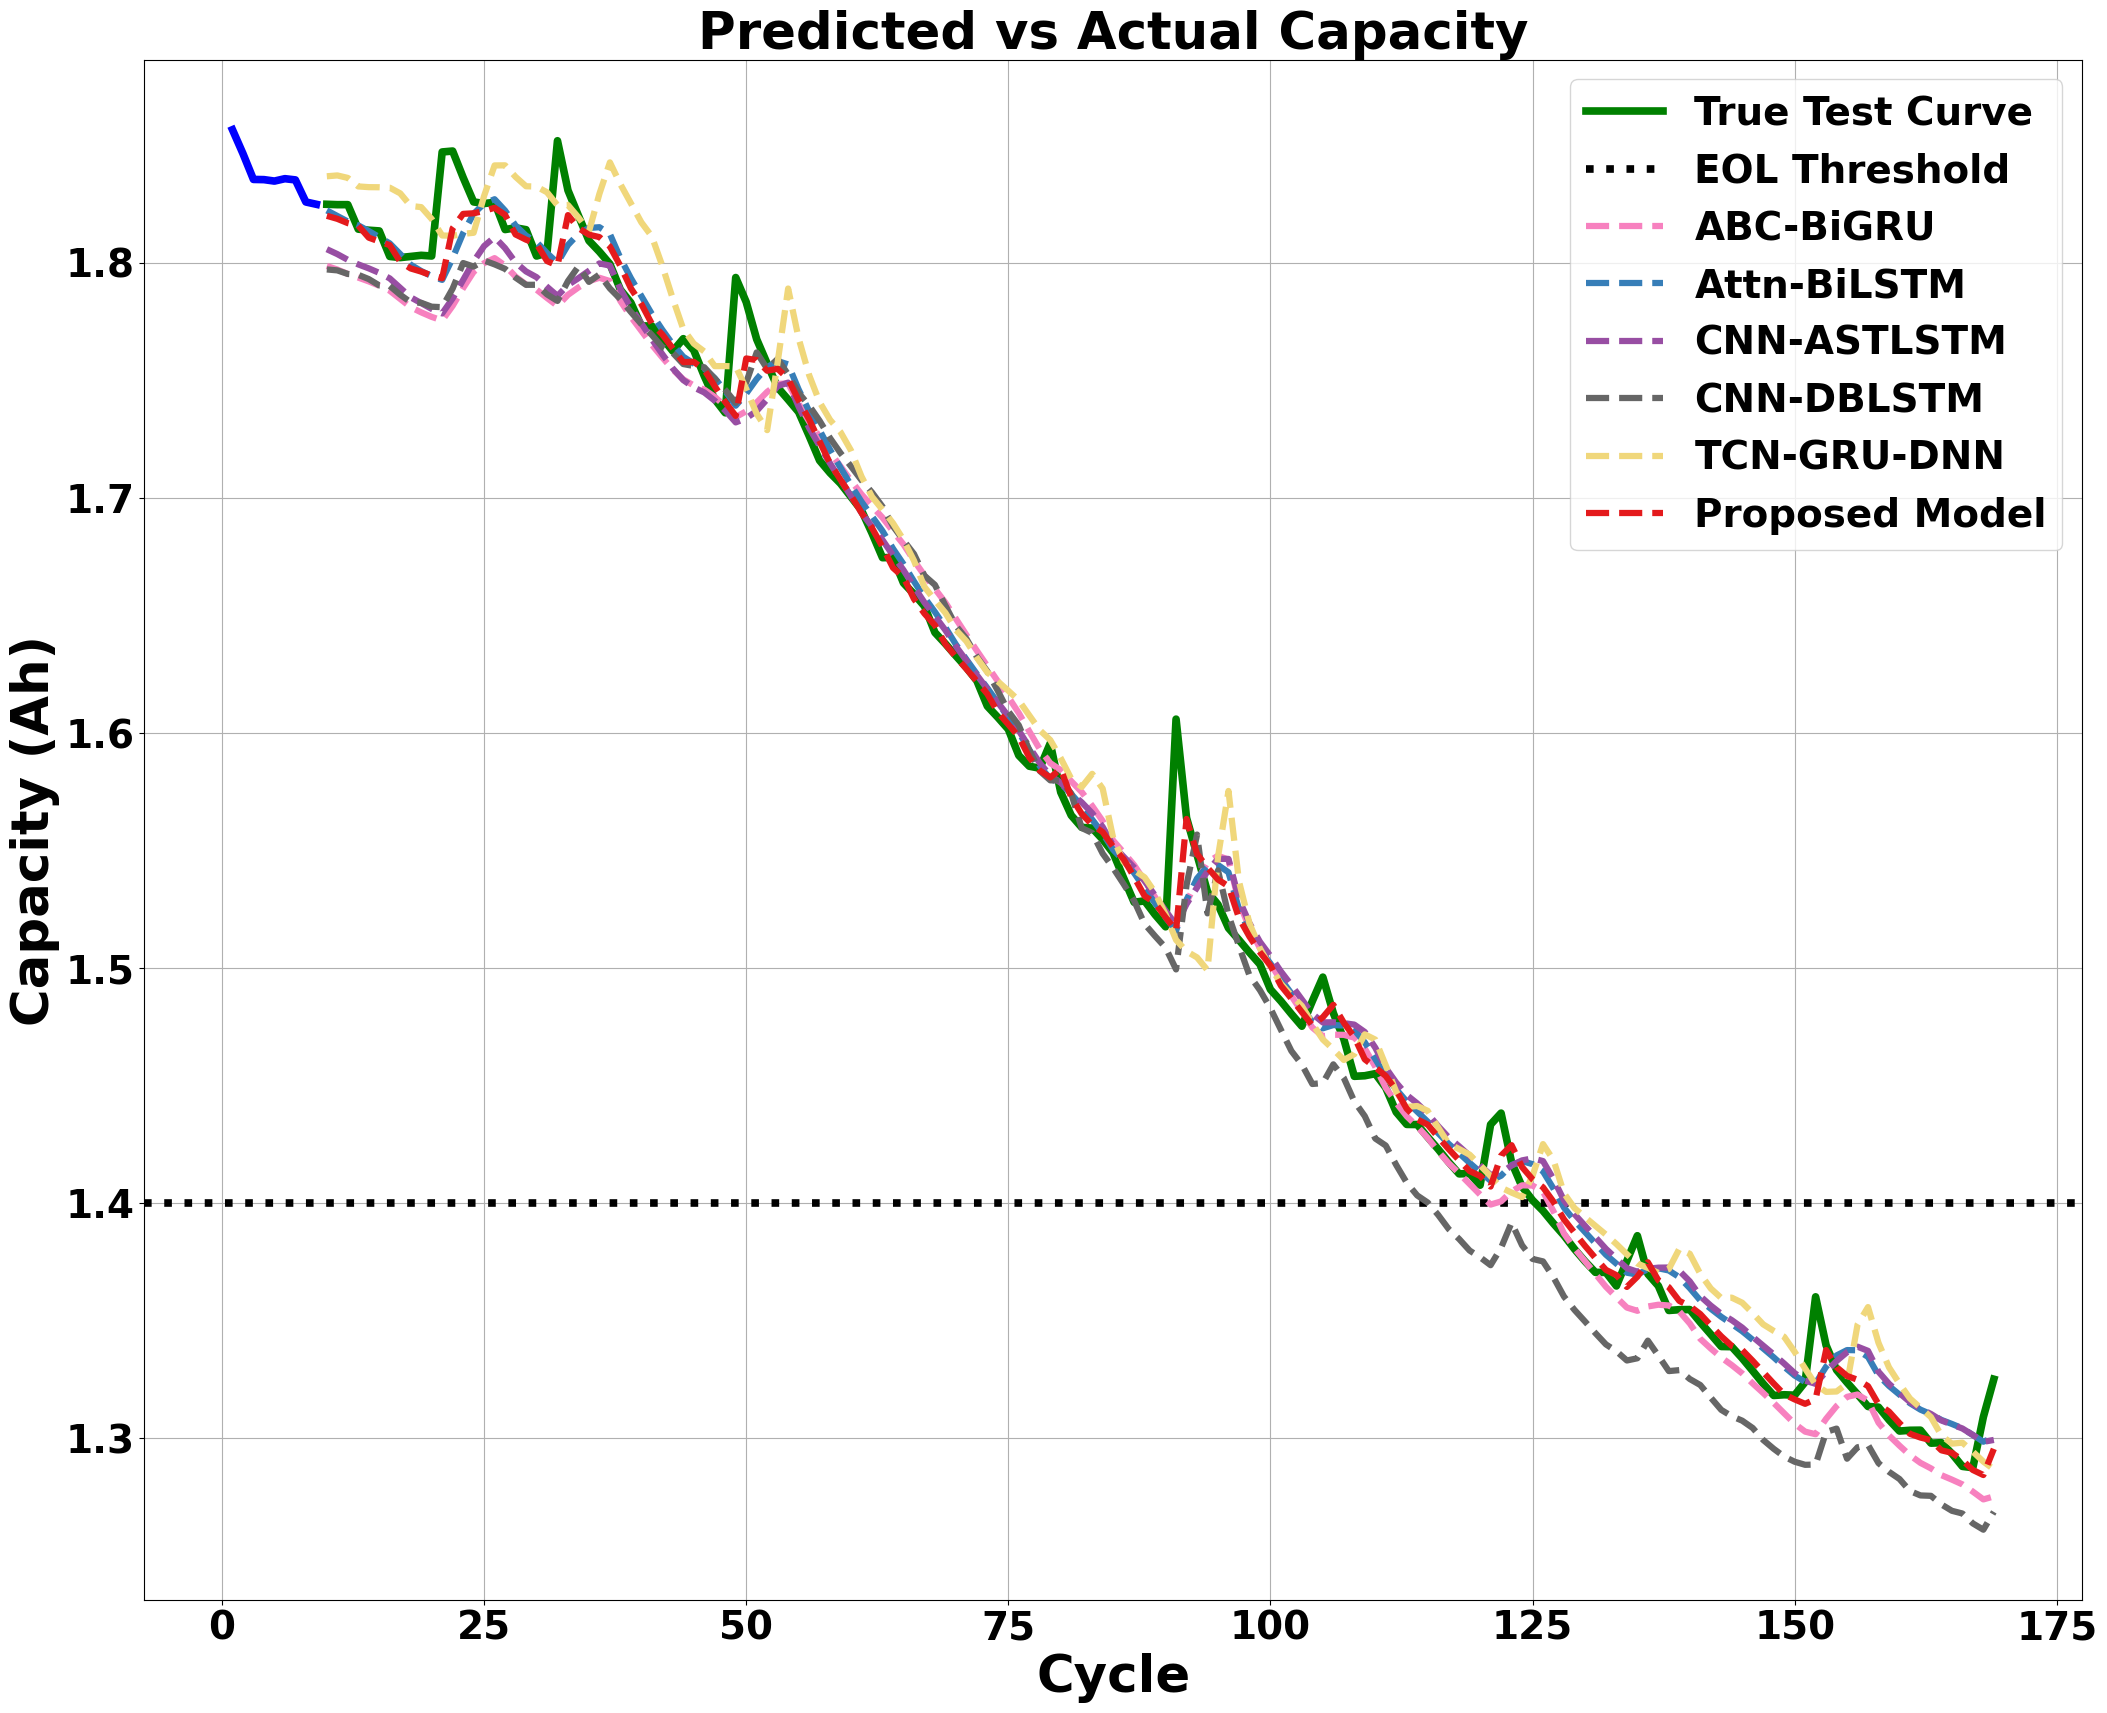

In [38]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[0], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[0]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.05372927442703412
MAE: 0.03311120128838464
------------------------------
Model: Attn-BiLSTM
RMSE: 0.030884798895041907
MAE: 0.02350591239709389
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.055018336447462235
MAE: 0.032962978483179674
------------------------------
Model: CNN-DBLSTM
RMSE: 0.07545843548065118
MAE: 0.05078247571488579
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.041897889569335475
MAE: 0.027620830265616507
------------------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
Model: Proposed Model
RMSE: 0.024470607279924974
MAE: 0.015722218740255735
------------------------------


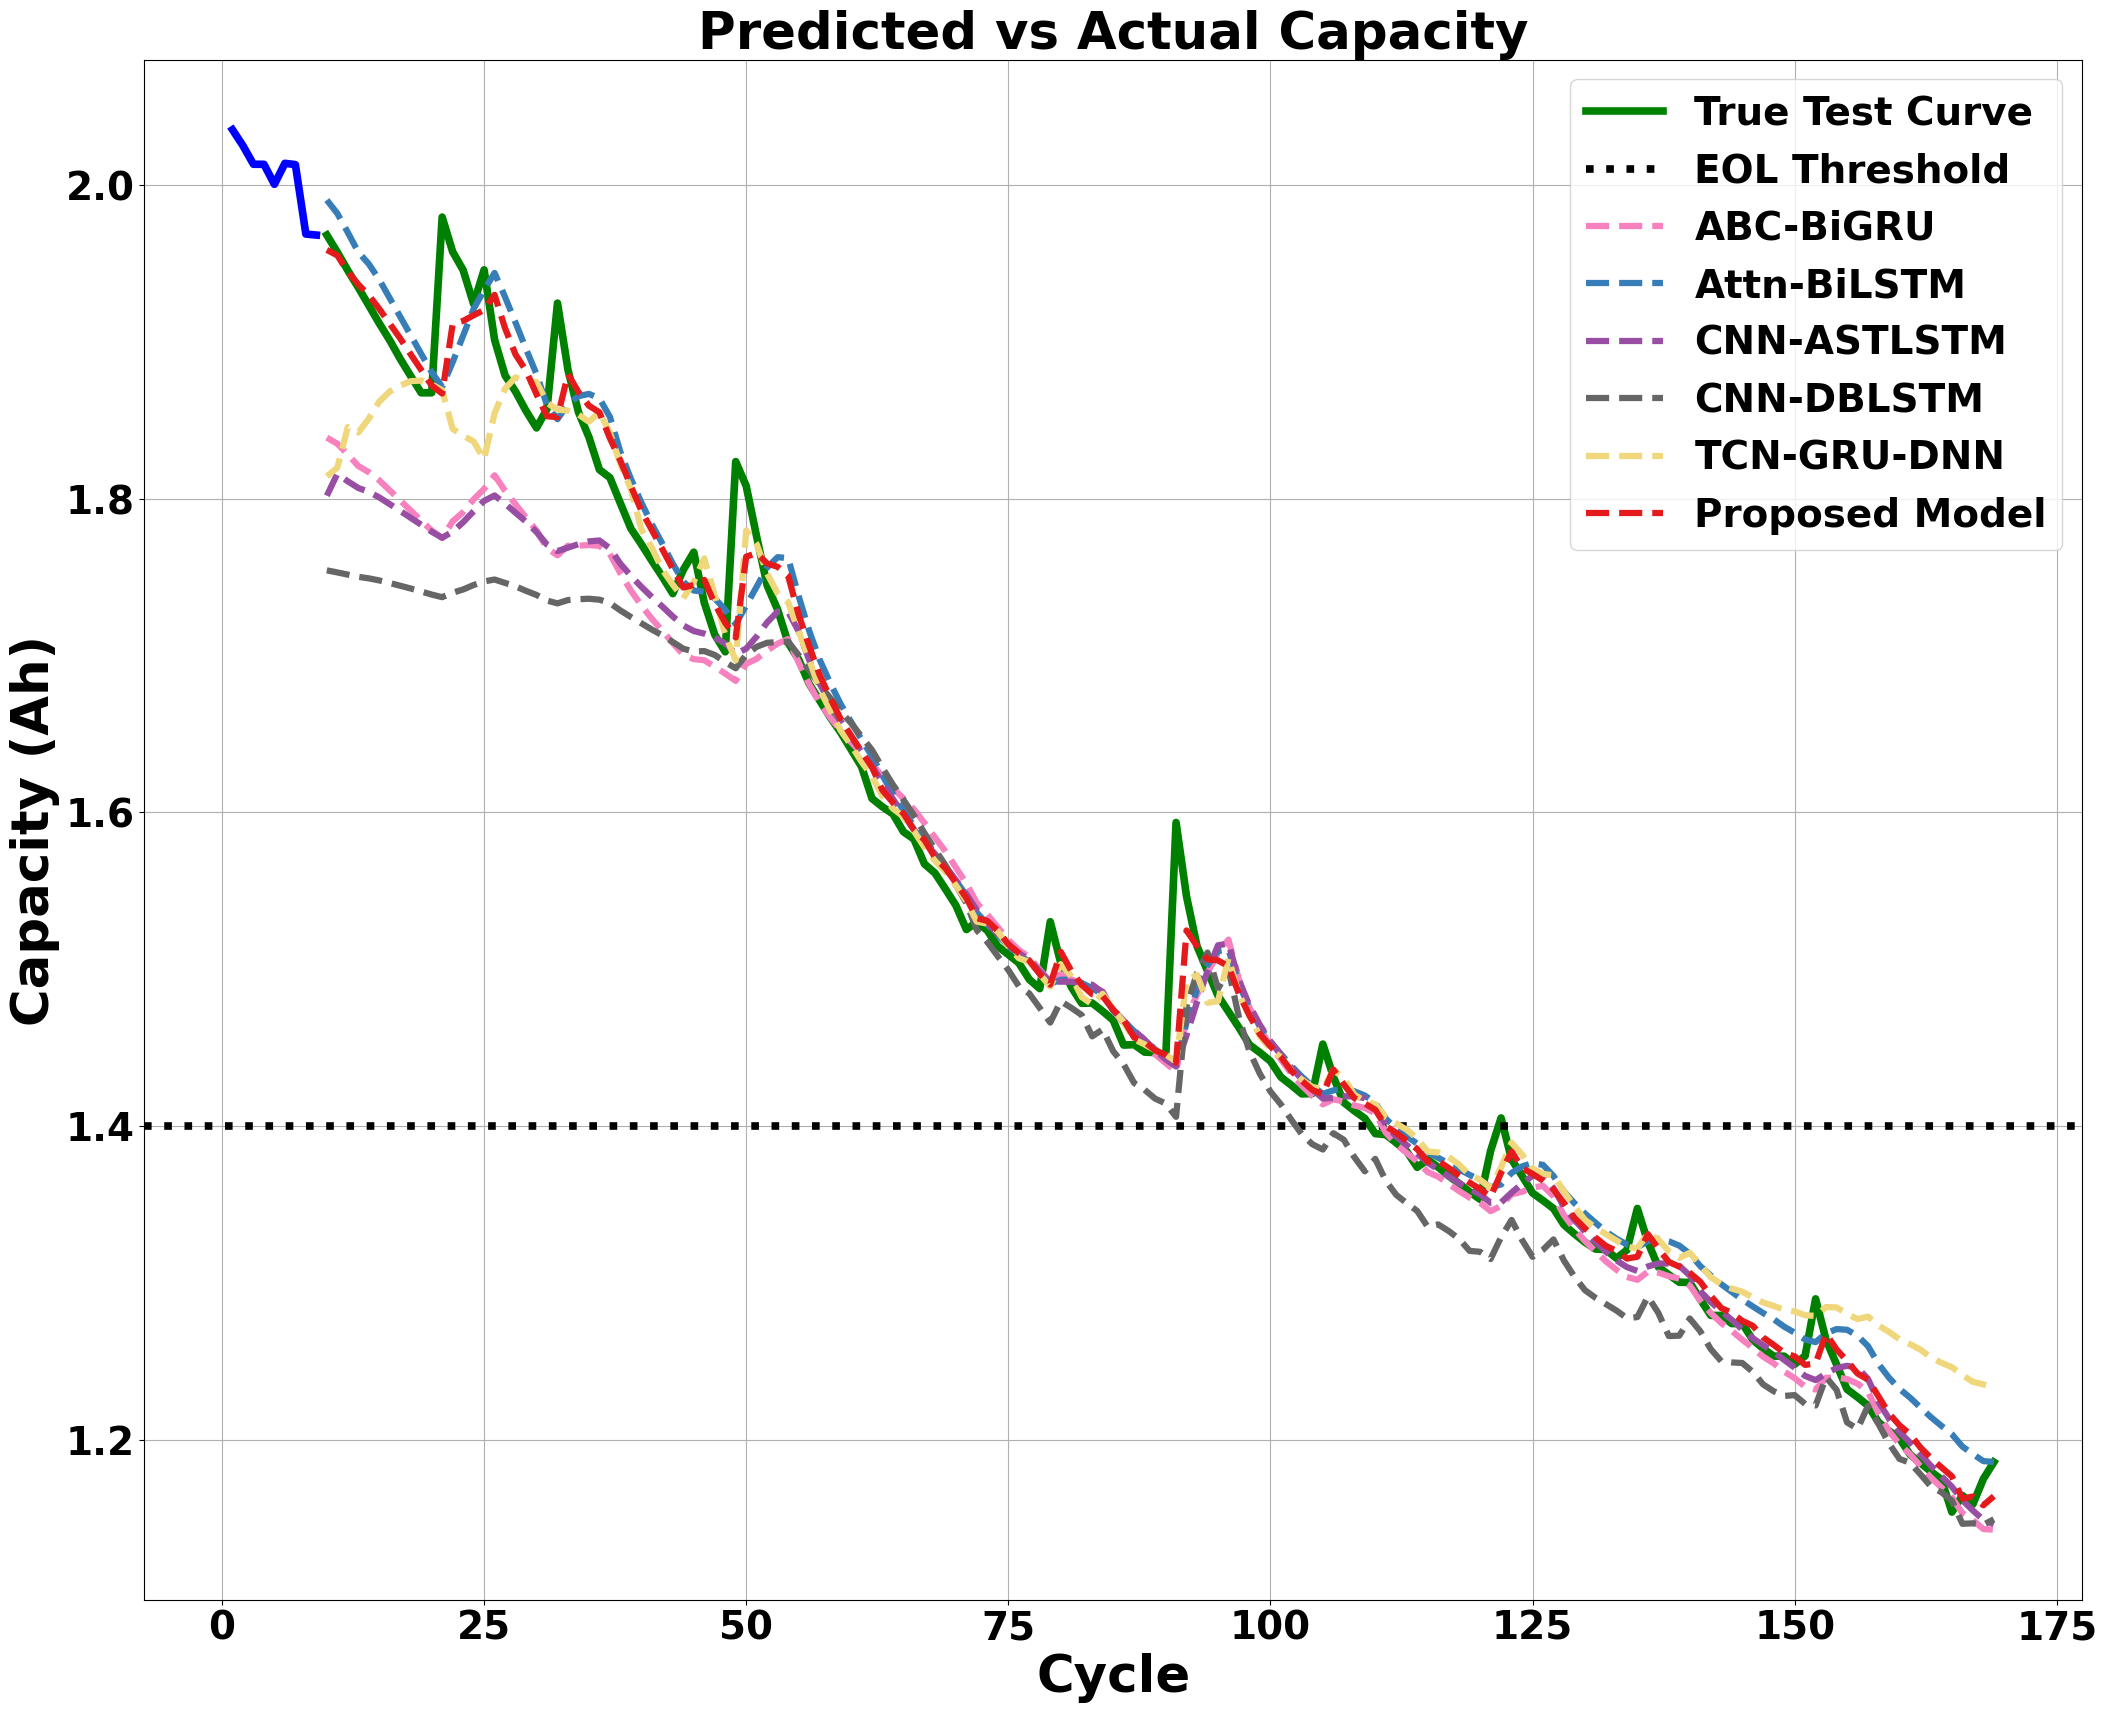

In [39]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[1], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[1]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.024689441370612197
MAE: 0.020453869527255603
------------------------------
Model: Attn-BiLSTM
RMSE: 0.014604193926875132
MAE: 0.0079690026402569
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.015035605150272777
MAE: 0.00864691243294422
------------------------------
Model: CNN-DBLSTM
RMSE: 0.02179011894886378
MAE: 0.01467076348474614
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.01531397662826879
MAE: 0.01005025510892107
------------------------------
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
Model: Proposed Model
RMSE: 0.012194791744913485
MAE: 0.006293131724685555
------------------------------


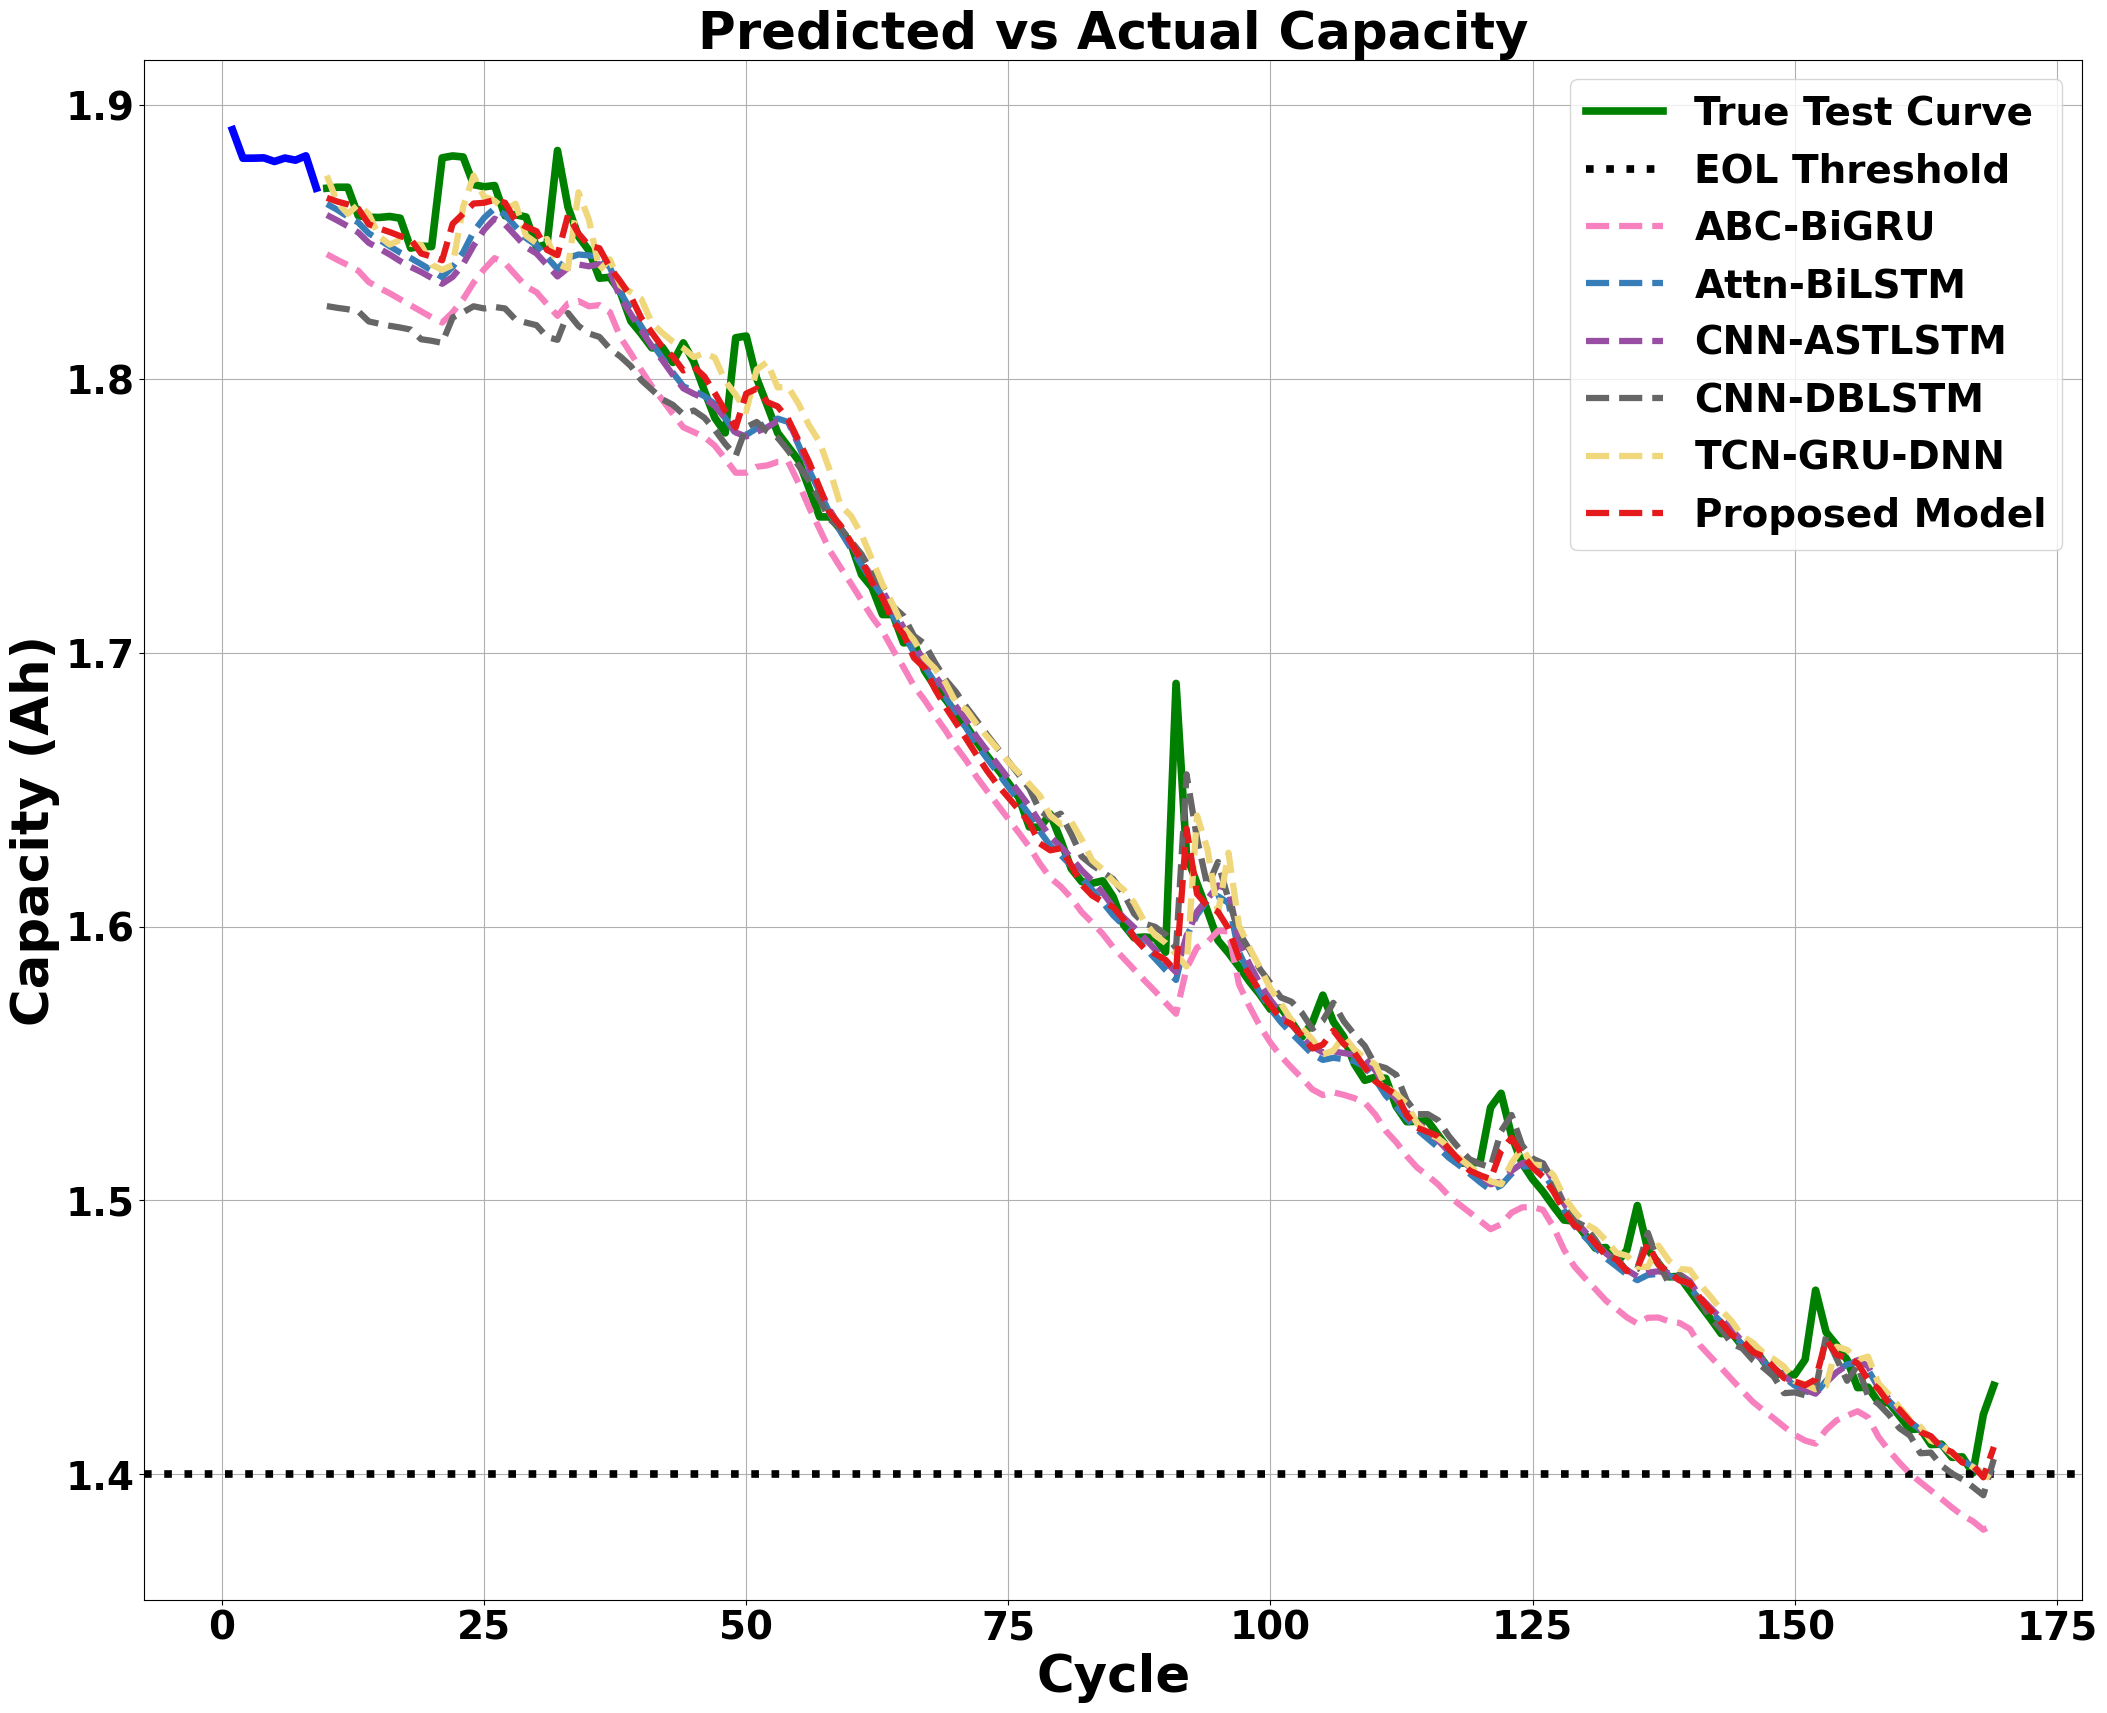

In [41]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[2], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[2]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.03770056327251707
MAE: 0.027824127824649162
------------------------------
Model: Attn-BiLSTM
RMSE: 0.026032155894652086
MAE: 0.01576753065670254
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.026898864212874993
MAE: 0.017433707281978652
------------------------------
Model: CNN-DBLSTM
RMSE: 0.02660997993513915
MAE: 0.018223786681338342
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.026537695731386084
MAE: 0.01822970842411125
------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step
Model: Proposed Model
RMSE: 0.022360498682326823
MAE: 0.012986497064193693
------------------------------


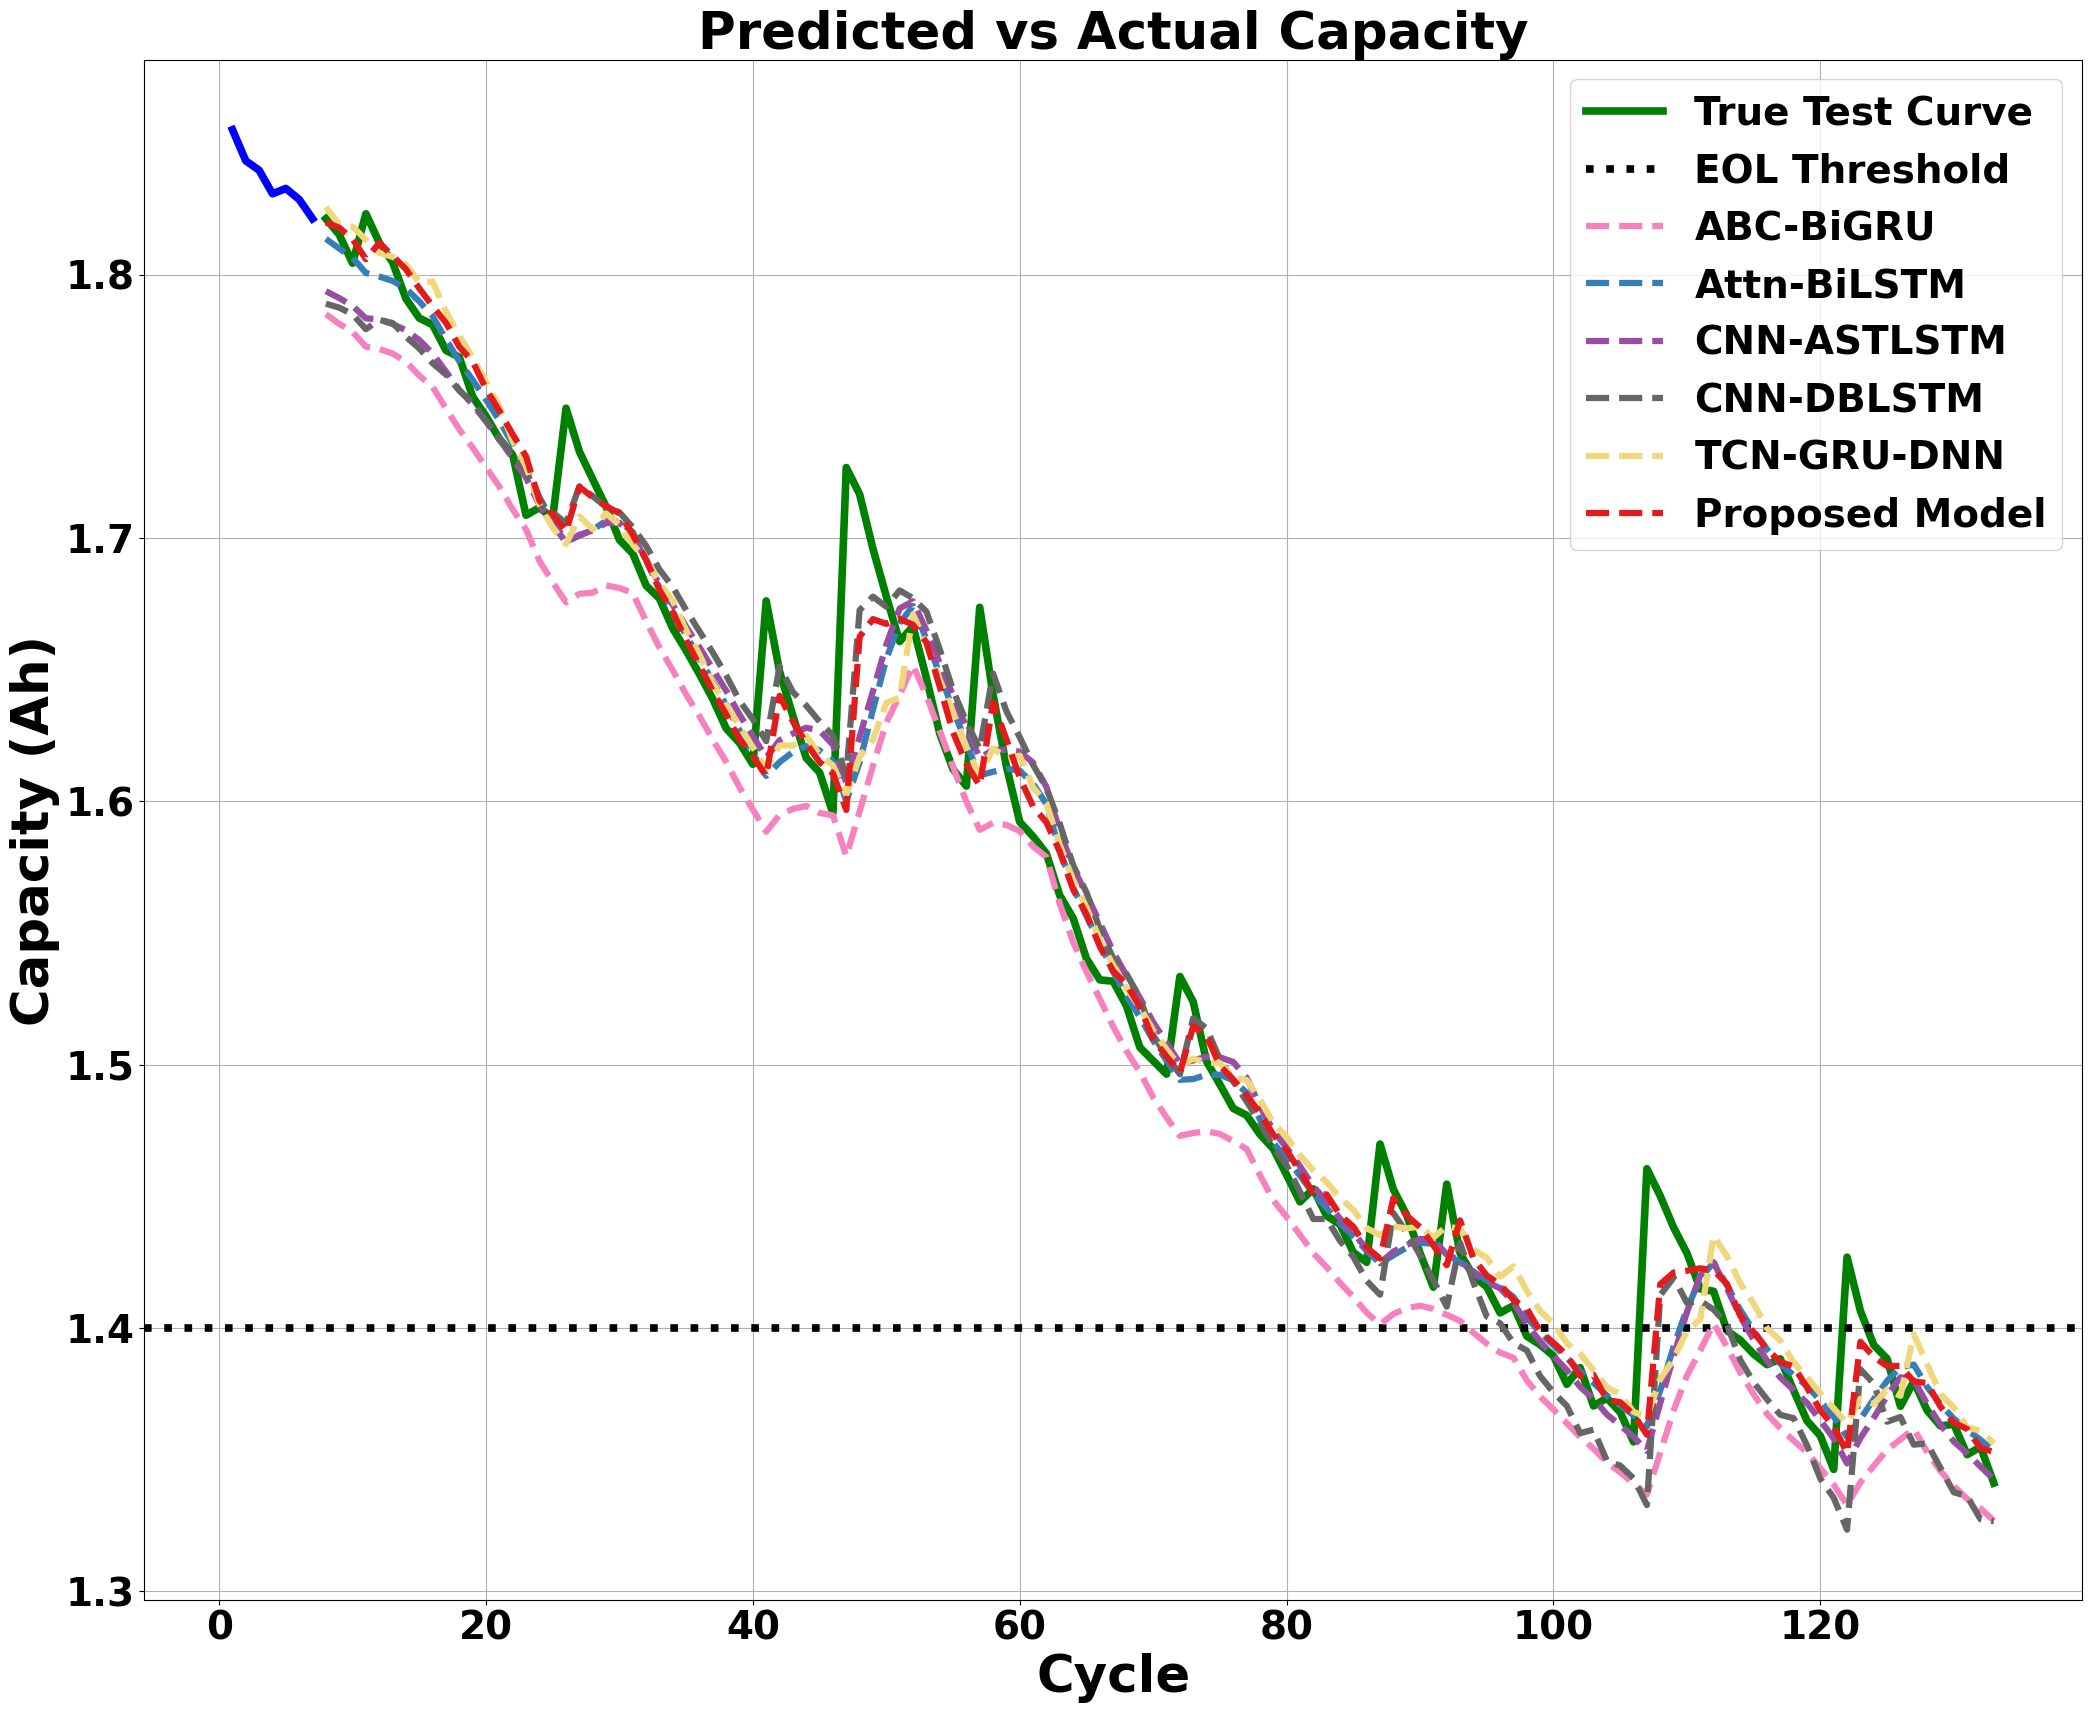

In [42]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[3], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[3]}',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=5,
    figsize=(25, 20),
    colors=COLORS
)

### 30% of test curve for training

In [43]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=5, hidden_size=int(round(120)), dropout=2.23301770e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}_30.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(window_size=5),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_30.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}_30.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(
/home/shubham-mate/Desktop/Programming/Python/Battery RUL Project/venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Model: ABC-BiGRU
RMSE: 0.013485944192017613
MAE: 0.009209770173252942
------------------------------
Model: Attn-BiLSTM
RMSE: 0.014676121361747688
MAE: 0.01095384872264193
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.01605478423671721
MAE: 0.01161272831126192
------------------------------
Model: CNN-DBLSTM
RMSE: 0.013480678687396398
MAE: 0.008965036744125788
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.019134978873166283
MAE: 0.012490723817067012
------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step
Model: Proposed Model
RMSE: 0.013010150350517538
MAE: 0.008031318411064881
------------------------------


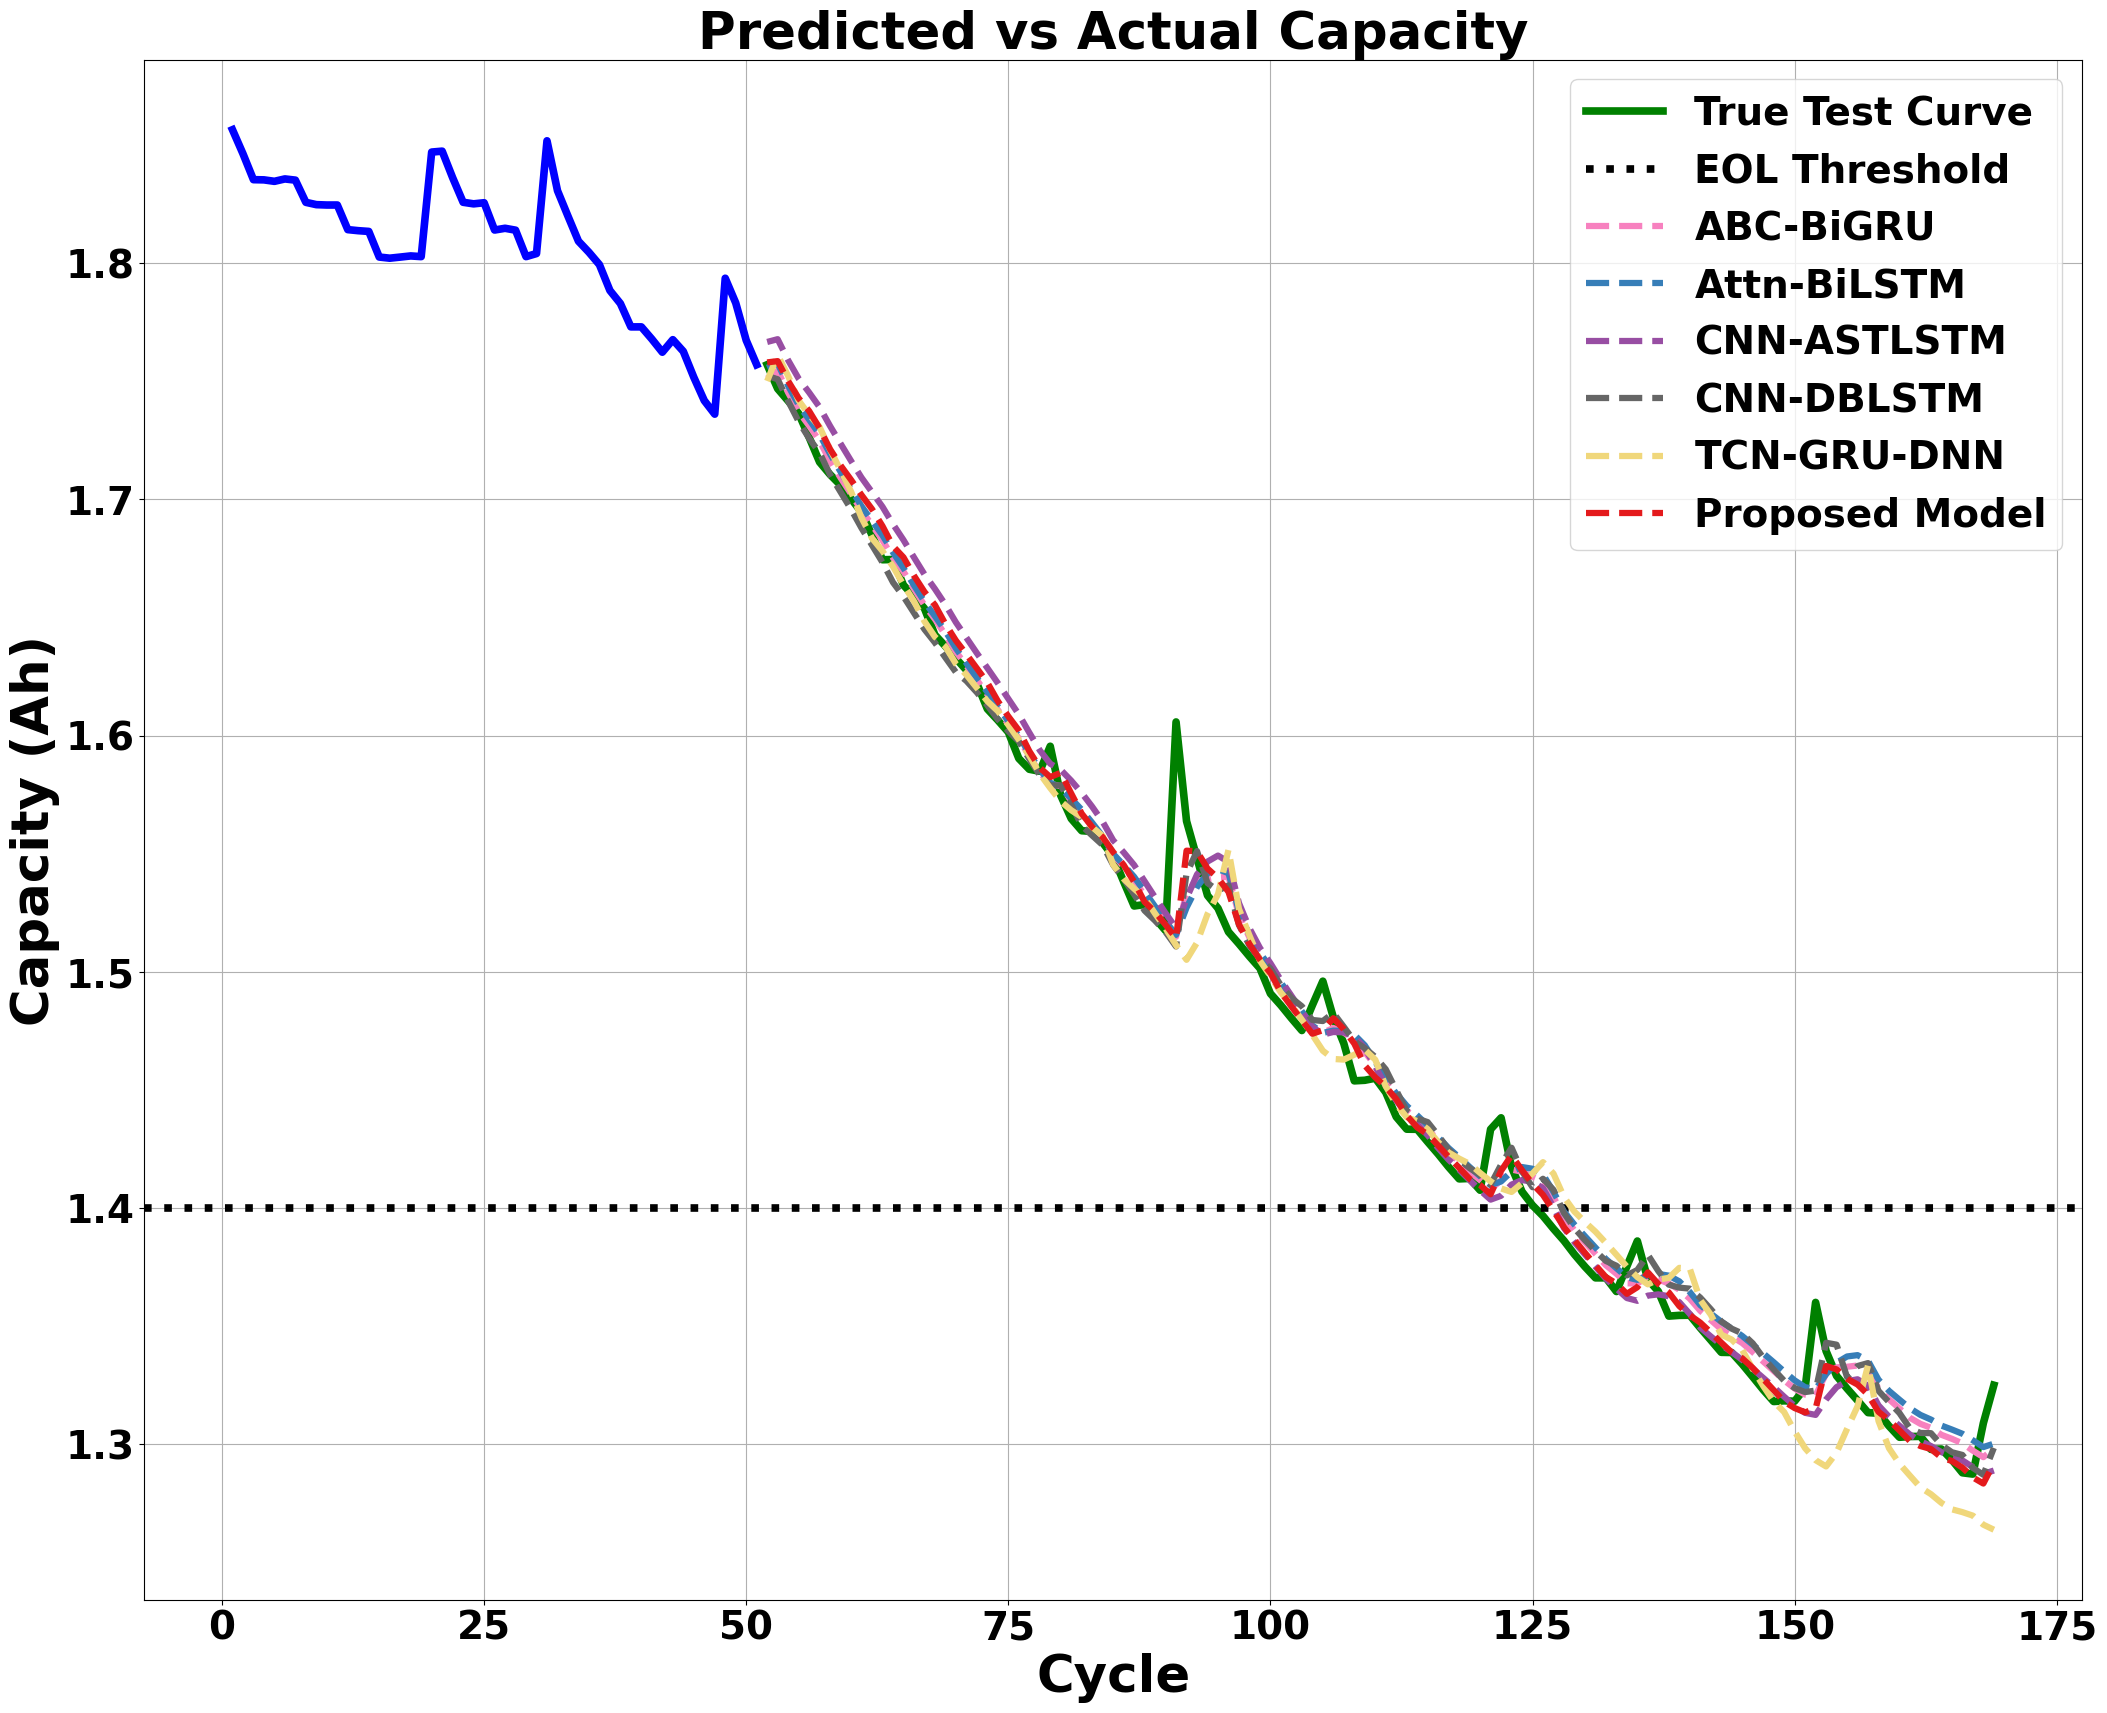

In [45]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[0], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[0]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.032852788515046735
MAE: 0.02890337144792239
------------------------------
Model: Attn-BiLSTM
RMSE: 0.02522847113566155
MAE: 0.018122070491237888
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.033790049682765846
MAE: 0.02442324057500668
------------------------------
Model: CNN-DBLSTM
RMSE: 0.043851467669142295
MAE: 0.0285726262150124
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.04594893660198857
MAE: 0.02805993803676903
------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step
Model: Proposed Model
RMSE: 0.021183770683058652
MAE: 0.013951003682223859
------------------------------


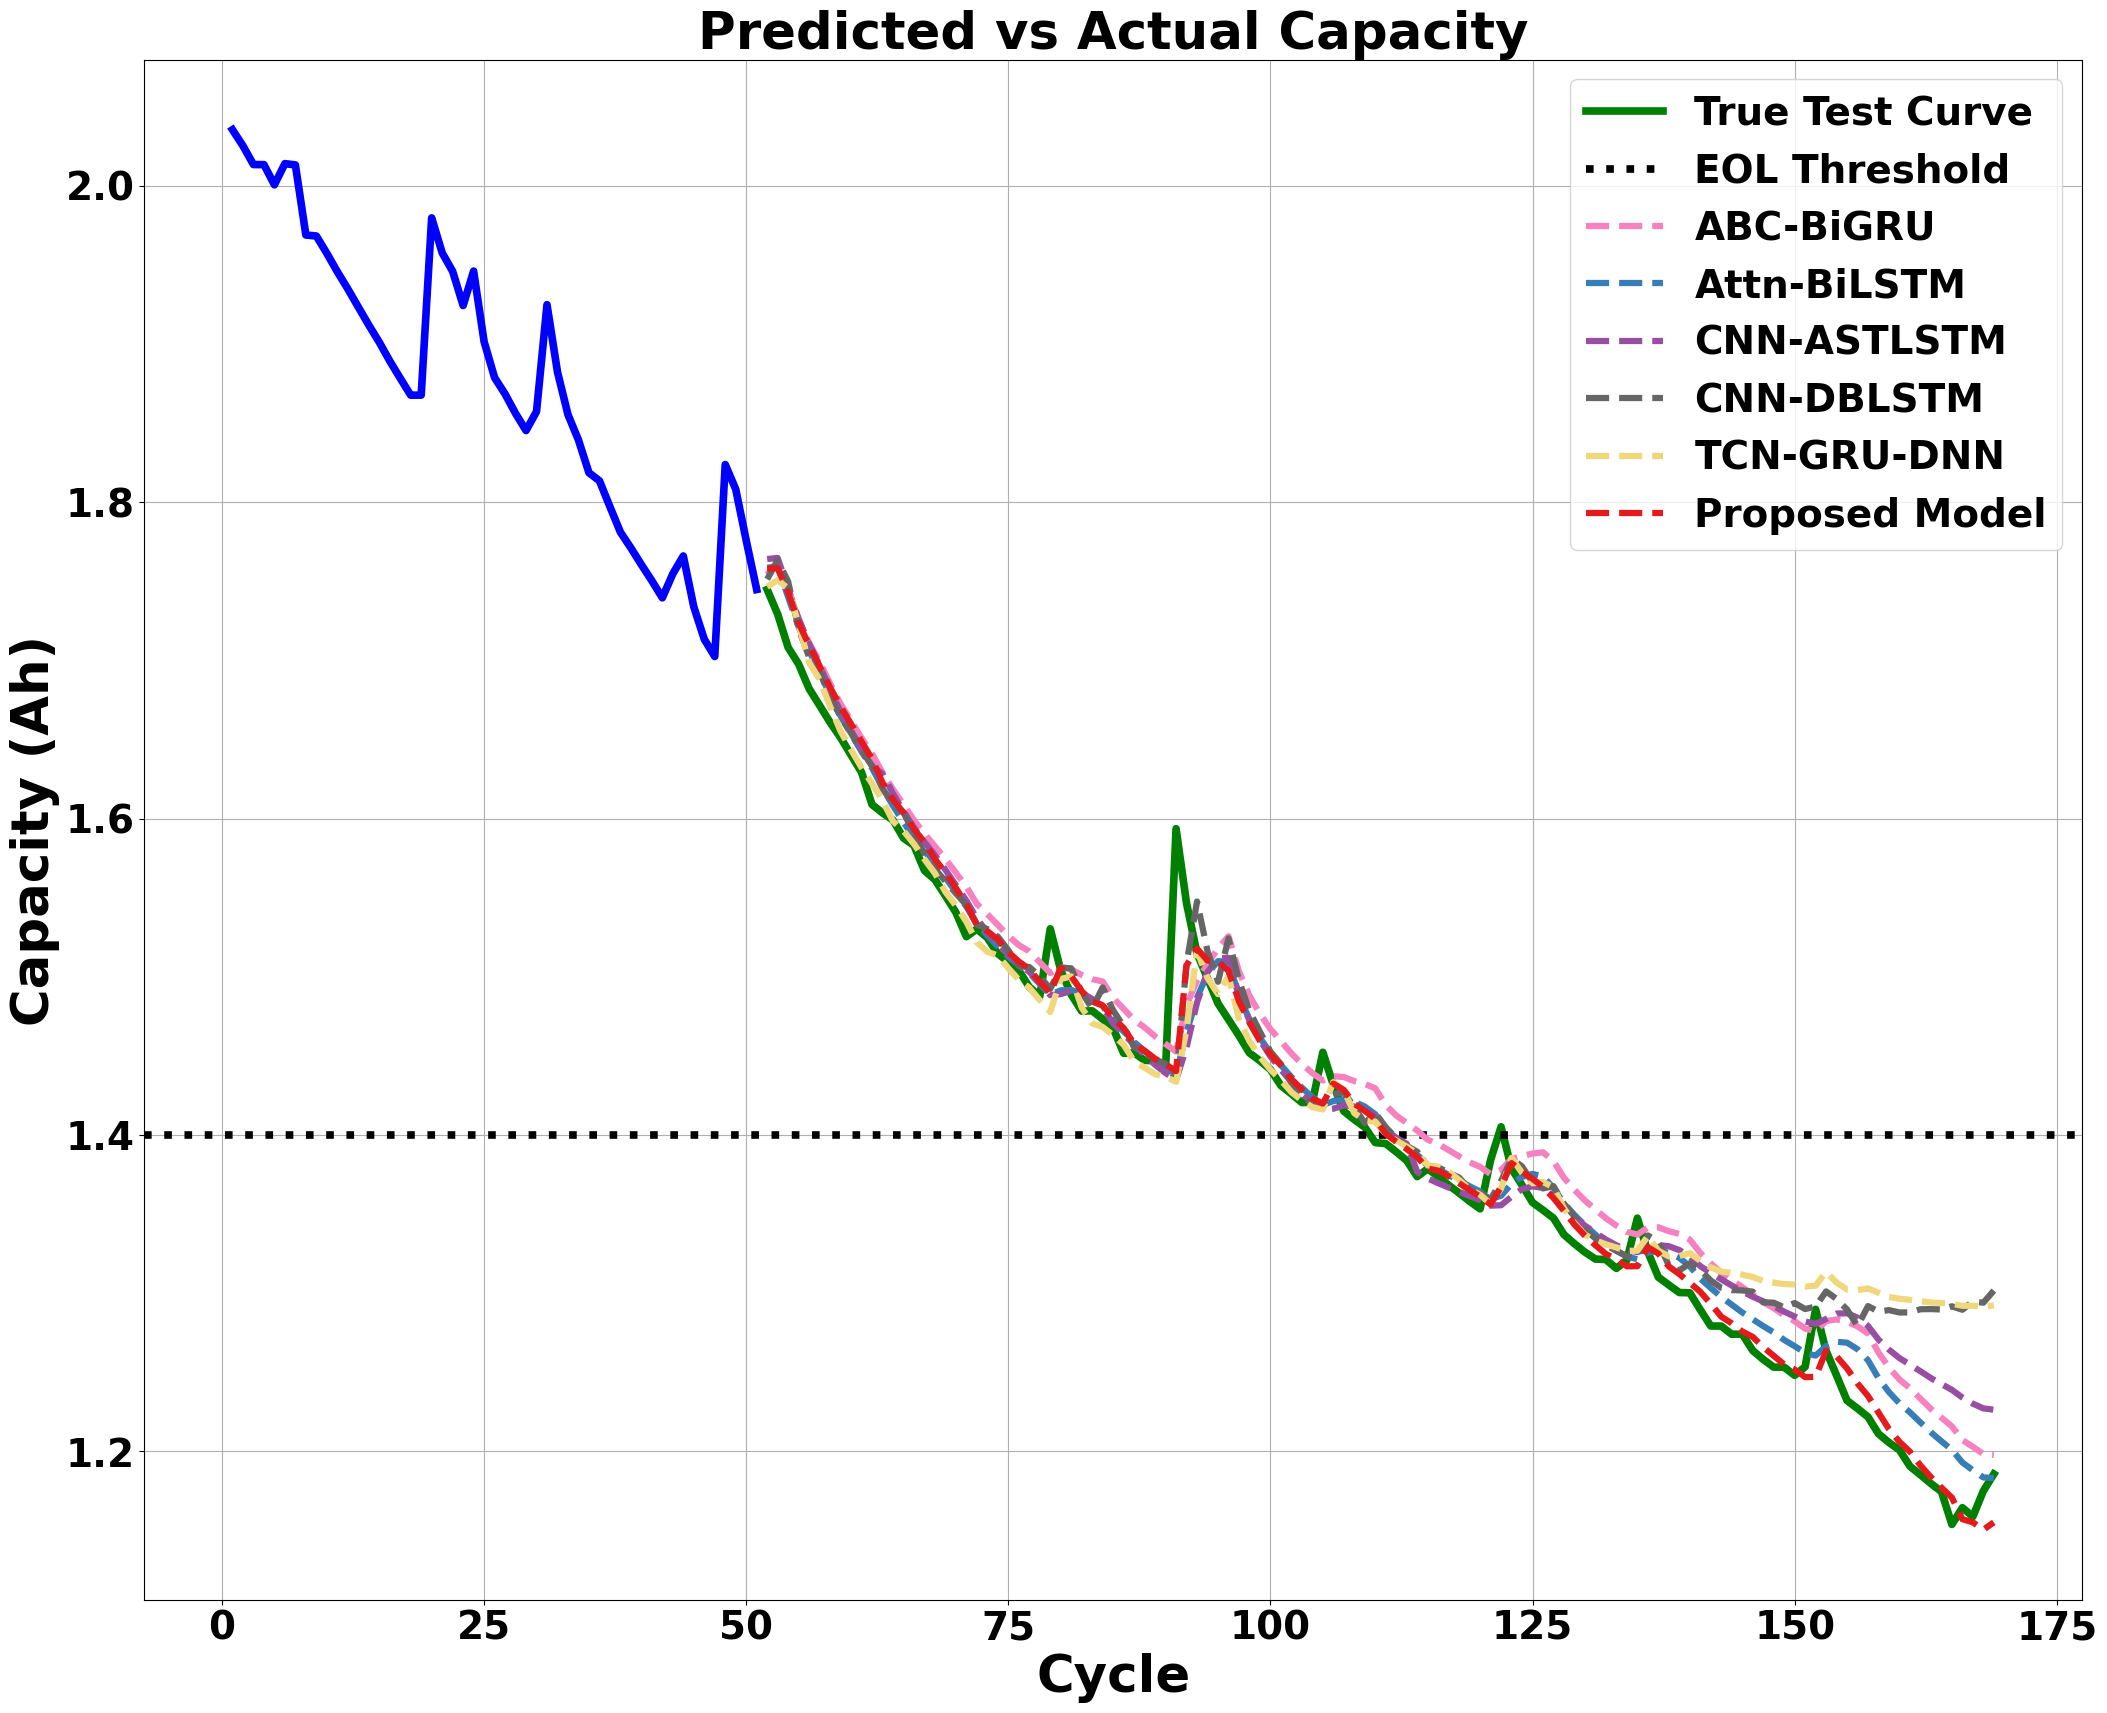

In [46]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[1], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[1]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.013682752755764277
MAE: 0.008476264793933085
------------------------------
Model: Attn-BiLSTM
RMSE: 0.013271069608655334
MAE: 0.006542450321293293
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.014768342317529628
MAE: 0.008638748592043739
------------------------------
Model: CNN-DBLSTM
RMSE: 0.013572075369109746
MAE: 0.007523974261482294
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.018334657173201808
MAE: 0.012700002675087177
------------------------------
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step
Model: Proposed Model
RMSE: 0.01268079681099182
MAE: 0.006412972524139131
------------------------------


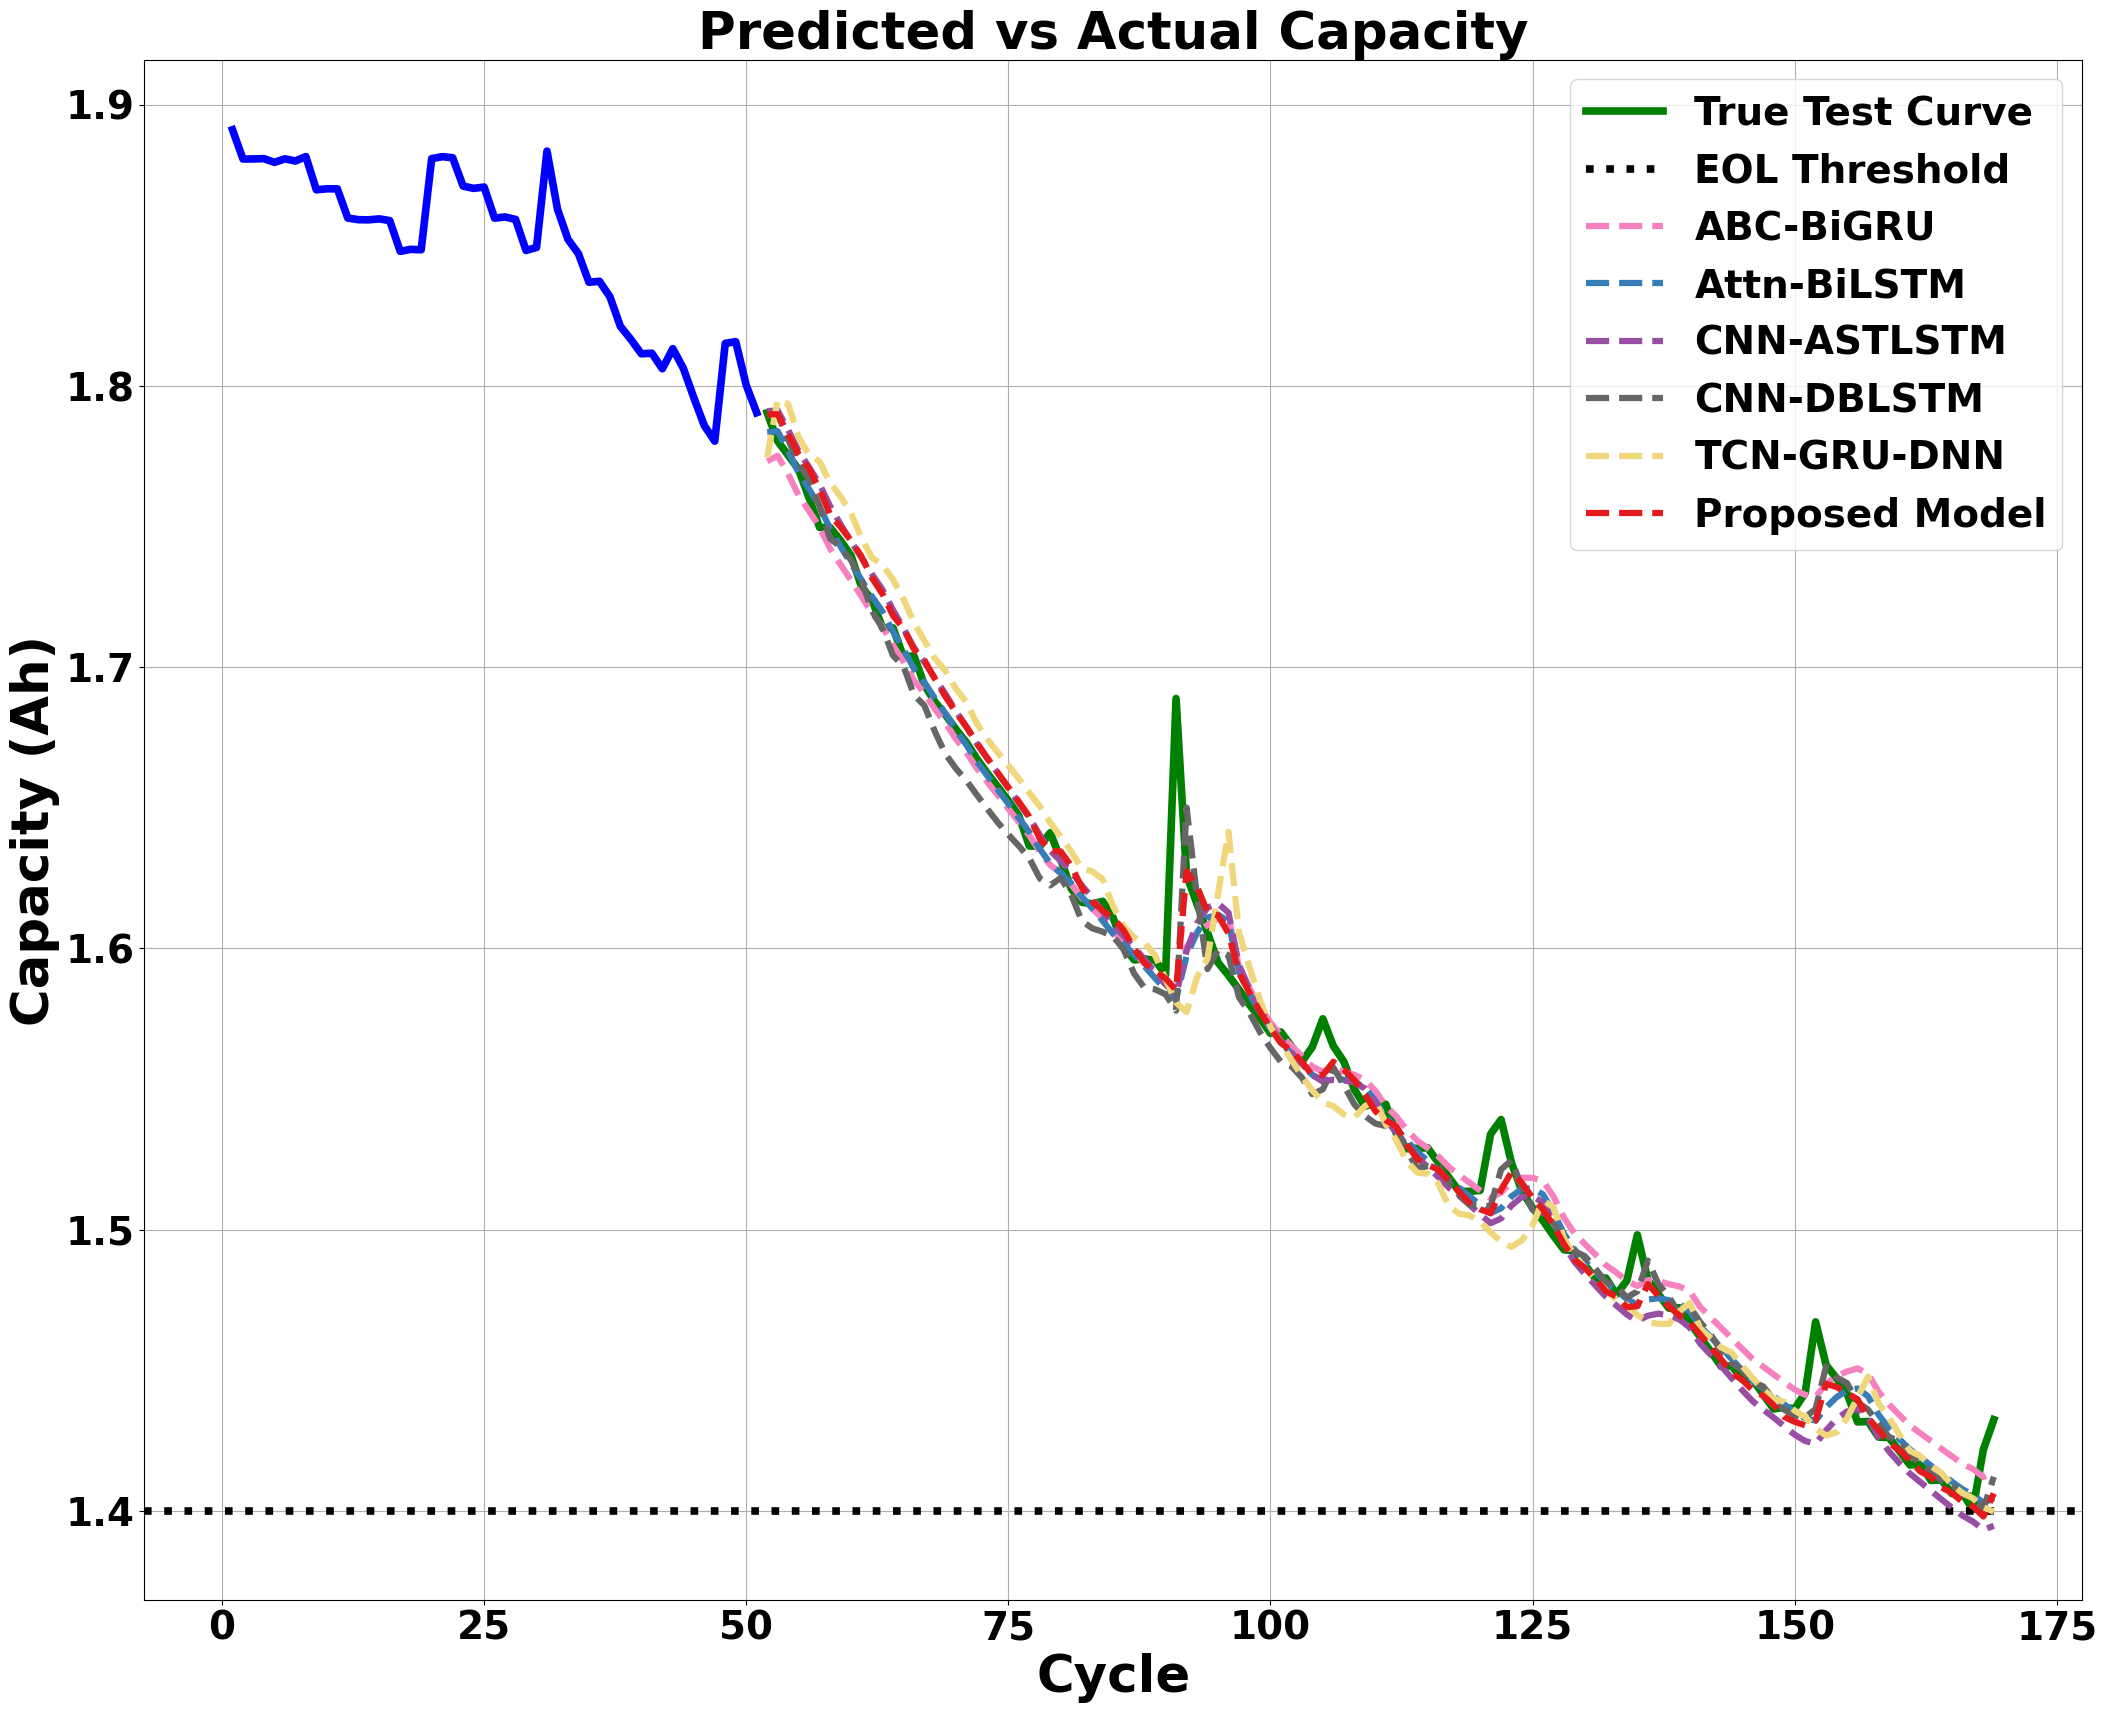

In [47]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[2], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[2]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.02879738552250795
MAE: 0.017772780503602037
------------------------------
Model: Attn-BiLSTM
RMSE: 0.0290088230244739
MAE: 0.020238184819116455
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.030545395747678276
MAE: 0.019702273524065585
------------------------------
Model: CNN-DBLSTM
RMSE: 0.026842554406800435
MAE: 0.015176144787103996
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.03846141776184114
MAE: 0.028741987633040405
------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step
Model: Proposed Model
RMSE: 0.025244088767249793
MAE: 0.016008715720823394
------------------------------


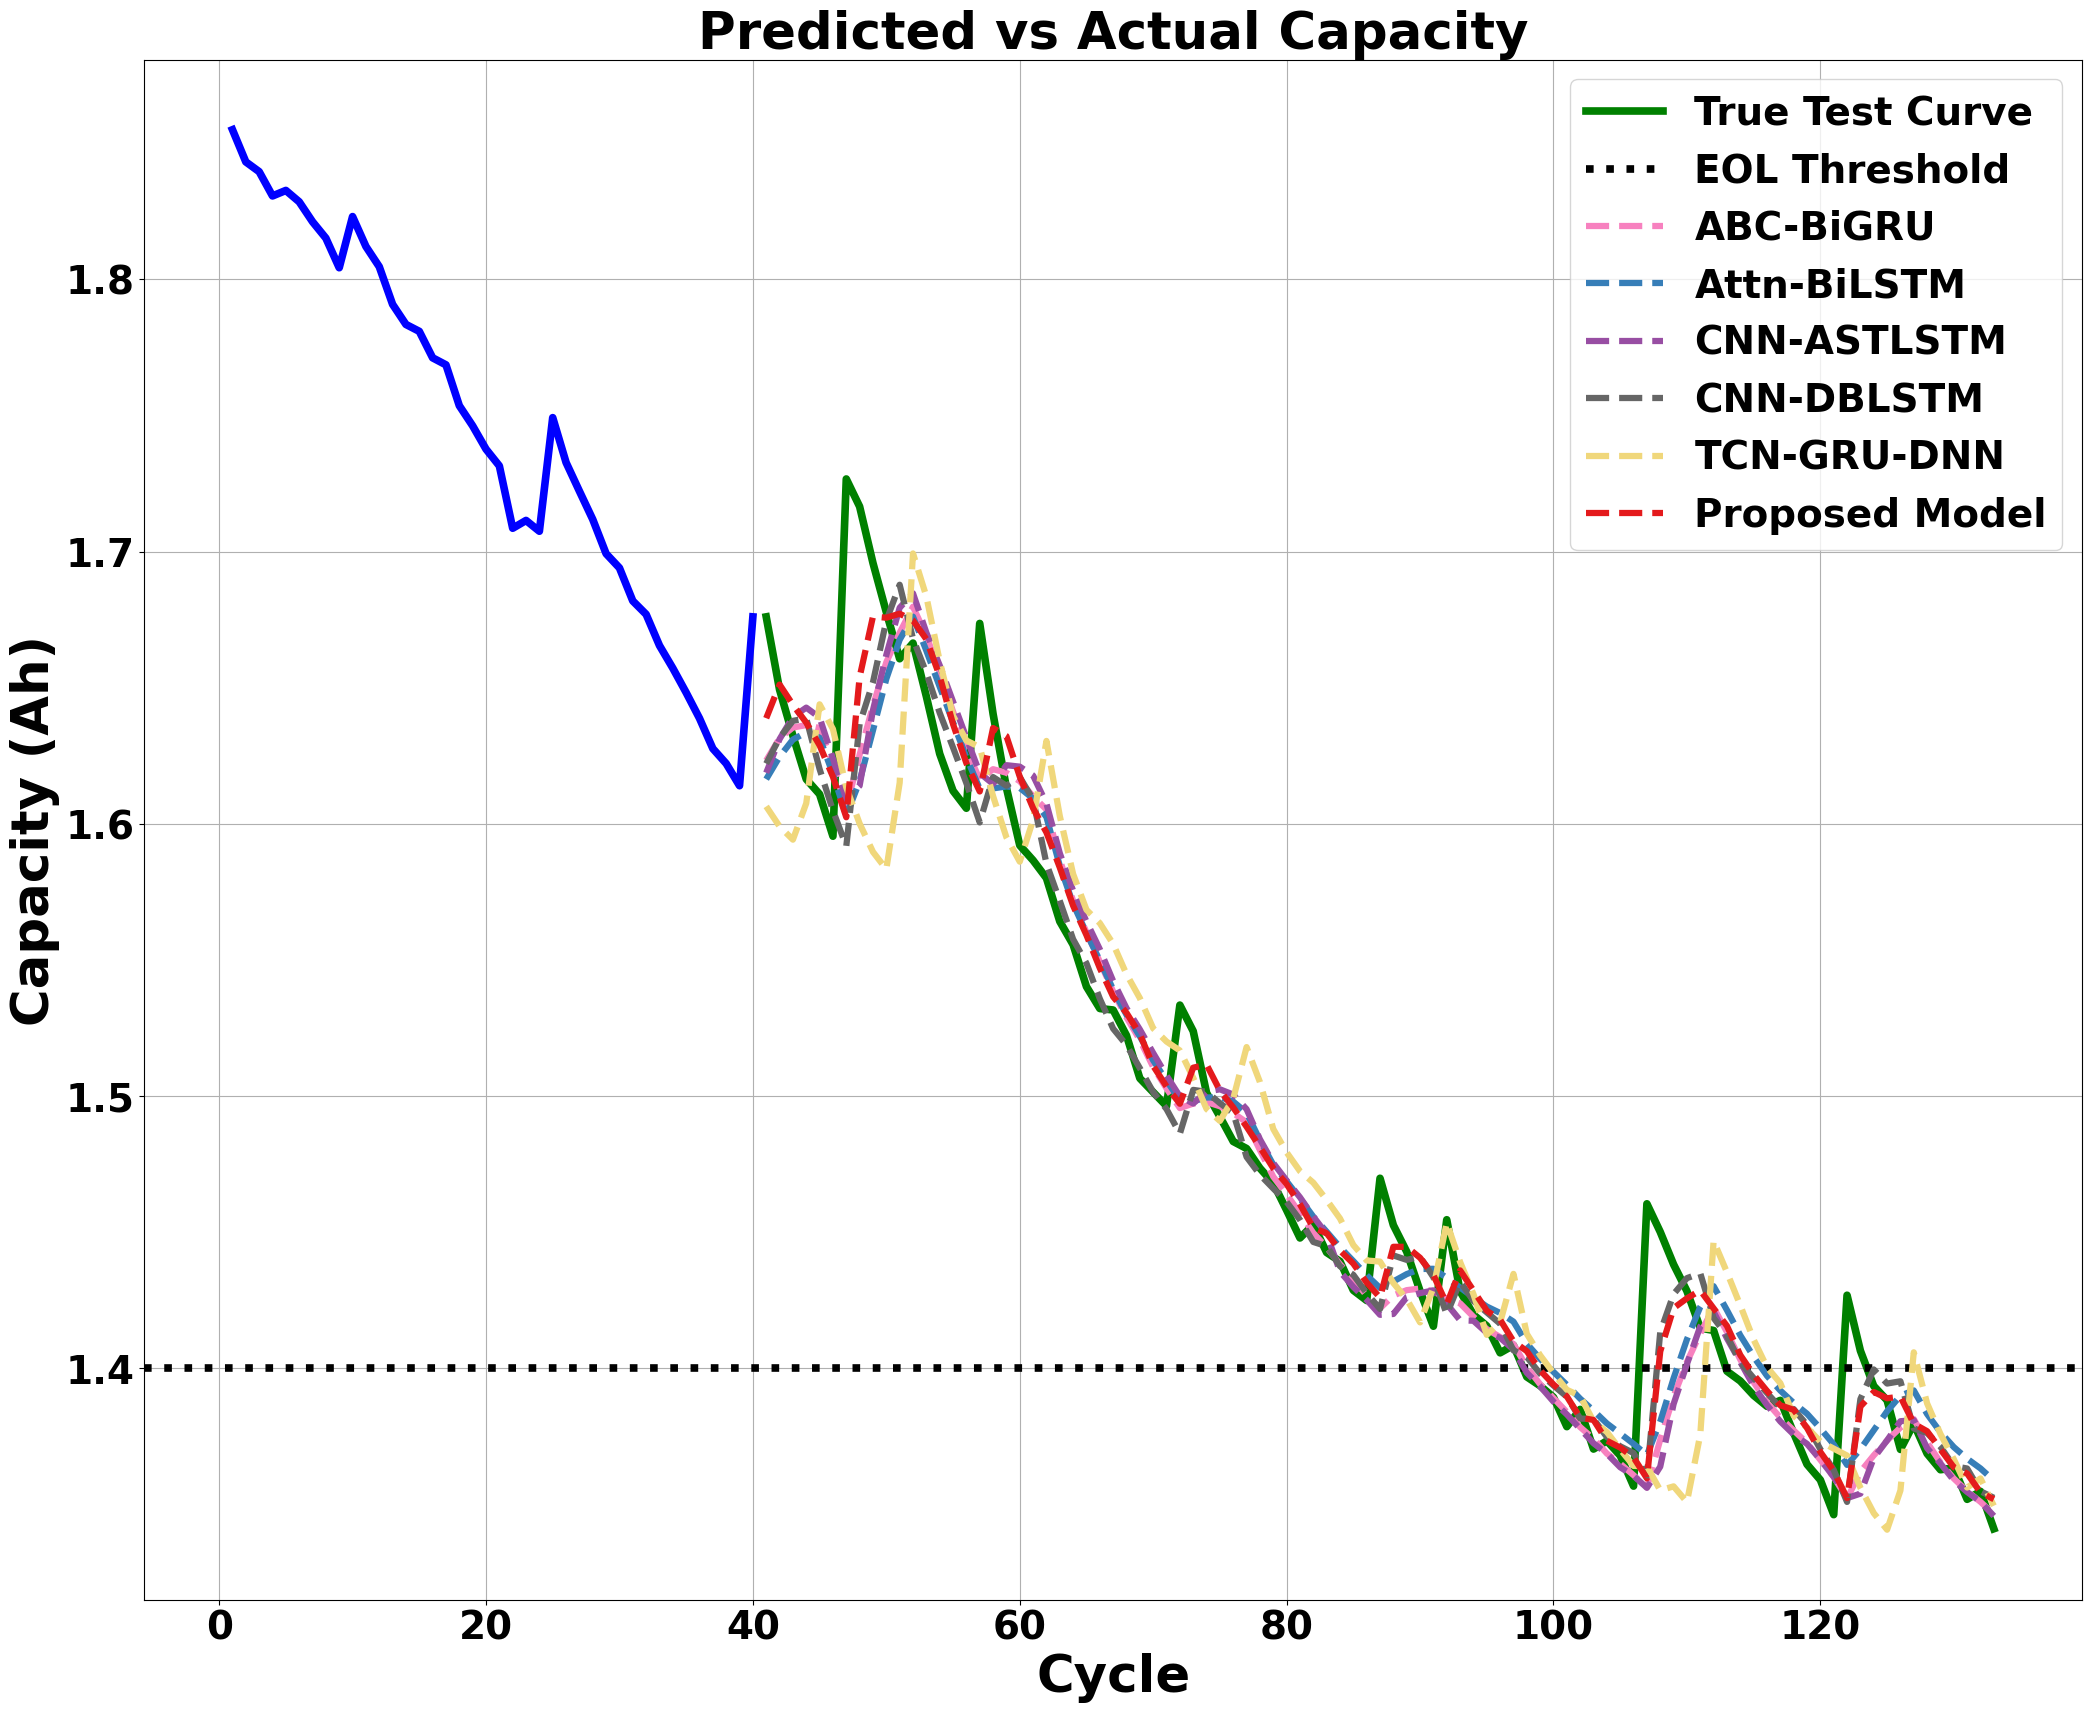

In [48]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[3], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[3]}_30',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=30,
    figsize=(25, 20),
    colors=COLORS
    )

### 50% of test curve for training

In [15]:
models = {
    'ABC-BiGRU': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'abc_bigru{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'abc_bigru_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiGRUModel(input_size=5, hidden_size=int(round(117)), dropout=3.26840185e-01),
        'unsqueeze': 1
    },
    
    'Attn-BiLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'attn_bilstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'attn_bilstm_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": BiLSTM_Attention(128),
        'unsqueeze': -1
    },

    'CNN-ASTLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_astlstm_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_astlstm_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_ASTLSTM(46, [24, 28]),
        'unsqueeze': 1
    },

    'CNN-DBLSTM': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'cnn_dblstm{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'cnn_dblstm_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": CNN_DBLSTM_Model([24, 48, 72], 128, 4),
        'unsqueeze': 1
    },

    'TCN-GRU-DNN': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tcn_gru_dnn_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.pth'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tcn_gru_dnn_{name}_50.pth'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } | {
        "model": TCN_GRU_DNN_Model(window_size=5),
        'unsqueeze': 1
    },
            
    'Proposed Model': {
        name: ModelOutputConstants.CALCE_OUTPUT_PATH.value / f'tf_model_1_{CALCEDatasetConstants.BATTERY_NUMBERS.value[i]}_50.keras'
        for i, name in enumerate(CALCEDatasetConstants.BATTERY_NAMES.value)
    } | {
        name: ModelOutputConstants.NASA_OUTPUT_PATH.value / f'tf_model_1_{name}_50.keras'
        for name in NASADatasetConstants.BATTERY_NAMES.value
    } 
}

Model: ABC-BiGRU
RMSE: 0.015541178481835964
MAE: 0.01091446865261783
------------------------------
Model: Attn-BiLSTM
RMSE: 0.016795800592164768
MAE: 0.01281313688441833
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.01594790959456784
MAE: 0.009828476362245143
------------------------------
Model: CNN-DBLSTM
RMSE: 0.01564745618086633
MAE: 0.0110436749163299
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.022285738897902564
MAE: 0.015538420144711787
------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step
Model: Proposed Model
RMSE: 0.014259783842717639
MAE: 0.00776464853060693
------------------------------


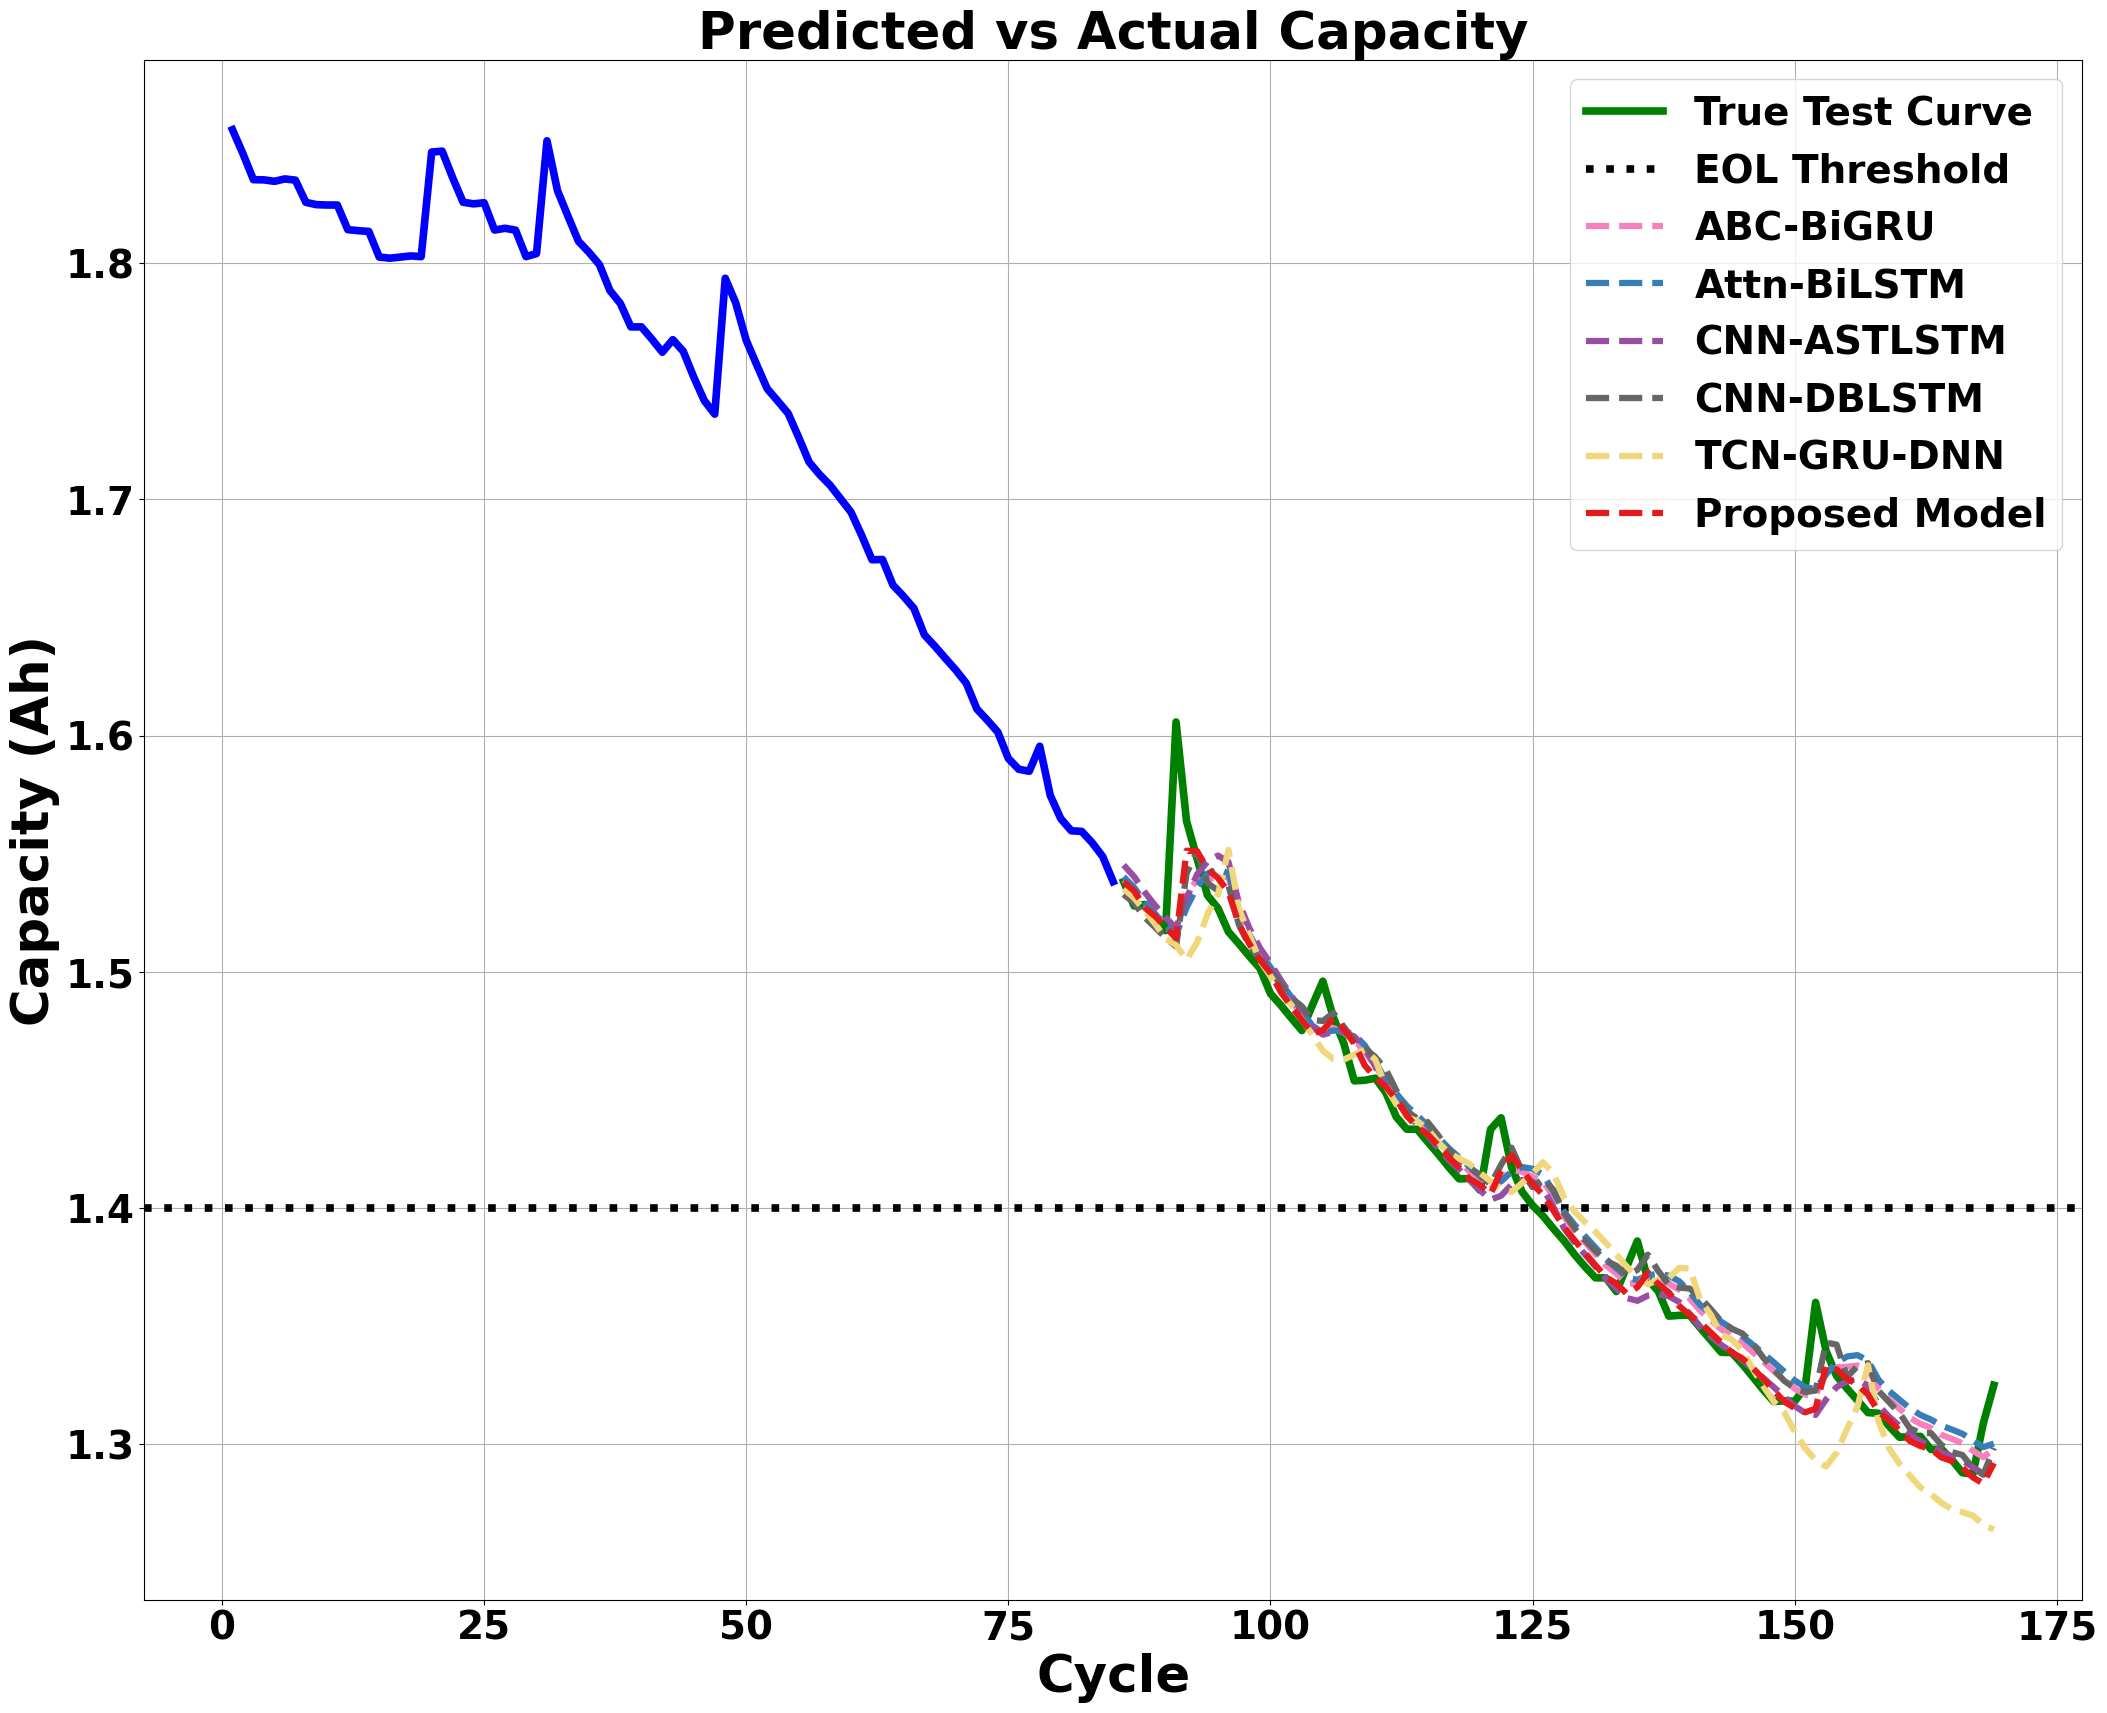

In [49]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[0], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[0]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.03592554242299657
MAE: 0.0314032748572885
------------------------------
Model: Attn-BiLSTM
RMSE: 0.02805067466521243
MAE: 0.019919146447276194
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.03812446230849999
MAE: 0.027602740559851197
------------------------------
Model: CNN-DBLSTM
RMSE: 0.050772077348046486
MAE: 0.034076753224317885
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.05371618724525163
MAE: 0.03575543967583766
------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step
Model: Proposed Model
RMSE: 0.022138653759715465
MAE: 0.012935042164597722
------------------------------


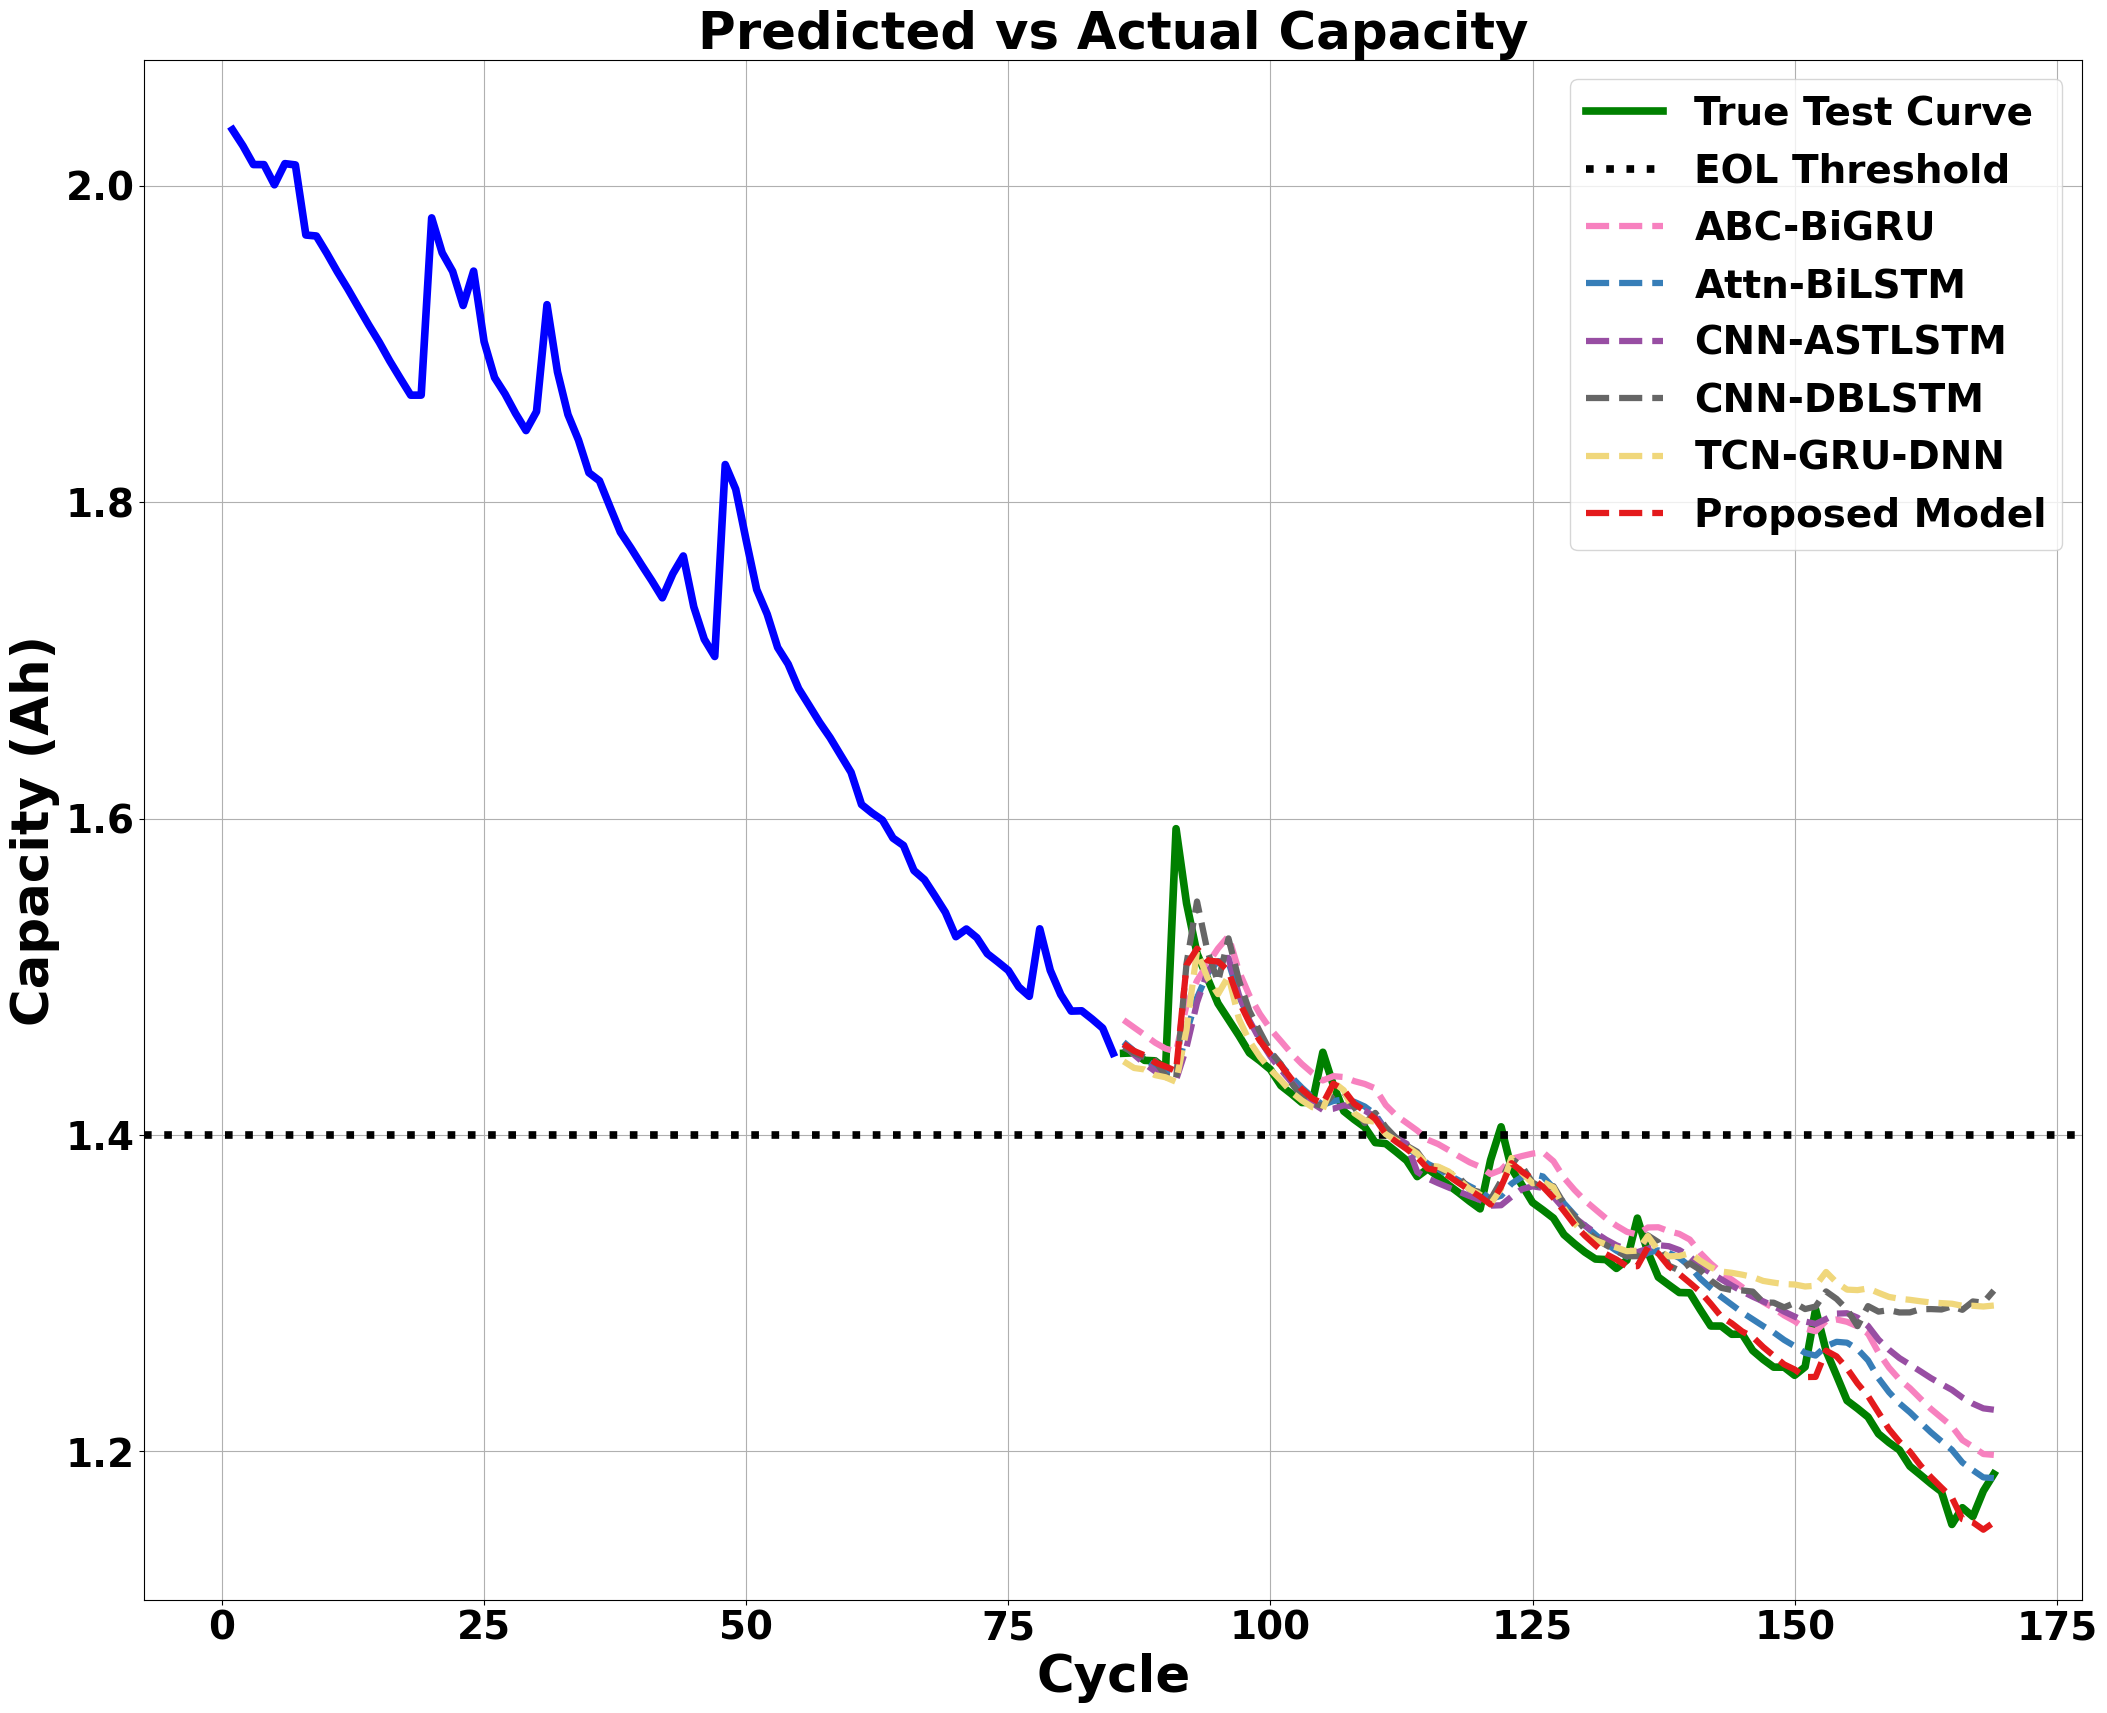

In [50]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[1], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[1]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.0158068275448274
MAE: 0.010067758278122188
------------------------------
Model: Attn-BiLSTM
RMSE: 0.015585192720090409
MAE: 0.00816782369758344
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.01686432716258572
MAE: 0.009462729982731677
------------------------------
Model: CNN-DBLSTM
RMSE: 0.01505283562721659
MAE: 0.007525969395399835
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.019594162081948464
MAE: 0.012124736980630102
------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step
Model: Proposed Model
RMSE: 0.014356153868554307
MAE: 0.006469713883702554
------------------------------


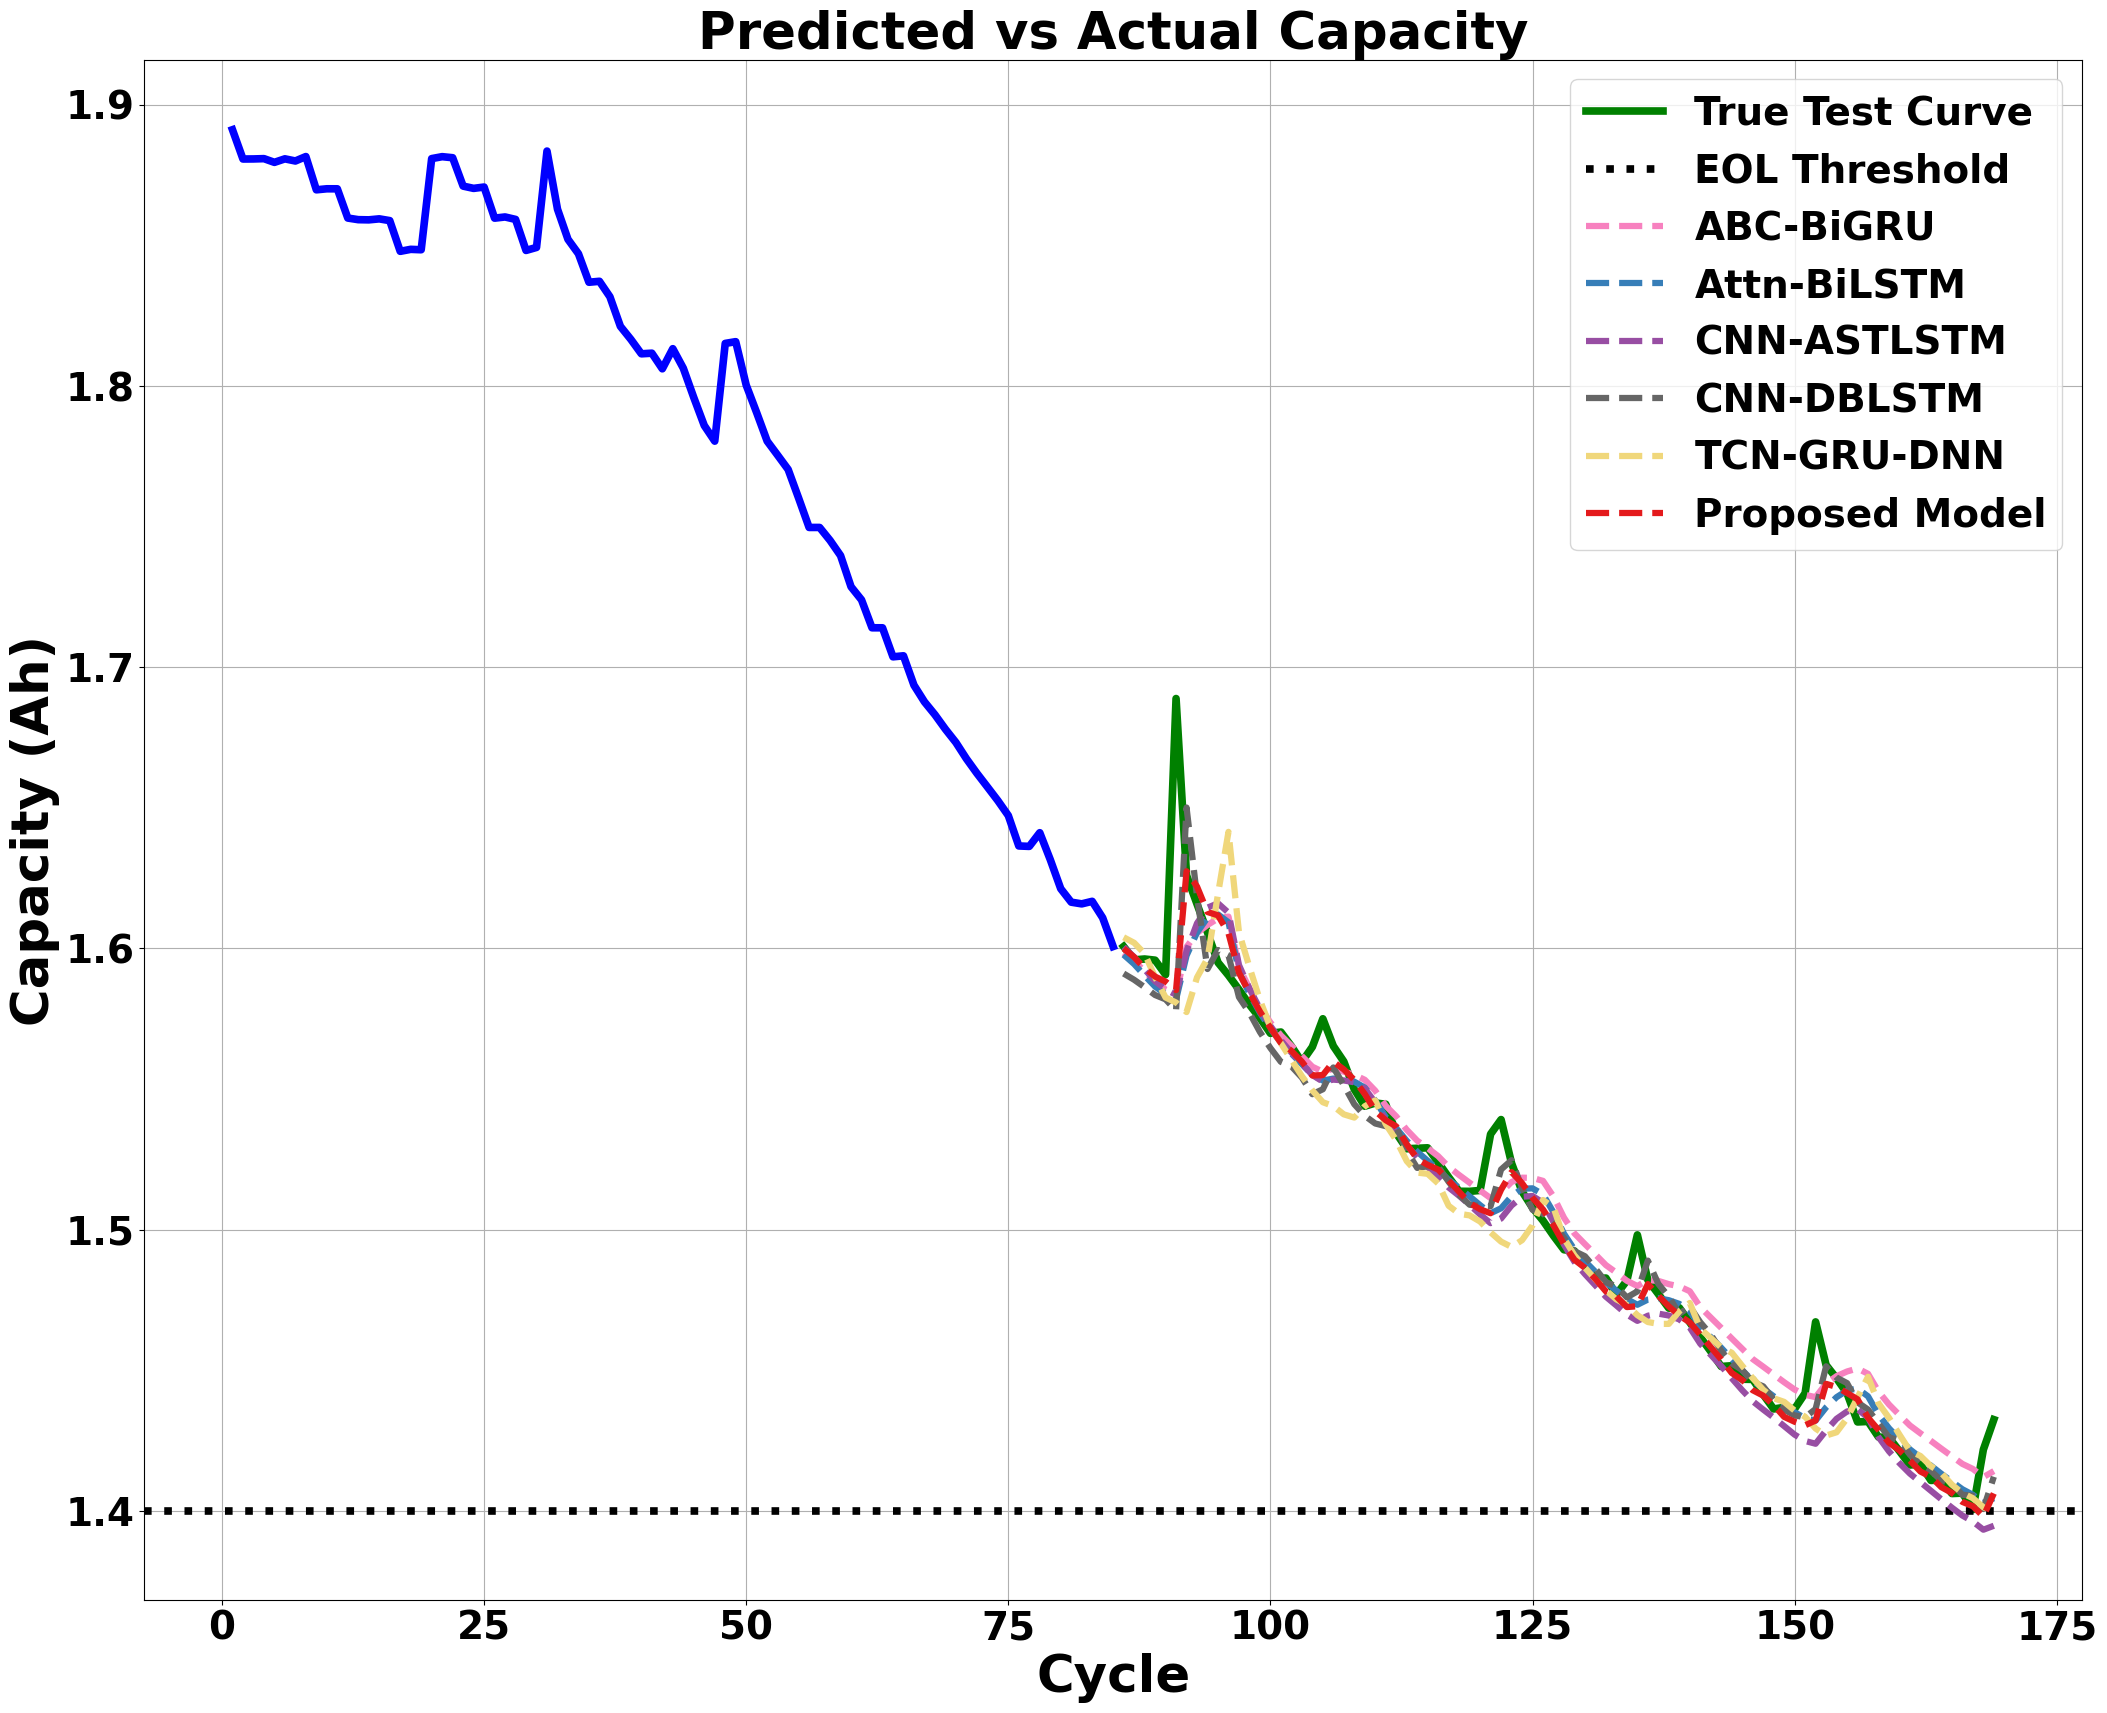

In [51]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[2], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[2]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)

Model: ABC-BiGRU
RMSE: 0.023417664613678855
MAE: 0.012820776962859076
------------------------------
Model: Attn-BiLSTM
RMSE: 0.022518030152717604
MAE: 0.01622417836432818
------------------------------
Model: CNN-ASTLSTM
RMSE: 0.024750579966792592
MAE: 0.0140749195578214
------------------------------
Model: CNN-DBLSTM
RMSE: 0.020594335765044988
MAE: 0.011891525537159418
------------------------------
Model: TCN-GRU-DNN
RMSE: 0.0303439545133434
MAE: 0.022211687447357534
------------------------------
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step
Model: Proposed Model
RMSE: 0.020383315925793778
MAE: 0.012419674974605227
------------------------------


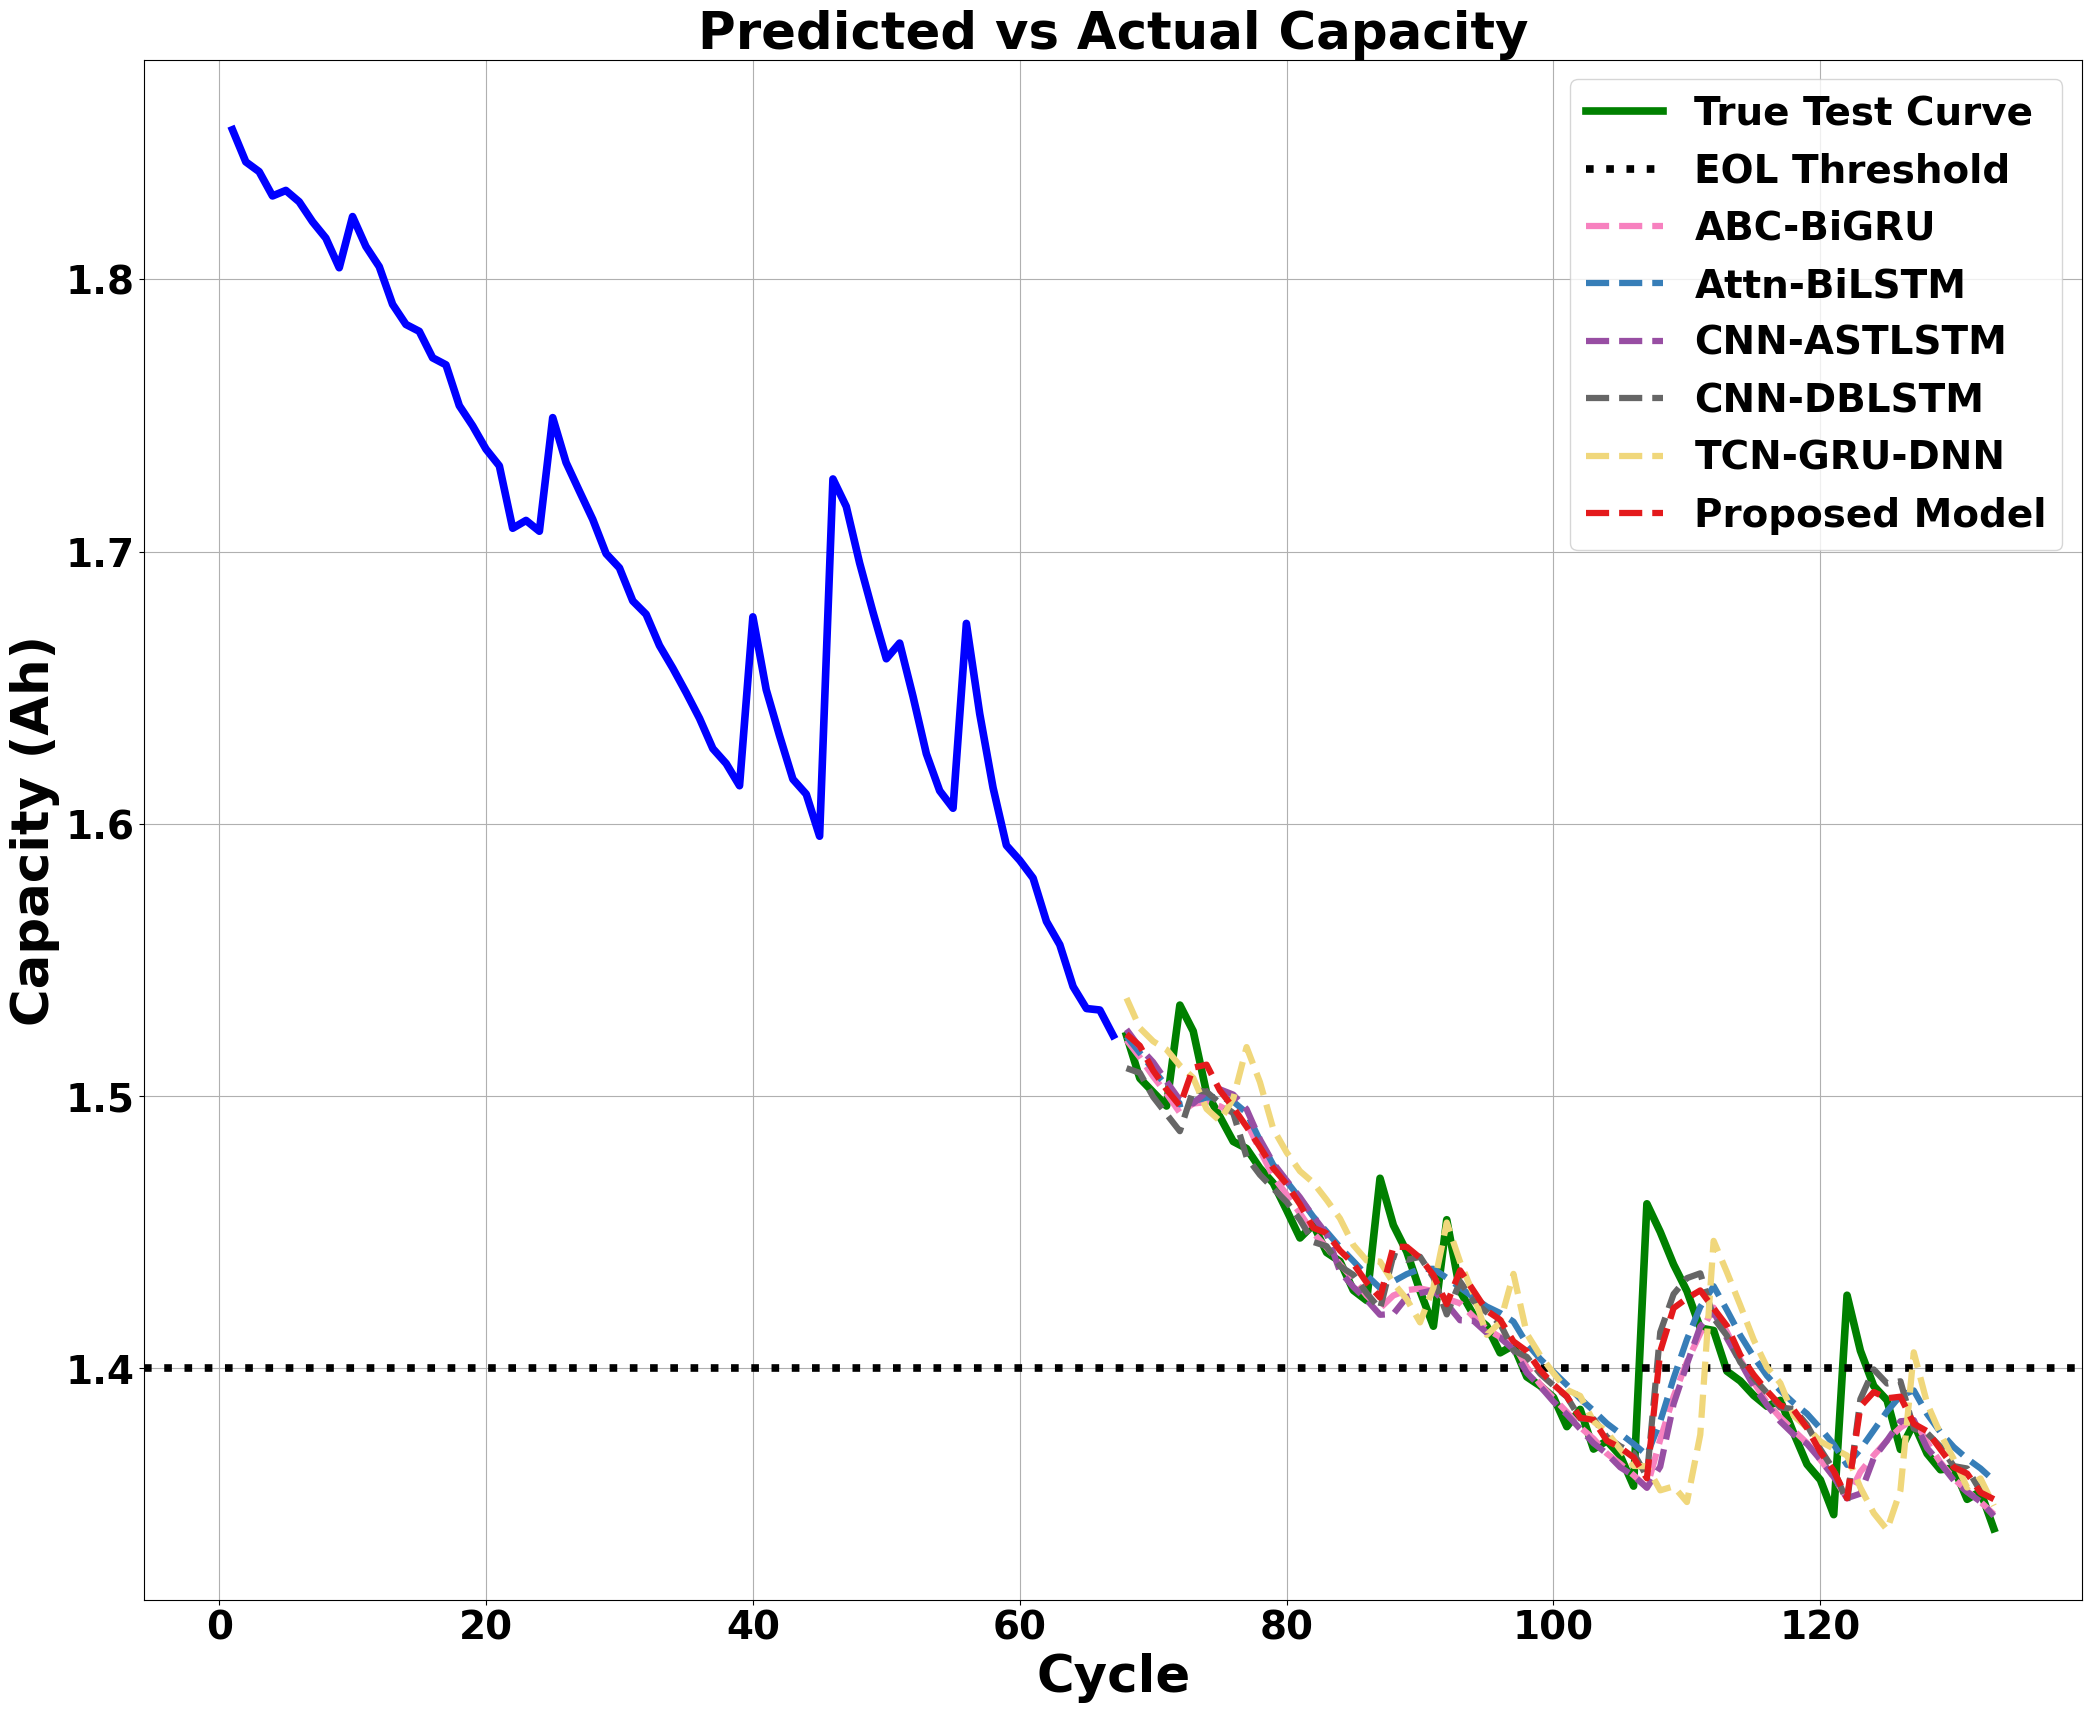

In [52]:
plot_predictions(
    models, 
    nasa_dfs, 
    NASADatasetConstants.BATTERY_NAMES.value[3], 
    generate_sliding_window_data, 
    MIN, 
    DIFF, 
    device=device, 
    column_name="capacity", 
    unsqueeze_dim=1, 
    window_size=5,
    dataset='NASA',
    line_width_1=5.5,
    line_width_2=4.5,
    save_path=ModelOutputConstants.PLOTS_OUTPUT_PATH.value / f'{NASADatasetConstants.BATTERY_NAMES.value[3]}_50',
    font_size_1=37,
    font_size_2=28,
    cutoff_percentage=50,
    figsize=(25, 20),
    colors=COLORS
)